# Datathon Passos Mágicos — Análise Exploratória dos Dados

Este notebook apresenta a análise exploratória dos dados educacionais da Associação Passos Mágicos referentes aos anos de 2022, 2023 e 2024.

A análise será utilizada para:

- compreender o perfil dos alunos;
- avaliar a evolução dos indicadores educacionais;
- responder às perguntas de negócio propostas no Datathon;
- gerar gráficos e insights para o storytelling gerencial;
- preparar a base para a etapa de Machine Learning.

A base utilizada neste notebook foi produzida pelo notebook `01_limpeza_dados.ipynb`.

In [212]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.2f}".format)

print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


In [213]:
from google.colab import files
from io import BytesIO

arquivos_enviados = files.upload()

if len(arquivos_enviados) != 1:
    raise ValueError(
        "Envie somente um arquivo CSV."
    )

nome_arquivo = next(
    iter(arquivos_enviados)
)

df_pede = pd.read_csv(
    BytesIO(
        arquivos_enviados[nome_arquivo]
    )
)

print(f"Arquivo carregado: {nome_arquivo}")
print(f"Quantidade de linhas: {df_pede.shape[0]}")
print(f"Quantidade de colunas: {df_pede.shape[1]}")

Saving dados_pede.csv to dados_pede (6).csv
Arquivo carregado: dados_pede (6).csv
Quantidade de linhas: 3030
Quantidade de colunas: 36


In [214]:
print("Colunas disponíveis na base:\n")

for numero, coluna in enumerate(
    df_pede.columns,
    start=1
):
    print(f"{numero:02d}. {coluna}")

Colunas disponíveis na base:

01. ra
02. ano
03. fase
04. turma
05. nome
06. idade
07. genero
08. ano_ingresso
09. instituicao
10. pedra
11. inde
12. iaa
13. ieg
14. ips
15. ipp
16. ida
17. nota_matematica
18. nota_portugues
19. nota_ingles
20. indicado_bolsa
21. atingiu_pv
22. ipv
23. ian
24. fase_ideal
25. defasagem
26. fase_num
27. fase_ideal_num
28. pedra_padrao
29. instituicao_padrao
30. iaa_original
31. ipv_original
32. defasagem_original
33. defasagem_calculada
34. genero_inconsistente
35. ano_ingresso_inconsistente
36. idade_inconsistente


In [215]:
resumo_inicial = pd.DataFrame({
    "verificacao": [
        "Quantidade de linhas",
        "Quantidade de colunas",
        "Alunos únicos",
        "Anos disponíveis",
        "Duplicidades por RA e ano",
        "RA ausentes"
    ],
    "resultado": [
        df_pede.shape[0],
        df_pede.shape[1],
        df_pede["ra"].nunique(),
        ", ".join(
            map(
                str,
                sorted(df_pede["ano"].unique())
            )
        ),
        df_pede.duplicated(
            subset=["ra", "ano"]
        ).sum(),
        df_pede["ra"].isna().sum()
    ]
})

resumo_inicial

,verificacao,resultado
0,Quantidade de linhas,3030
1,Quantidade de colunas,36
2,Alunos únicos,1661
3,Anos disponíveis,"2022, 2023, 2024"
4,Duplicidades por RA e ano,0
5,RA ausentes,0


## 1. Diagnóstico geral da base

Nesta seção será apresentada uma visão geral dos registros disponíveis, incluindo a quantidade de alunos por ano, o perfil básico da população e a cobertura dos indicadores educacionais.

Esse diagnóstico é importante para identificar diferenças de preenchimento entre os anos antes de realizar comparações e responder às perguntas de negócio.

In [216]:
resumo_por_ano = (
    df_pede
    .groupby("ano")
    .agg(
        registros=("ra", "size"),
        alunos_unicos=("ra", "nunique"),
        idade_media=("idade", "mean"),
        fase_media=("fase_num", "mean"),
        defasagem_media=("defasagem", "mean"),
        inde_medio=("inde", "mean")
    )
    .round(2)
    .reset_index()
)

resumo_por_ano

,ano,registros,alunos_unicos,idade_media,fase_media,defasagem_media,inde_medio
0,2022,860,860,12.14,2.10,-0.94,7.04
1,2023,1014,1014,12.33,2.50,-0.65,7.34
2,2024,1156,1156,12.99,2.95,-0.41,7.40


In [217]:
distribuicao_ano = (
    df_pede["ano"]
    .value_counts()
    .sort_index()
    .rename_axis("ano")
    .reset_index(name="quantidade")
)

distribuicao_ano["percentual"] = (
    distribuicao_ano["quantidade"]
    / distribuicao_ano["quantidade"].sum()
    * 100
).round(2)

distribuicao_ano

,ano,quantidade,percentual
0,2022,860,28.38
1,2023,1014,33.47
2,2024,1156,38.15


In [218]:
indicadores = [
    "inde",
    "ian",
    "ida",
    "ieg",
    "iaa",
    "ips",
    "ipp",
    "ipv"
]

ausentes_por_ano = []

for ano in sorted(df_pede["ano"].unique()):
    dados_ano = df_pede[df_pede["ano"] == ano]

    for indicador in indicadores:
        quantidade_ausente = dados_ano[indicador].isna().sum()

        percentual_ausente = (
            quantidade_ausente
            / len(dados_ano)
            * 100
        )

        ausentes_por_ano.append({
            "ano": ano,
            "indicador": indicador.upper(),
            "quantidade_ausente": quantidade_ausente,
            "percentual_ausente": round(
                percentual_ausente,
                2
            )
        })

df_ausentes = pd.DataFrame(ausentes_por_ano)

df_ausentes

,ano,indicador,quantidade_ausente,percentual_ausente
0,2022,INDE,0,0.00
1,2022,IAN,0,0.00
2,2022,IDA,0,0.00
3,2022,IEG,0,0.00
4,2022,IAA,0,0.00
5,2022,IPS,0,0.00
6,2022,IPP,860,100.00
7,2022,IPV,0,0.00
8,2023,INDE,83,8.19
9,2023,IAN,0,0.00


In [219]:
tabela_ausentes = (
    df_ausentes
    .pivot(
        index="indicador",
        columns="ano",
        values="percentual_ausente"
    )
    .sort_index()
)

tabela_ausentes

ano,2022,2023,2024
indicador,,,
IAA,0.00,6.21,8.82
IAN,0.00,0.00,0.00
IDA,0.00,7.59,8.74
IEG,0.00,7.50,0.00
INDE,0.00,8.19,8.82
IPP,100.00,7.50,8.82
IPS,0.00,6.80,8.82
IPV,0.00,7.50,8.82


In [220]:
resumo_indicadores = (
    df_pede[indicadores]
    .describe()
    .T
    .rename(columns={
        "count": "quantidade",
        "mean": "media",
        "std": "desvio_padrao",
        "min": "minimo",
        "25%": "quartil_25",
        "50%": "mediana",
        "75%": "quartil_75",
        "max": "maximo"
    })
    .round(2)
)

resumo_indicadores

,quantidade,media,desvio_padrao,minimo,quartil_25,mediana,quartil_75,maximo
inde,2845.00,7.27,0.99,3.03,6.68,7.39,7.99,9.53
ian,3030.00,7.18,2.54,2.50,5.00,5.00,10.00,10.00
ida,2852.00,6.38,1.96,0.00,5.10,6.67,7.83,10.00
ieg,2954.00,7.95,2.15,0.00,7.30,8.60,9.40,10.00
iaa,2865.00,7.92,2.63,0.00,7.90,8.75,9.50,10.00
ips,2859.00,6.29,1.79,2.50,5.02,7.50,7.51,10.00
ipp,1992.00,7.56,0.94,2.50,7.08,7.50,8.12,10.00
ipv,2852.00,7.55,1.08,2.50,6.98,7.58,8.26,10.00


In [221]:
medias_por_ano = (
    df_pede
    .groupby("ano")[indicadores]
    .mean()
    .round(2)
)

medias_por_ano

,inde,ian,ida,ieg,iaa,ips,ipp,ipv
ano,,,,,,,,
2022,7.04,6.42,6.09,7.89,8.27,6.90,NaN,7.25
2023,7.34,7.24,6.66,8.70,6.90,5.12,7.56,8.03
2024,7.40,7.68,6.35,7.37,8.54,6.83,7.55,7.35


### 1.1 Comparação das médias dos indicadores

A tabela anterior apresenta a média de cada indicador nos anos de 2022, 2023 e 2024.

O gráfico a seguir facilita a identificação de indicadores que apresentaram crescimento, estabilidade ou redução. Esta comparação ainda é transversal, pois considera todos os alunos disponíveis em cada ano, e não necessariamente os mesmos alunos ao longo do tempo.

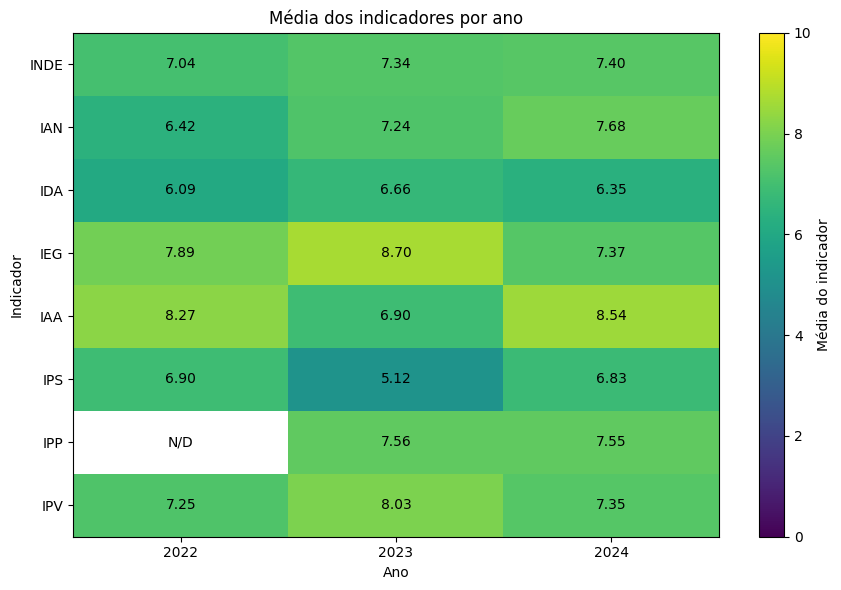

In [222]:
matriz_medias = medias_por_ano.T

plt.figure(figsize=(9, 6))

imagem = plt.imshow(
    matriz_medias,
    aspect="auto",
    vmin=0,
    vmax=10
)

plt.colorbar(
    imagem,
    label="Média do indicador"
)

plt.xticks(
    range(len(matriz_medias.columns)),
    matriz_medias.columns
)

plt.yticks(
    range(len(matriz_medias.index)),
    [indicador.upper() for indicador in matriz_medias.index]
)

plt.xlabel("Ano")
plt.ylabel("Indicador")
plt.title("Média dos indicadores por ano")

for linha in range(matriz_medias.shape[0]):
    for coluna in range(matriz_medias.shape[1]):

        valor = matriz_medias.iloc[linha, coluna]

        if pd.notna(valor):
            texto = f"{valor:.2f}"
        else:
            texto = "N/D"

        plt.text(
            coluna,
            linha,
            texto,
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

### Interpretação preliminar

Os resultados apresentam comportamentos diferentes entre os indicadores:

- o INDE médio aumentou de 7,04 em 2022 para 7,40 em 2024;
- o IAN apresentou crescimento contínuo, passando de 6,42 para 7,68;
- o IDA melhorou em 2023, mas apresentou redução em 2024;
- o IEG alcançou sua maior média em 2023 e caiu em 2024;
- o IAA apresentou queda em 2023 e forte recuperação em 2024;
- o IPS também caiu em 2023 e voltou a crescer em 2024;
- o IPV apresentou crescimento em 2023, seguido de redução em 2024;
- o IPP não possui dados em 2022 e permaneceu praticamente estável entre 2023 e 2024.

Essas diferenças mostram que a evolução educacional é multidimensional. Uma melhora na adequação ao nível não significa necessariamente melhora simultânea no desempenho acadêmico, no engajamento ou nos aspectos psicossociais.

As conclusões ainda são preliminares, pois os grupos de alunos avaliados não são exatamente os mesmos em todos os anos.

## 2. Pergunta 1 — Adequação ao nível: IAN e defasagem

**Pergunta de negócio:** Qual é o perfil geral de defasagem dos alunos e como ele evolui ao longo dos anos? Quantos alunos estão moderadamente ou severamente defasados?

O IAN representa a adequação do aluno ao nível de aprendizagem em que se encontra. A variável `defasagem` representa a diferença entre a fase atual do aluno e sua fase ideal.

Antes de criar categorias de severidade, será analisada a distribuição dos valores de defasagem existentes na base.

In [223]:
df_pede["defasagem"] = pd.to_numeric(
    df_pede["defasagem"],
    errors="coerce"
)

distribuicao_geral_defasagem = (
    df_pede["defasagem"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("defasagem")
    .reset_index(name="quantidade")
)

distribuicao_geral_defasagem["percentual"] = (
    distribuicao_geral_defasagem["quantidade"]
    / distribuicao_geral_defasagem["quantidade"].sum()
    * 100
).round(2)

distribuicao_geral_defasagem

,defasagem,quantidade,percentual
0,-5,1,0.03
1,-4,5,0.17
2,-3,39,1.29
3,-2,383,12.64
4,-1,1259,41.55
5,0,1154,38.09
6,1,165,5.45
7,2,24,0.79


**Interpretação da variável de defasagem:**

- Valor negativo: Aluno abaixo da fase ideal
- Zero: Aluno na fase ideal
- Valor Positivo: Aluno acima da fase ideal

In [224]:
distribuicao_defasagem_ano = (
    df_pede
    .groupby(
        ["ano", "defasagem"],
        dropna=False
    )
    .size()
    .reset_index(name="quantidade")
)

distribuicao_defasagem_ano["percentual"] = (
    distribuicao_defasagem_ano
    .groupby("ano")["quantidade"]
    .transform(
        lambda valores:
            valores / valores.sum() * 100
    )
    .round(2)
)

distribuicao_defasagem_ano = (
    distribuicao_defasagem_ano
    .sort_values(
        ["ano", "defasagem"]
    )
)

distribuicao_defasagem_ano

,ano,defasagem,quantidade,percentual
0,2022,-5,1,0.12
1,2022,-4,4,0.47
2,2022,-3,23,2.67
3,2022,-2,163,18.95
4,2022,-1,410,47.67
5,2022,0,247,28.72
6,2022,1,9,1.05
7,2022,2,3,0.35
8,2023,-4,1,0.10
9,2023,-3,13,1.28


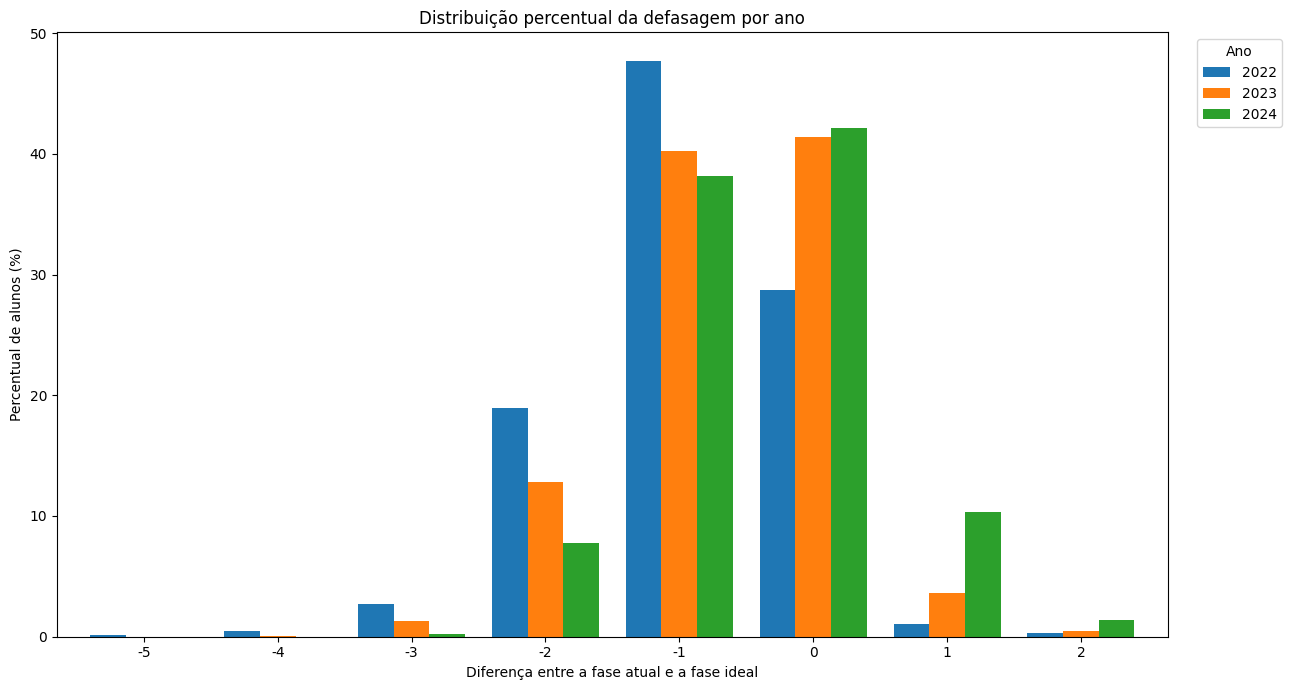

In [225]:
distribuicao_defasagem_ano["percentual"] = (
    distribuicao_defasagem_ano
    .groupby("ano")["quantidade"]
    .transform(
        lambda valores:
            valores / valores.sum() * 100
    )
)

grafico_defasagem_ano = (
    distribuicao_defasagem_ano
    .pivot(
        index="defasagem",
        columns="ano",
        values="percentual"
    )
    .fillna(0)
    .sort_index()
)

ax = grafico_defasagem_ano.plot(
    kind="bar",
    figsize=(13, 7),
    width=0.8
)

plt.title("Distribuição percentual da defasagem por ano")
plt.xlabel("Diferença entre a fase atual e a fase ideal")
plt.ylabel("Percentual de alunos (%)")
plt.xticks(rotation=0)

plt.legend(
    title="Ano",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Observação metodológica

A comparação foi realizada em percentuais, e não apenas em quantidades absolutas, porque o número de registros é diferente entre os anos.

Ainda não foram criadas categorias como defasagem moderada ou severa. Primeiro será observada a distribuição dos valores reais da base e, em seguida, será definida e documentada uma regra operacional de classificação.

### 2.1 Classificação do nível de defasagem

Para facilitar a interpretação dos resultados, os valores de defasagem foram agrupados em quatro categorias operacionais:

- **Acima do esperado:** aluno em fase superior à fase ideal;
- **Sem defasagem:** aluno na fase correspondente à fase ideal;
- **Defasagem moderada:** aluno uma fase abaixo da fase ideal;
- **Defasagem severa:** aluno duas ou mais fases abaixo da fase ideal.

Essa classificação foi criada para responder à pergunta de negócio, pois não há uma divisão oficial entre defasagem moderada e severa no conjunto de dados.

In [226]:
def classificar_defasagem(valor):
    if pd.isna(valor):
        return "Não informado"

    if valor > 0:
        return "Acima do esperado"

    if valor == 0:
        return "Sem defasagem"

    if valor == -1:
        return "Defasagem moderada"

    return "Defasagem severa"


df_pede["categoria_defasagem"] = (
    df_pede["defasagem"]
    .apply(classificar_defasagem)
)

In [227]:
ordem_defasagem = [
    "Acima do esperado",
    "Sem defasagem",
    "Defasagem moderada",
    "Defasagem severa",
    "Não informado"
]

df_pede["categoria_defasagem"] = pd.Categorical(
    df_pede["categoria_defasagem"],
    categories=ordem_defasagem,
    ordered=True
)

print("Categorias de defasagem criadas.")

Categorias de defasagem criadas.


In [228]:
resumo_categoria_ano = (
    df_pede
    .groupby(
        ["ano", "categoria_defasagem"],
        observed=False
    )
    .size()
    .reset_index(name="quantidade")
)

resumo_categoria_ano["percentual"] = (
    resumo_categoria_ano
    .groupby("ano")["quantidade"]
    .transform(
        lambda valores:
            valores / valores.sum() * 100
    )
)

grafico_categoria_ano = (
    resumo_categoria_ano
    .pivot(
        index="ano",
        columns="categoria_defasagem",
        values="percentual"
    )
    .fillna(0)
)

grafico_categoria_ano

categoria_defasagem,Acima do esperado,Sem defasagem,Defasagem moderada,Defasagem severa,Não informado
ano,,,,,
2022,1.40,28.72,47.67,22.21,0.00
2023,4.14,41.42,40.24,14.20,0.00
2024,11.68,42.13,38.15,8.04,0.00


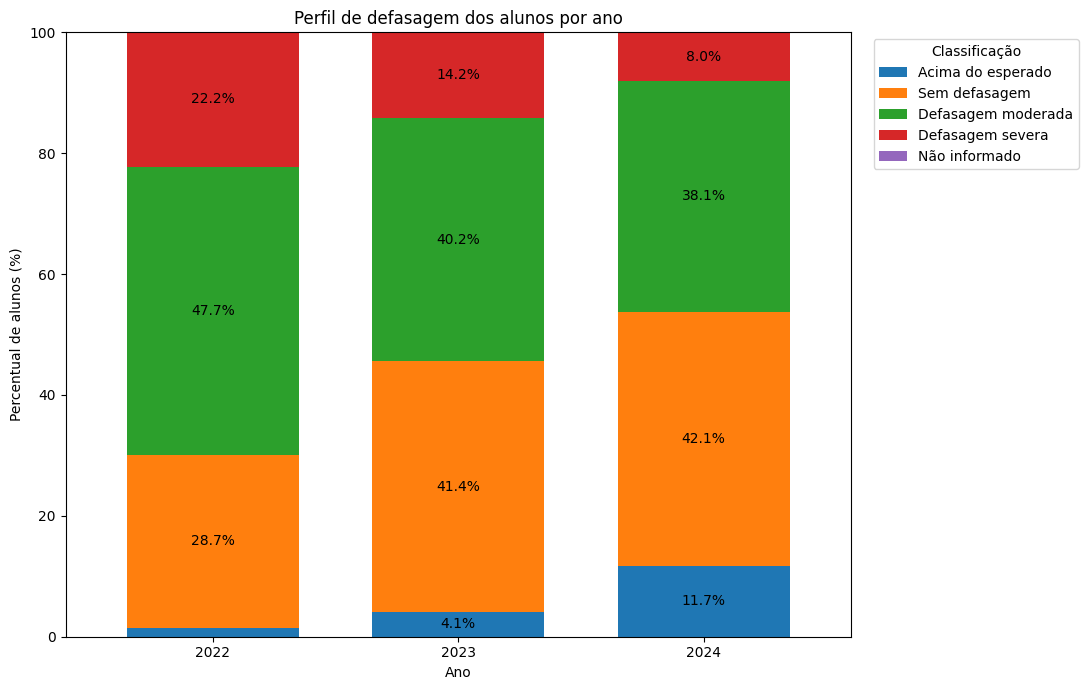

In [229]:
ax = grafico_categoria_ano.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 7),
    width=0.7
)

plt.title("Perfil de defasagem dos alunos por ano")
plt.xlabel("Ano")
plt.ylabel("Percentual de alunos (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)

plt.legend(
    title="Classificação",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

for linha, ano in enumerate(grafico_categoria_ano.index):
    altura_acumulada = 0

    for categoria in grafico_categoria_ano.columns:
        percentual = grafico_categoria_ano.loc[
            ano,
            categoria
        ]

        if percentual >= 3:
            plt.text(
                linha,
                altura_acumulada + percentual / 2,
                f"{percentual:.1f}%",
                ha="center",
                va="center"
            )

        altura_acumulada += percentual

plt.tight_layout()
plt.show()

In [230]:
alunos_em_defasagem = (
    df_pede[
        df_pede["categoria_defasagem"].isin([
            "Defasagem moderada",
            "Defasagem severa"
        ])
    ]
    .groupby(
        ["ano", "categoria_defasagem"],
        observed=False
    )
    .size()
    .reset_index(name="quantidade")
)

alunos_em_defasagem = alunos_em_defasagem[
    alunos_em_defasagem["quantidade"] > 0
]

alunos_em_defasagem

,ano,categoria_defasagem,quantidade
2,2022,Defasagem moderada,410
3,2022,Defasagem severa,191
7,2023,Defasagem moderada,408
8,2023,Defasagem severa,144
12,2024,Defasagem moderada,441
13,2024,Defasagem severa,93


In [231]:
ian_por_defasagem = (
    df_pede
    .groupby(
        "categoria_defasagem",
        observed=False
    )["ian"]
    .agg(
        quantidade="count",
        media="mean",
        mediana="median"
    )
    .round(2)
    .reset_index()
)

ian_por_defasagem

,categoria_defasagem,quantidade,media,mediana
0,Acima do esperado,189,10.00,10.00
1,Sem defasagem,1154,10.00,10.00
2,Defasagem moderada,1259,5.00,5.00
3,Defasagem severa,428,4.74,5.00
4,Não informado,0,NaN,NaN


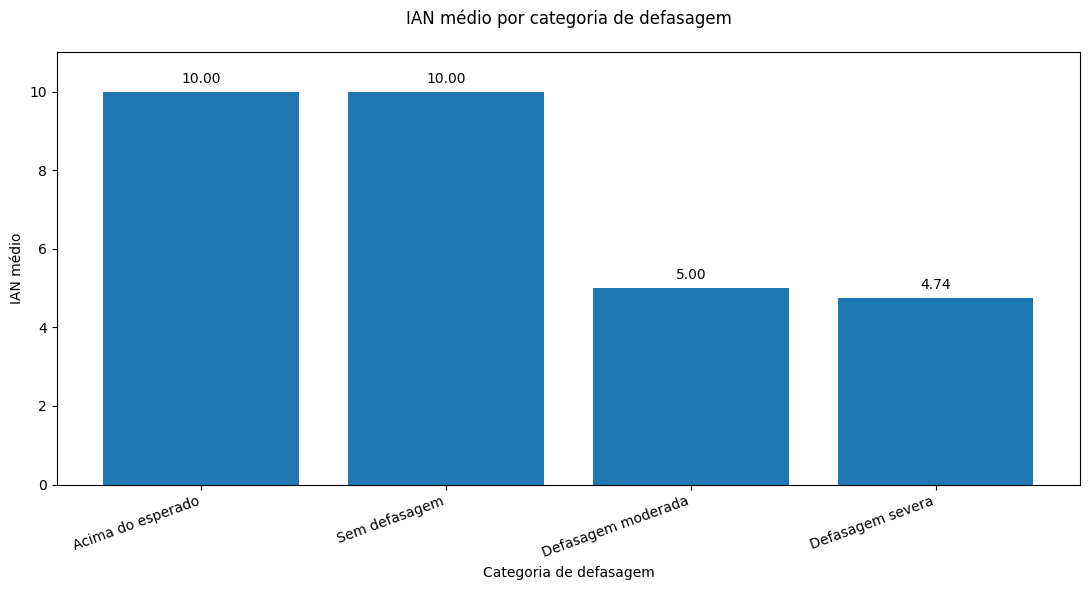

In [232]:
plt.figure(figsize=(11, 6))

barras = plt.bar(
    ian_por_defasagem["categoria_defasagem"].astype(str),
    ian_por_defasagem["media"]
)

plt.title(
    "IAN médio por categoria de defasagem",
    pad=20
)

plt.xlabel("Categoria de defasagem")
plt.ylabel("IAN médio")

plt.ylim(0, 11)

plt.xticks(
    rotation=20,
    ha="right"
)

for barra, valor in zip(
    barras,
    ian_por_defasagem["media"]
):
    if pd.notna(valor):
        plt.text(
            barra.get_x() + barra.get_width() / 2,
            valor + 0.15,
            f"{valor:.2f}",
            ha="center",
            va="bottom"
        )

plt.tight_layout()
plt.show()

### 2.2 Evolução longitudinal da defasagem

A comparação anual anterior considera todos os alunos disponíveis em cada ano. Entretanto, a composição do grupo pode mudar com a entrada e a saída de participantes.

Para avaliar a evolução de maneira mais consistente, esta seção acompanha somente os alunos presentes em dois anos consecutivos:

- 2022 para 2023;
- 2023 para 2024.

A variação foi calculada pela diferença entre a defasagem do ano final e a defasagem do ano inicial.

- valor positivo: o aluno melhorou;
- valor zero: o aluno permaneceu estável;
- valor negativo: o aluno piorou.

Como a base contém uma avaliação anual, a análise representa a evolução entre anos, e não mudanças ocorridas dentro de um mesmo ano.

In [233]:
def analisar_periodo(df, ano_inicial, ano_final):

    dados_iniciais = (
        df[df["ano"] == ano_inicial][
            ["ra", "defasagem"]
        ]
        .rename(
            columns={
                "defasagem": "defasagem_inicial"
            }
        )
    )

    dados_finais = (
        df[df["ano"] == ano_final][
            ["ra", "defasagem"]
        ]
        .rename(
            columns={
                "defasagem": "defasagem_final"
            }
        )
    )

    comparacao = dados_iniciais.merge(
        dados_finais,
        on="ra",
        how="inner"
    )

    comparacao = comparacao.dropna(
        subset=[
            "defasagem_inicial",
            "defasagem_final"
        ]
    ).copy()

    comparacao["periodo"] = (
        f"{ano_inicial} → {ano_final}"
    )

    comparacao["variacao_defasagem"] = (
        comparacao["defasagem_final"]
        - comparacao["defasagem_inicial"]
    )

    def classificar_evolucao(variacao):

        if variacao > 0:
            return "Melhorou"

        if variacao < 0:
            return "Piorou"

        return "Permaneceu estável"

    comparacao["evolucao"] = (
        comparacao["variacao_defasagem"]
        .apply(classificar_evolucao)
    )

    return comparacao


evolucao_2022_2023 = analisar_periodo(
    df_pede,
    2022,
    2023
)

evolucao_2023_2024 = analisar_periodo(
    df_pede,
    2023,
    2024
)

evolucao_longitudinal = pd.concat(
    [
        evolucao_2022_2023,
        evolucao_2023_2024
    ],
    ignore_index=True
)

print(
    "Alunos comparados em 2022 → 2023:",
    len(evolucao_2022_2023)
)

print(
    "Alunos comparados em 2023 → 2024:",
    len(evolucao_2023_2024)
)

Alunos comparados em 2022 → 2023: 600
Alunos comparados em 2023 → 2024: 765


In [234]:
ordem_evolucao = [
    "Melhorou",
    "Permaneceu estável",
    "Piorou"
]

resumo_evolucao = (
    evolucao_longitudinal
    .groupby(
        ["periodo", "evolucao"]
    )
    .size()
    .reset_index(
        name="quantidade"
    )
)

resumo_evolucao["percentual"] = (
    resumo_evolucao
    .groupby("periodo")["quantidade"]
    .transform(
        lambda valores:
            valores / valores.sum() * 100
    )
)

grafico_evolucao = (
    resumo_evolucao
    .pivot(
        index="periodo",
        columns="evolucao",
        values="percentual"
    )
    .reindex(
        columns=ordem_evolucao
    )
    .fillna(0)
)

grafico_evolucao.round(2)

evolucao,Melhorou,Permaneceu estável,Piorou
periodo,,,
2022 → 2023,30.83,51.83,17.33
2023 → 2024,40.92,41.83,17.25


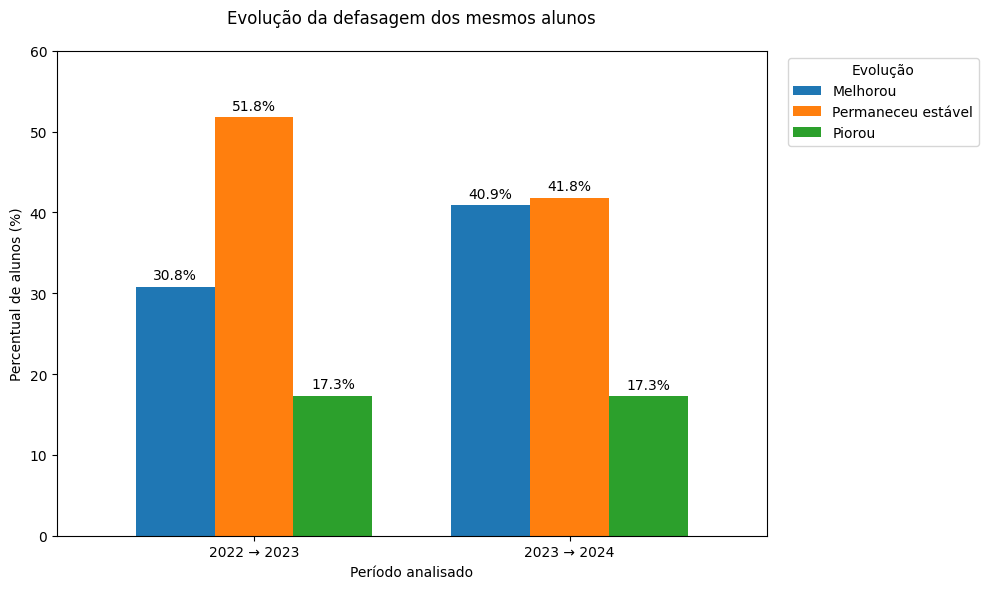

In [235]:
ax = grafico_evolucao.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.75
)

plt.title(
    "Evolução da defasagem dos mesmos alunos",
    pad=20
)

plt.xlabel("Período analisado")
plt.ylabel("Percentual de alunos (%)")
plt.xticks(rotation=0)
plt.ylim(0, 60)

plt.legend(
    title="Evolução",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

### 2.3 Entrada e saída da defasagem

Uma melhora na variável de defasagem não significa necessariamente que o aluno tenha alcançado sua fase ideal.

Por exemplo, um aluno pode passar de duas fases abaixo do ideal para apenas uma fase abaixo. Nesse caso, ele melhorou, mas ainda permanece defasado.

Por isso, os alunos também foram classificados de acordo com sua situação no início e no final de cada período.

In [236]:
def classificar_situacao(linha):

    estava_defasado = (
        linha["defasagem_inicial"] < 0
    )

    ficou_defasado = (
        linha["defasagem_final"] < 0
    )

    if estava_defasado and not ficou_defasado:
        return "Saiu da defasagem"

    if not estava_defasado and ficou_defasado:
        return "Entrou em defasagem"

    if estava_defasado and ficou_defasado:
        return "Permaneceu em defasagem"

    return "Permaneceu sem defasagem"


evolucao_longitudinal["situacao_defasagem"] = (
    evolucao_longitudinal
    .apply(
        classificar_situacao,
        axis=1
    )
)

ordem_situacao = [
    "Saiu da defasagem",
    "Entrou em defasagem",
    "Permaneceu em defasagem",
    "Permaneceu sem defasagem"
]

resumo_situacao = (
    evolucao_longitudinal
    .groupby(
        [
            "periodo",
            "situacao_defasagem"
        ]
    )
    .size()
    .reset_index(
        name="quantidade"
    )
)

resumo_situacao["percentual"] = (
    resumo_situacao
    .groupby("periodo")["quantidade"]
    .transform(
        lambda valores:
            valores / valores.sum() * 100
    )
)

grafico_situacao = (
    resumo_situacao
    .pivot(
        index="periodo",
        columns="situacao_defasagem",
        values="percentual"
    )
    .reindex(
        columns=ordem_situacao
    )
    .fillna(0)
)

grafico_situacao.round(2)

situacao_defasagem,Saiu da defasagem,Entrou em defasagem,Permaneceu em defasagem,Permaneceu sem defasagem
periodo,,,,
2022 → 2023,17.50,10.00,51.00,21.50
2023 → 2024,22.35,10.98,29.28,37.39


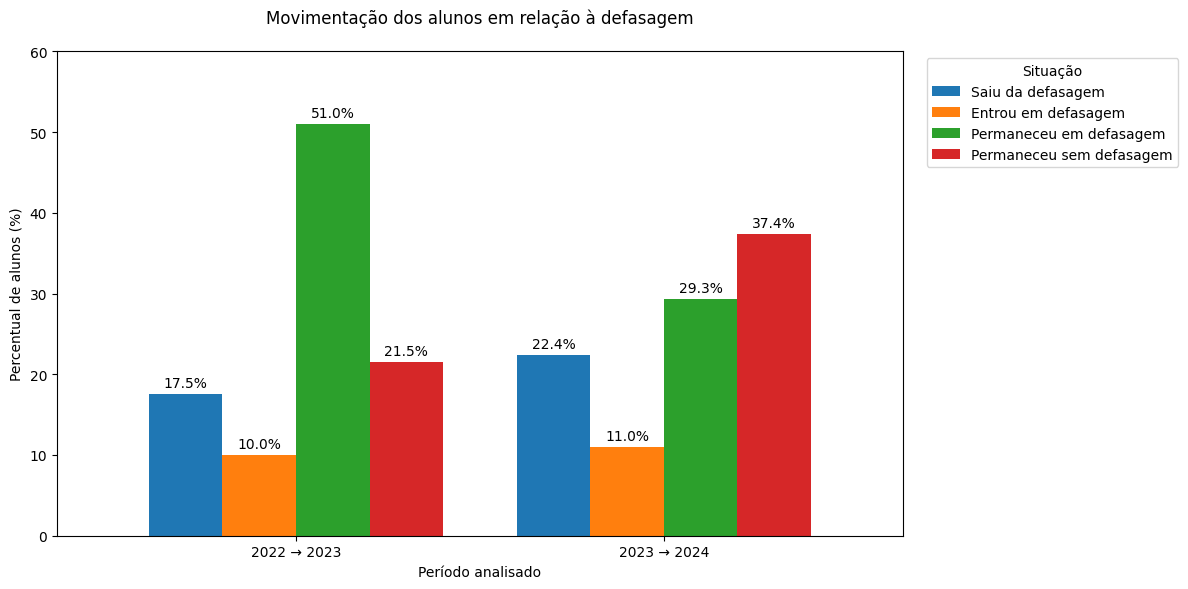

In [237]:
ax = grafico_situacao.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8
)

plt.title(
    "Movimentação dos alunos em relação à defasagem",
    pad=20
)

plt.xlabel("Período analisado")
plt.ylabel("Percentual de alunos (%)")
plt.xticks(rotation=0)
plt.ylim(0, 60)

plt.legend(
    title="Situação",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

### Resposta à Pergunta 1

A análise mostra uma redução relevante da defasagem educacional entre 2022 e 2024.

Em 2022, 410 alunos, correspondentes a 47,7% dos registros, apresentavam defasagem moderada, enquanto 191 alunos, ou 22,2%, apresentavam defasagem severa. Dessa forma, 69,9% dos alunos estavam em algum nível de defasagem.

Em 2023, a proporção total de alunos defasados caiu para 54,4%. Foram identificados 408 alunos com defasagem moderada e 144 com defasagem severa.

Em 2024, 441 alunos apresentavam defasagem moderada e 93 apresentavam defasagem severa. Apesar do crescimento da quantidade total de alunos avaliados, a proporção de estudantes em defasagem caiu para 46,2%. A defasagem severa apresentou a redução mais expressiva, passando de 22,2% em 2022 para 8,0% em 2024.

A análise longitudinal reforça essa tendência. Entre os 600 alunos presentes em 2022 e 2023, 30,8% melhoraram sua condição de defasagem, 51,8% permaneceram estáveis e 17,3% pioraram. Nesse período, 17,5% saíram completamente da defasagem e 10,0% entraram em defasagem.

Entre os 765 alunos presentes em 2023 e 2024, a proporção que apresentou melhora aumentou para 40,9%, enquanto 17,3% pioraram. Além disso, 22,4% saíram da defasagem e 11,0% entraram nessa condição. A proporção que permaneceu defasada caiu de 51,0% no primeiro período para 29,3% no segundo.

O IAN apresentou comportamento consistente com a classificação de defasagem. Alunos sem defasagem ou acima da fase esperada apresentaram IAN médio igual a 10, enquanto os alunos com defasagem moderada apresentaram média 5,0 e os alunos com defasagem severa apresentaram média aproximada de 4,74.

Essa relação era esperada, pois o IAN e a variável de defasagem estão diretamente relacionados em sua construção. Portanto, esse resultado funciona principalmente como uma validação da consistência dos dados, e não como uma descoberta independente.

Portanto, os dados indicam melhora progressiva na adequação dos alunos ao nível educacional, especialmente pela redução da defasagem severa e pelo aumento da proporção de alunos que melhoraram entre 2023 e 2024.

Entretanto, esses resultados representam associações observadas entre avaliações anuais. Embora a análise longitudinal acompanhe os mesmos alunos, a ausência de um grupo de controle não permite atribuir causalmente toda a melhora ao programa.


## 3. Pergunta 2 — Evolução do desempenho acadêmico (IDA)

**Pergunta de negócio:** Quais são as principais tendências observadas no desempenho acadêmico dos alunos, considerando o IDA, ao longo das fases e dos anos?

O IDA representa o desempenho acadêmico dos alunos. Nesta seção, serão analisados:

- o comportamento geral do IDA entre 2022, 2023 e 2024;
- as diferenças entre as fases do programa;
- a distribuição dos resultados;
- a evolução dos mesmos alunos em anos consecutivos.

As comparações utilizarão apenas registros com IDA disponível. Valores ausentes não serão substituídos por zero.

In [238]:
df_pede["ida"] = pd.to_numeric(
    df_pede["ida"],
    errors="coerce"
)

print("Valores válidos de IDA:", df_pede["ida"].notna().sum())
print("Valores ausentes de IDA:", df_pede["ida"].isna().sum())
print("Menor IDA:", df_pede["ida"].min())
print("Maior IDA:", df_pede["ida"].max())

Valores válidos de IDA: 2852
Valores ausentes de IDA: 178
Menor IDA: 0.0
Maior IDA: 10.0


In [239]:
resumo_ida_ano = (
    df_pede
    .groupby("ano")
    .agg(
        registros_validos=("ida", "count"),
        ida_media=("ida", "mean"),
        ida_mediana=("ida", "median"),
        desvio_padrao=("ida", "std"),
        ida_minimo=("ida", "min"),
        ida_maximo=("ida", "max")
    )
    .round(2)
    .reset_index()
)

resumo_ida_ano

,ano,registros_validos,ida_media,ida_mediana,desvio_padrao,ida_minimo,ida_maximo
0,2022,860,6.09,6.30,2.05,0.00,9.90
1,2023,937,6.66,6.80,1.60,0.00,10.00
2,2024,1055,6.35,6.75,2.13,0.00,10.00


### 3.1 Evolução geral do IDA por ano

A média e a mediana do IDA foram comparadas para verificar a tendência geral do desempenho acadêmico.

Como os grupos de alunos não são exatamente iguais em todos os anos, esta primeira comparação é transversal. Posteriormente, serão acompanhados somente os alunos presentes em anos consecutivos.

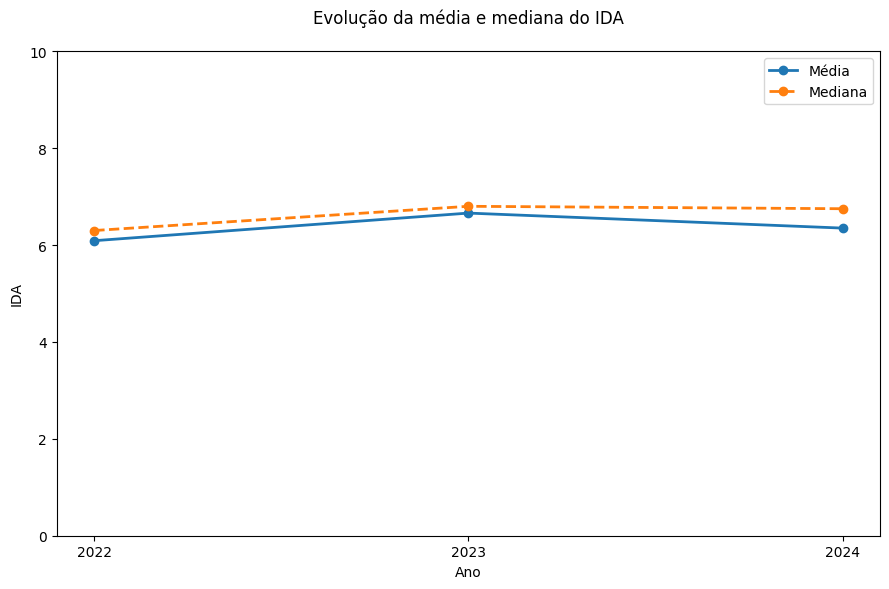

In [274]:
plt.figure(figsize=(9, 6))

plt.plot(
    resumo_ida_ano["ano"],
    resumo_ida_ano["ida_media"],
    marker="o",
    linewidth=2,
    label="Média"
)

plt.plot(
    resumo_ida_ano["ano"],
    resumo_ida_ano["ida_mediana"],
    marker="o",
    linewidth=2,
    linestyle="--",
    label="Mediana"
)

plt.title(
    "Evolução da média e mediana do IDA",
    pad=20
)

plt.xlabel("Ano")
plt.ylabel("IDA")
plt.xticks(resumo_ida_ano["ano"])
plt.ylim(0, 10)
plt.legend()

plt.tight_layout()
plt.show()

### Interpretação inicial

O IDA médio apresentou crescimento entre 2022 e 2023, indicando melhora no desempenho acadêmico geral dos registros disponíveis.

Em 2024, a média apresentou redução em relação a 2023, embora tenha permanecido acima do resultado observado em 2022.

Esse comportamento sugere que o melhor resultado médio ocorreu em 2023. Entretanto, a variação anual pode ser influenciada pela entrada e saída de alunos, pela distribuição dos estudantes entre as fases e pela disponibilidade dos dados.

Por esse motivo, a análise seguinte avaliará o IDA por fase e ano, permitindo identificar se a redução de 2024 está concentrada em determinados níveis do programa.

### 3.2 Desempenho acadêmico por fase e ano

A média geral do IDA pode esconder diferenças importantes entre as fases do programa.

Nesta análise, o IDA será comparado por fase e ano. Também será verificada a quantidade de registros válidos em cada grupo, pois médias calculadas com poucos alunos devem ser interpretadas com cautela.

In [241]:
resumo_ida_fase_ano = (
    df_pede
    .dropna(subset=["fase_num"])
    .groupby(
        ["fase_num", "ano"]
    )
    .agg(
        quantidade=("ida", "count"),
        ida_media=("ida", "mean"),
        ida_mediana=("ida", "median")
    )
    .reset_index()
)

resumo_ida_fase_ano["fase_num"] = (
    resumo_ida_fase_ano["fase_num"]
    .astype(int)
)

resumo_ida_fase_ano[
    ["ida_media", "ida_mediana"]
] = (
    resumo_ida_fase_ano[
        ["ida_media", "ida_mediana"]
    ]
    .round(2)
)

resumo_ida_fase_ano

,fase_num,ano,quantidade,ida_media,ida_mediana
0,0,2022,190,7.14,7.30
1,0,2023,231,7.42,7.80
2,0,2024,196,7.32,7.75
3,1,2022,192,6.46,6.80
4,1,2023,173,6.81,6.90
5,1,2024,185,6.79,7.25
6,2,2022,155,5.41,5.50
7,2,2023,199,6.74,6.80
8,2,2024,185,6.25,6.50
9,3,2022,148,5.14,5.20


In [242]:
matriz_ida_fase = (
    resumo_ida_fase_ano
    .pivot(
        index="fase_num",
        columns="ano",
        values="ida_media"
    )
    .sort_index()
)

matriz_ida_fase = matriz_ida_fase.dropna(
    how="all"
)

#removi a fase 9 da matriz pois so tinha NaN

matriz_ida_fase

ano,2022,2023,2024
fase_num,,,
0,7.14,7.42,7.32
1,6.46,6.81,6.79
2,5.41,6.74,6.25
3,5.14,5.75,5.35
4,6.05,6.00,5.88
5,5.87,5.90,6.45
6,6.69,6.81,7.23
7,5.25,7.81,5.81
8,NaN,NaN,8.00


In [243]:
matriz_quantidade_fase = (
    resumo_ida_fase_ano
    .pivot(
        index="fase_num",
        columns="ano",
        values="quantidade"
    )
    .reindex(
        index=matriz_ida_fase.index,
        columns=matriz_ida_fase.columns
    )
    .fillna(0)
    .astype(int)
)

matriz_quantidade_fase

ano,2022,2023,2024
fase_num,,,
0,190,231,196
1,192,173,185
2,155,199,185
3,148,132,211
4,76,94,115
5,60,65,100
6,18,33,25
7,21,10,37
8,0,0,1


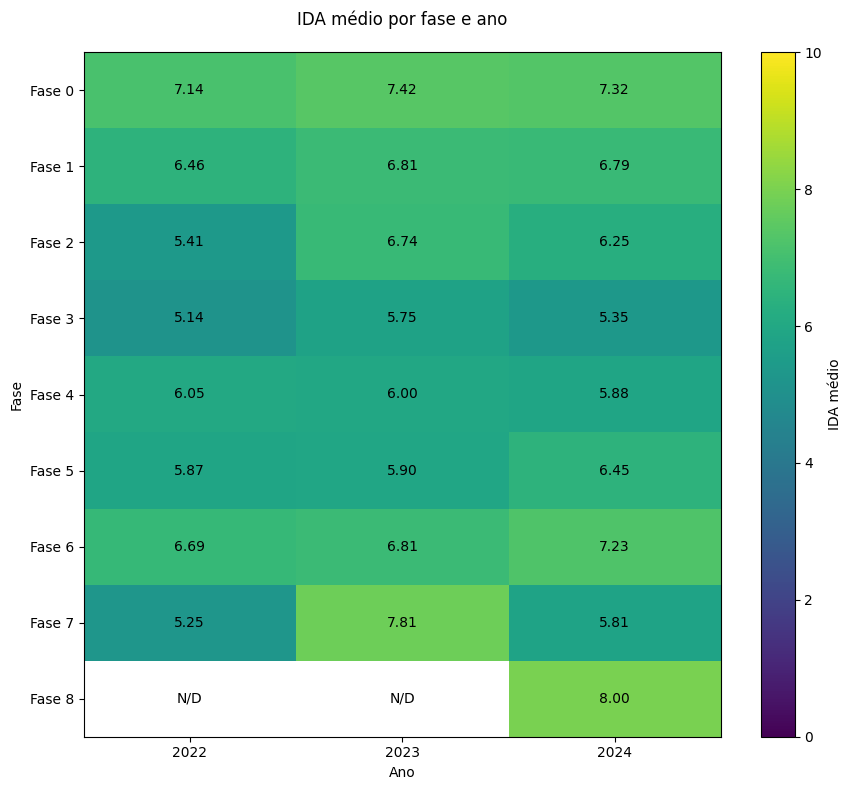

In [244]:
valores_grafico = np.ma.masked_invalid(
    matriz_ida_fase.values
)

plt.figure(figsize=(9, 8))

imagem = plt.imshow(
    valores_grafico,
    aspect="auto",
    vmin=0,
    vmax=10
)

plt.colorbar(
    imagem,
    label="IDA médio"
)

plt.xticks(
    range(len(matriz_ida_fase.columns)),
    matriz_ida_fase.columns
)

plt.yticks(
    range(len(matriz_ida_fase.index)),
    [
        f"Fase {int(fase)}"
        for fase in matriz_ida_fase.index
    ]
)

plt.title(
    "IDA médio por fase e ano",
    pad=20
)

plt.xlabel("Ano")
plt.ylabel("Fase")

for linha in range(matriz_ida_fase.shape[0]):
    for coluna in range(matriz_ida_fase.shape[1]):

        valor = matriz_ida_fase.iloc[
            linha,
            coluna
        ]

        texto = (
            f"{valor:.2f}"
            if pd.notna(valor)
            else "N/D"
        )

        plt.text(
            coluna,
            linha,
            texto,
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

### Quantidade de registros válidos por fase

As diferenças entre as médias devem ser analisadas junto com a quantidade de registros válidos.

Uma média baseada em poucos alunos é mais sensível a resultados individuais e pode não representar adequadamente toda a fase.

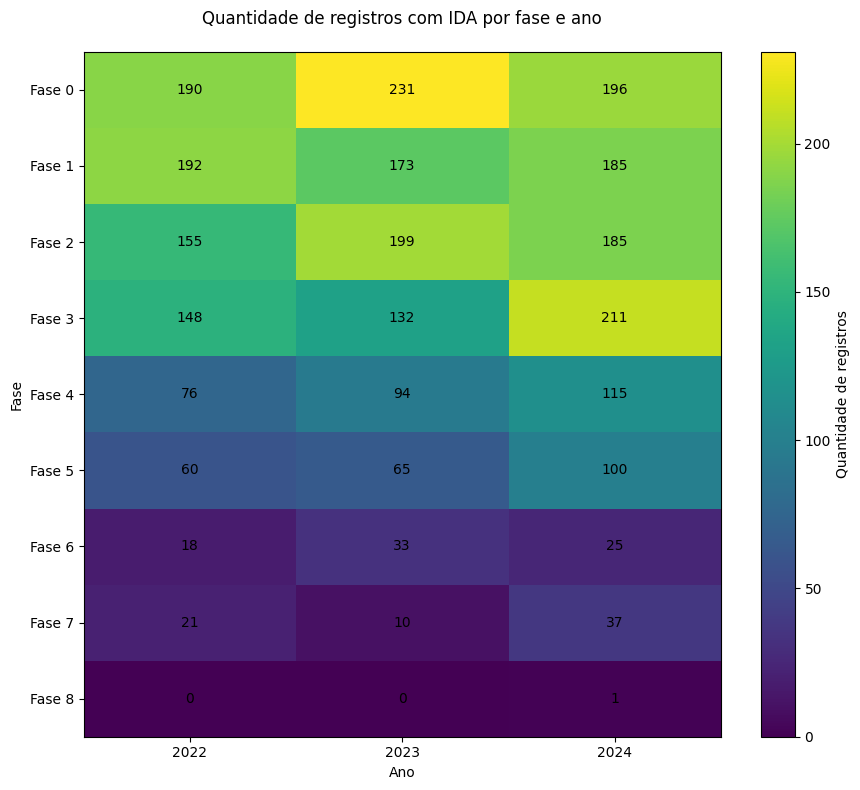

In [245]:
plt.figure(figsize=(9, 8))

imagem = plt.imshow(
    matriz_quantidade_fase.values,
    aspect="auto"
)

plt.colorbar(
    imagem,
    label="Quantidade de registros"
)

plt.xticks(
    range(len(matriz_quantidade_fase.columns)),
    matriz_quantidade_fase.columns
)

plt.yticks(
    range(len(matriz_quantidade_fase.index)),
    [
        f"Fase {int(fase)}"
        for fase in matriz_quantidade_fase.index
    ]
)

plt.title(
    "Quantidade de registros com IDA por fase e ano",
    pad=20
)

plt.xlabel("Ano")
plt.ylabel("Fase")

for linha in range(matriz_quantidade_fase.shape[0]):
    for coluna in range(
        matriz_quantidade_fase.shape[1]
    ):

        valor = matriz_quantidade_fase.iloc[
            linha,
            coluna
        ]

        if pd.notna(valor):
            texto = str(int(valor))
        else:
            texto = "0"

        plt.text(
            coluna,
            linha,
            texto,
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

### 3.3 Variação do IDA por fase

Para identificar as principais tendências, foi calculada a variação do IDA médio de cada fase entre anos consecutivos.

- resultado positivo: aumento do IDA médio;
- resultado próximo de zero: estabilidade;
- resultado negativo: redução do IDA médio.

Somente fases com dados disponíveis nos dois anos do período podem ser comparadas. Por isso, a Fase 8 não participa dessa comparação histórica.

In [246]:
variacao_ida_fase = pd.DataFrame(
    index=matriz_ida_fase.index
)

variacao_ida_fase["2022 → 2023"] = (
    matriz_ida_fase[2023]
    - matriz_ida_fase[2022]
)

variacao_ida_fase["2023 → 2024"] = (
    matriz_ida_fase[2024]
    - matriz_ida_fase[2023]
)

# Remove fases sem nenhuma comparação possível
variacao_ida_fase = (
    variacao_ida_fase
    .dropna(how="all")
    .round(2)
)

variacao_ida_fase

,2022 → 2023,2023 → 2024
fase_num,,
0,0.28,-0.10
1,0.35,-0.02
2,1.33,-0.49
3,0.61,-0.40
4,-0.05,-0.12
5,0.03,0.55
6,0.12,0.42
7,2.56,-2.00


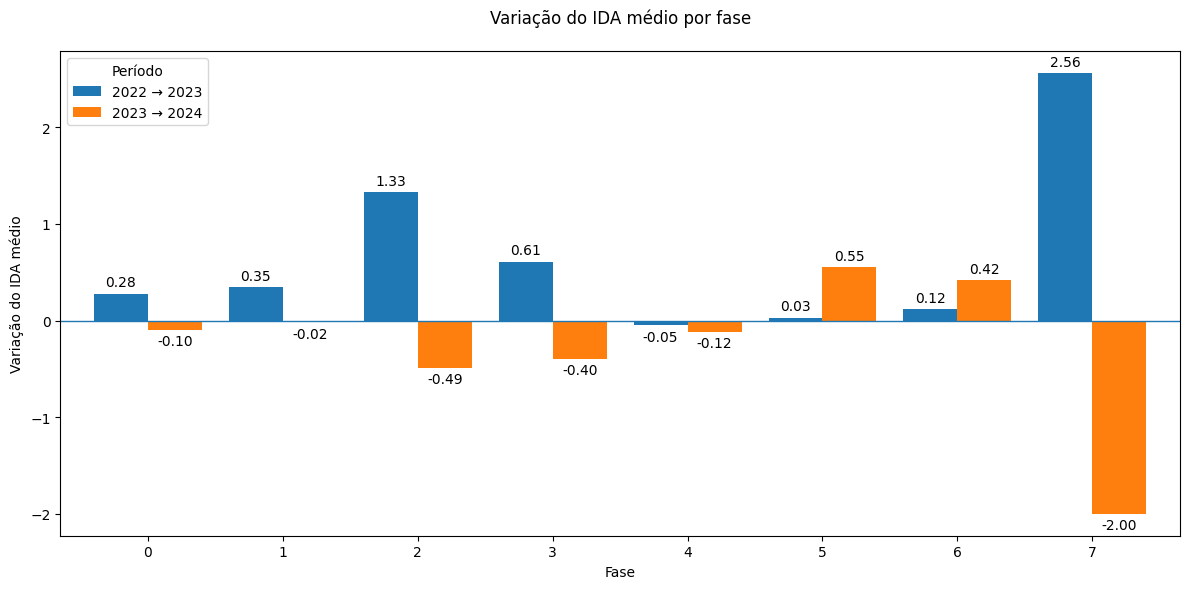

In [247]:
ax = variacao_ida_fase.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8
)

plt.axhline(
    y=0,
    linewidth=1
)

plt.title(
    "Variação do IDA médio por fase",
    pad=20
)

plt.xlabel("Fase")
plt.ylabel("Variação do IDA médio")

plt.xticks(
    rotation=0
)

plt.legend(
    title="Período"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3
    )

plt.tight_layout()
plt.show()

### Interpretação da variação por fase

A evolução do IDA não ocorreu de maneira uniforme entre as fases.

A Fase 6 apresentou crescimento nos dois períodos analisados, indicando uma tendência mais consistente de melhora. A Fase 5 também apresentou avanço relevante entre 2023 e 2024.

As Fases 2 e 3 melhoraram entre 2022 e 2023, mas apresentaram redução em 2024. Já a Fase 7 apresentou a maior oscilação: forte crescimento em 2023, seguido de queda expressiva em 2024.

As variações da Fase 7 devem ser interpretadas com cautela e em conjunto com a quantidade de registros válidos, pois grupos menores são mais sensíveis a resultados individuais.

De forma geral, os resultados mostram que a redução do IDA médio em 202 em 2024 não ocorreu em todas as fases. Algumas fases melhoraram, enquanto outras concentr fases melhoraram, enquanto outras concentraram as quedas.

### 3.4 Distribuição do IDA por ano

A média pode esconder diferenças importantes entre os alunos. Por isso, a distribuição do IDA foi analisada para comparar a mediana, a dispersão e a presença de resultados extremos em cada ano.

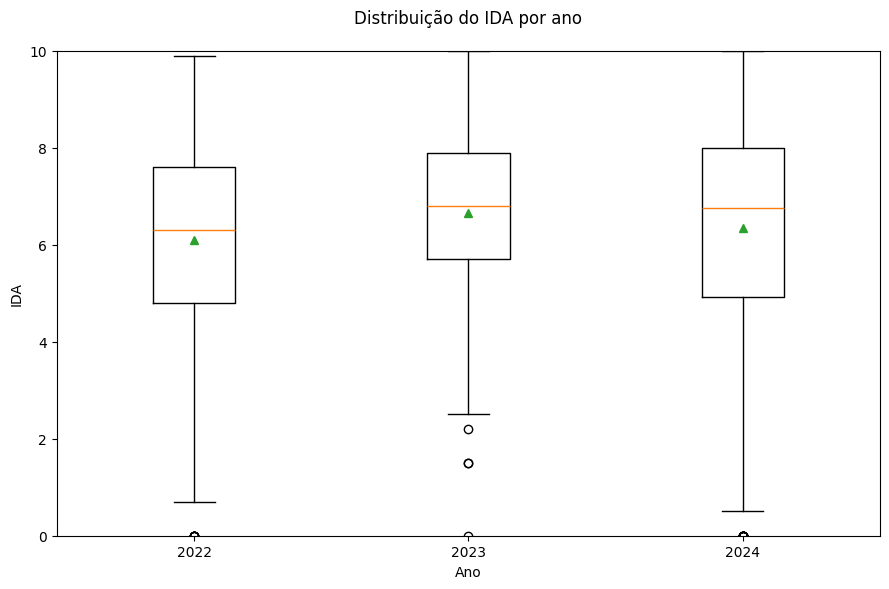

In [248]:
dados_ida_por_ano = [
    df_pede.loc[
        (df_pede["ano"] == ano) &
        (df_pede["ida"].notna()),
        "ida"
    ]
    for ano in sorted(df_pede["ano"].unique())
]

anos_ida = sorted(
    df_pede["ano"].unique()
)

plt.figure(figsize=(9, 6))

plt.boxplot(
    dados_ida_por_ano,
    tick_labels=anos_ida,
    showmeans=True
)

plt.title(
    "Distribuição do IDA por ano",
    pad=20
)

plt.xlabel("Ano")
plt.ylabel("IDA")
plt.ylim(0, 10)

plt.tight_layout()
plt.show()

### Interpretação da distribuição

A mediana do IDA aumentou de 6,30 em 2022 para 6,80 em 2023 e permaneceu próxima desse valor em 2024, com 6,75.

Entretanto, a dispersão aumentou em 2024. O desvio-padrão passou de 1,60 em 2023 para 2,13 em 2024, indicando maior diferença entre os resultados individuais dos alunos.

Assim, embora a mediana de 2024 tenha permanecido próxima à de 2023, houve maior presença de resultados baixos e maior heterogeneidade acadêmica.

### 3.5 Evolução longitudinal do IDA

A comparação das médias anuais considera grupos de alunos que podem ser diferentes. Por isso, esta análise acompanha somente os alunos com IDA disponível em dois anos consecutivos:

- 2022 para 2023;
- 2023 para 2024.

Para evitar que pequenas oscilações decimais sejam interpretadas como mudanças relevantes, foi adotado um limite operacional de 0,25 ponto:

- aumento superior a 0,25: melhorou;
- variação entre -0,25 e 0,25: permaneceu estável;
- redução superior a 0,25: piorou.

Esse limite não representa uma classificação oficial da Passos Mágicos. Ele foi adotado apenas para organizar a análise.

In [249]:
def analisar_evolucao_ida(
    dados,
    ano_inicial,
    ano_final,
    limite_estabilidade=0.25
):
    ida_inicial = (
        dados[dados["ano"] == ano_inicial][
            ["ra", "ida"]
        ]
        .rename(
            columns={
                "ida": "ida_inicial"
            }
        )
    )

    ida_final = (
        dados[dados["ano"] == ano_final][
            ["ra", "ida"]
        ]
        .rename(
            columns={
                "ida": "ida_final"
            }
        )
    )

    comparacao = ida_inicial.merge(
        ida_final,
        on="ra",
        how="inner"
    )

    comparacao = comparacao.dropna(
        subset=[
            "ida_inicial",
            "ida_final"
        ]
    ).copy()

    comparacao["periodo"] = (
        f"{ano_inicial} → {ano_final}"
    )

    comparacao["variacao_ida"] = (
        comparacao["ida_final"]
        - comparacao["ida_inicial"]
    )

    def classificar_variacao(valor):
        if valor > limite_estabilidade:
            return "Melhorou"

        if valor < -limite_estabilidade:
            return "Piorou"

        return "Permaneceu estável"

    comparacao["evolucao_ida"] = (
        comparacao["variacao_ida"]
        .apply(classificar_variacao)
    )

    return comparacao

In [250]:
ida_2022_2023 = analisar_evolucao_ida(
    df_pede,
    2022,
    2023
)

ida_2023_2024 = analisar_evolucao_ida(
    df_pede,
    2023,
    2024
)

evolucao_ida = pd.concat(
    [
        ida_2022_2023,
        ida_2023_2024
    ],
    ignore_index=True
)

print(
    "Alunos comparados em 2022 → 2023:",
    len(ida_2022_2023)
)

print(
    "Alunos comparados em 2023 → 2024:",
    len(ida_2023_2024)
)

Alunos comparados em 2022 → 2023: 574
Alunos comparados em 2023 → 2024: 682


In [251]:
resumo_longitudinal_ida = (
    evolucao_ida
    .groupby("periodo")
    .agg(
        alunos_comparados=("ra", "count"),
        ida_inicial_medio=("ida_inicial", "mean"),
        ida_final_medio=("ida_final", "mean"),
        variacao_media=("variacao_ida", "mean"),
        variacao_mediana=("variacao_ida", "median")
    )
    .round(2)
    .reset_index()
)

resumo_longitudinal_ida

,periodo,alunos_comparados,ida_inicial_medio,ida_final_medio,variacao_media,variacao_mediana
0,2022 → 2023,574,6.49,6.60,0.12,0.00
1,2023 → 2024,682,6.82,6.34,-0.48,-0.30


In [252]:
ordem_evolucao_ida = [
    "Melhorou",
    "Permaneceu estável",
    "Piorou"
]

resumo_evolucao_ida = (
    evolucao_ida
    .groupby(
        ["periodo", "evolucao_ida"]
    )
    .size()
    .reset_index(name="quantidade")
)

resumo_evolucao_ida["percentual"] = (
    resumo_evolucao_ida
    .groupby("periodo")["quantidade"]
    .transform(
        lambda valores:
            valores / valores.sum() * 100
    )
)

grafico_evolucao_ida = (
    resumo_evolucao_ida
    .pivot(
        index="periodo",
        columns="evolucao_ida",
        values="percentual"
    )
    .reindex(
        columns=ordem_evolucao_ida
    )
    .fillna(0)
)

grafico_evolucao_ida.round(2)

evolucao_ida,Melhorou,Permaneceu estável,Piorou
periodo,,,
2022 → 2023,41.64,14.98,43.38
2023 → 2024,35.63,13.93,50.44


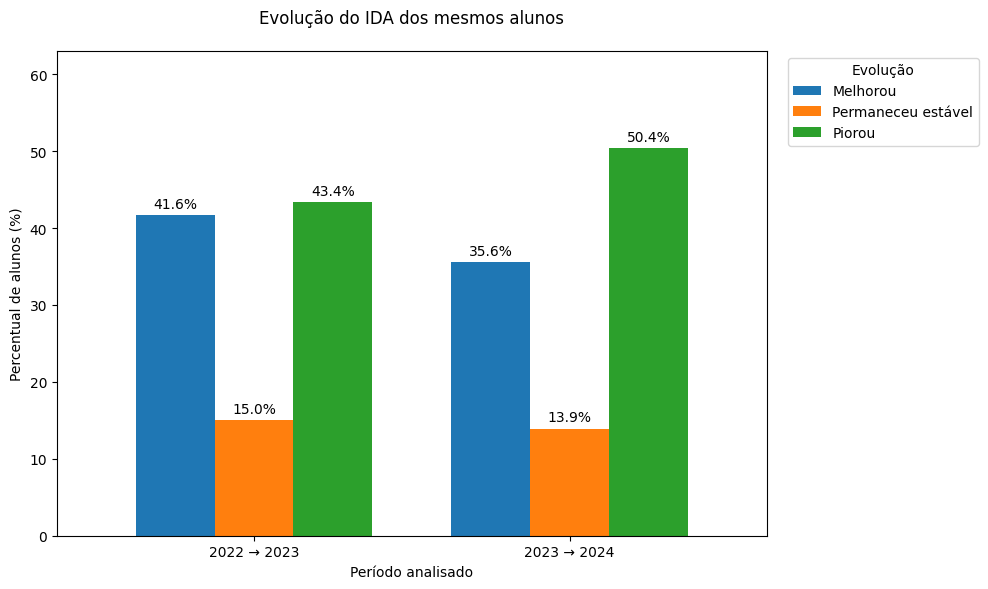

In [253]:
ax = grafico_evolucao_ida.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.75
)

plt.title(
    "Evolução do IDA dos mesmos alunos",
    pad=20
)

plt.xlabel("Período analisado")
plt.ylabel("Percentual de alunos (%)")
plt.xticks(rotation=0)
plt.ylim(
    0,
    grafico_evolucao_ida.max().max() * 1.25
)

plt.legend(
    title="Evolução",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

### Resposta à Pergunta 2

O desempenho acadêmico, representado pelo IDA, apresentou comportamentos diferentes ao longo dos anos e das fases do programa.

Na comparação geral, o IDA médio aumentou de 6,09 em  desempenho acadêmico, representado pelo IDA, apresentou comportamentos diferentes ao longo dos anos e das fases do programa.

Na comparação geral, o IDA médio aumentou de 6,09 em 2022 para 6,66 em 2023. Em 20242022 para 6,66 em 2023. Em 2024, houve redução para 6,35. Portanto, o melhor resultado médio foi observado em 2023, enquanto 2024 permaneceu acima de 2022, mas abaixo do ano anterior.

A análise por fase mostrou, houve redução para 6,35. Portanto, o melhor resultado médio foi observado em 2023, enquanto 2024 permaneceu acima de 2022, mas abaixo do ano anterior.

A análise por fase mostrou que essa evolução não ocorreu que essa evolução não ocorreu de maneira uniforme. As Fases 0 e 1 apresentaram resultados relativamente estáveis. As Fases 2 e 3 melhoraram entre 2022 e 2023, mas registraram queda em 2024. A Fase 4 apresentou pequenas reduções nos dois períodos.

As Fases 5 e 6 tiveram comportamento mais favorável em 2024. A Fase 5 aumentou seu IDA médio de 5,90 para 6,45, enquanto a Fase 6 passou de 6,81 para 7,23. A Fase 6 foi a única que apresentou crescimento nos dois períodos analisados.

A Fase 7 apresentou a maior oscilação: o de maneira uniforme. As Fases 0 e 1 apresentaram resultados relativamente estáveis. As Fases 2 e 3 melhoraram entre 2022 e 2023, mas registraram queda em 2024. A Fase 4 apresentou pequenas reduções nos dois períodos.

As Fases 5 e 6 tiveram comportamento mais favorável em 2024. A Fase 5 aumentou seu IDA médio de 5,90 para 6,45, enquanto a Fase 6 passou de 6,81 para 7,23. A Fase 6 apresentou a trajetória de crescimento mais consistente nos dois períodos analisados. A Fase 5 permaneceu praticamente estável entre 2022 e 2023 e avançou de forma mais clara em 2024.

A Fase 7 apresentou a maior oscilação, mas possuía apenas 21 registros válidos em 2022, 10 em 2023 e 37 em 2024. Portanto, suas médias são mais sensíveis a resultados individuais.

A Fase 8 possui IDA válido apenas em 2024, com média 8,00. Entretanto, essa média foi calculada com apenas um registro válido. Por isso, ela não deve ser interpretada como representativa do desempenho geral da fase nem comparada diretamente às demais fases.

A análise longitudinal reforça a mudança observada em 2024. Entre os 574 alunos acompanhados de 2022 para 2023, IDA médio aumentou de 5,25 em 2022 para 7,81 em 2023, mas caiu para 5,81 em 2024. Esse resultado deve ser interpretado junto com a quantidade de registros válidos da fase, pois grupos menores são mais sensíveis a resultados individuais.

A Fase 8 possui IDA apenas em 2024, com média 8,00. Como não existem dados dos anos anteriores, não é possível avaliar sua evolução histórica.

A análise longitudinal reforça a mudança observada em 2024. Entre os 574 alunos acompanhados de 2022 para 2023, o IDA médio aumentou de 6,49 para 6,60, representando uma variação média de 0,12 ponto. Nesse período, 41,6% melhoraram, 15,0% permaneceram estáveis e 43,4% pioraram.

Entre os 682 alunos acompanhados de 2023 para 2024, o IDA médio caiu de 6,82 para 6,34, o IDA médio aumentou de 6,49 para 6,60, representando uma variação média de 0,12 ponto. Nesse período, 41,6% melhoraram, 15,0% permaneceram estáveis e 43,4% pioraram.

Entre os 682 alunos acompanhados de 2023 para 2024, o IDA médio caiu de 6,82 para 6,34, uma redução média de 0,48 ponto. uma redução média de 0,48 ponto. A proporção de alunos que melhoraram A proporção de alunos que melhoraram caiu para 35,6%, enquanto 50,4% apresentaram pior caiu para 35,6%, enquanto 50,4% apresentaram piora. A mediana da variação foi de -0,30 ponto, indicandoa. A mediana da variação foi de -0,30 ponto, indicando que a queda não foi causada apenas por poucos resultados extremos que a queda não foi causada apenas por poucos resultados extremos.


Portanto, a principal tendência foi uma melhora geral em 2023 uma melhora geral em 2023, seguida de enfraquecimento do desempenho acadêm, seguida de enfraquecimento do desempenho acadêmico em 2024. Esse declínio não ocorreu em todas as fasesico em 2024. Esse declínio não ocorreu em todas as fases, mas foi suficientemente, mas foi suficientemente amplo para aparecer tanto nas médias amplo para aparecer tanto nas médias gerais quanto no acompanhamento dos mesmos alunos.

Os resultados sugerem que as Fases gerais quanto no acompanhamento dos mesmos alunos.

Os resultados sugerem que as Fases 2, 3 e 7 merecem maior atenção, 2, 3 e 7 merecem maior atenção, enquanto as Fases 5 e 6 apresentaram enquanto as Fases 5 e 6 apresentaram evolução mais positiva em 2024.

A classificação longitudinal evolução mais positiva em 2024.

A classificação longitudinal considerou como estáveis as variações entre -0,25 e  considerou como estáveis as variações entre -0,25 e 0,25 ponto. Esse limite é uma regra operacional adotada para a análise e não uma0,25 ponto. Esse limite é uma regra operacional adotada para a análise e não uma classificação oficial da Associação Passos Mágicos.

## 4. Pergunta 3 — Relação entre engajamento, desempenho acadêmico e ponto de virada

**Pergunta de negócio:** Qual é a relação entre o IEG e os indicadores IDA e IPV?

O IEG representa o engajamento do aluno nas atividades do programa. Nesta seção, será analisado se níveis mais altos de engajamento estão associados a:

- melhor desempenho acadêmico, representado pelo IDA;
- maior desenvolvimento e percepção de transformação, representados pelo IPV.

A análise será realizada por meio de correlações e gráficos de dispersão.

Como existem valores ausentes diferentes entre os indicadores, cada relação utilizará somente os registros em que os dois indicadores analisados estejam disponíveis.

In [254]:
colunas_pergunta_3 = [
    "ieg",
    "ida",
    "ipv"
]

for coluna in colunas_pergunta_3:
    df_pede[coluna] = pd.to_numeric(
        df_pede[coluna],
        errors="coerce"
    )

print("Indicadores preparados para análise.")

Indicadores preparados para análise.


In [255]:
dados_ieg_ida = (
    df_pede[
        ["ano", "ieg", "ida"]
    ]
    .dropna(
        subset=["ieg", "ida"]
    )
    .copy()
)

dados_ieg_ipv = (
    df_pede[
        ["ano", "ieg", "ipv"]
    ]
    .dropna(
        subset=["ieg", "ipv"]
    )
    .copy()
)

print(
    "Registros válidos para IEG × IDA:",
    len(dados_ieg_ida)
)

print(
    "Registros válidos para IEG × IPV:",
    len(dados_ieg_ipv)
)

Registros válidos para IEG × IDA: 2852
Registros válidos para IEG × IPV: 2852


In [256]:
correlacao_ieg_ida = (
    dados_ieg_ida["ieg"]
    .corr(dados_ieg_ida["ida"])
)

correlacao_ieg_ipv = (
    dados_ieg_ipv["ieg"]
    .corr(dados_ieg_ipv["ipv"])
)

correlacoes_gerais = pd.DataFrame({
    "relacao": [
        "IEG × IDA",
        "IEG × IPV"
    ],
    "quantidade_registros": [
        len(dados_ieg_ida),
        len(dados_ieg_ipv)
    ],
    "correlacao": [
        correlacao_ieg_ida,
        correlacao_ieg_ipv
    ]
})

correlacoes_gerais["correlacao"] = (
    correlacoes_gerais["correlacao"]
    .round(3)
)

correlacoes_gerais

,relacao,quantidade_registros,correlacao
0,IEG × IDA,2852,0.54
1,IEG × IPV,2852,0.56


A correlação varia entre -1 e 1. Como referência operacional para esta análise:

- até 0,19 em valor absoluto: muito fraca;
- de 0,20 a 0,39: fraca;
- de 0,40 a 0,59: moderada;
- de 0,60 a 0,79: forte;
- a partir de 0,80: muito forte.

In [257]:
correlacoes_por_ano = []

for ano in sorted(df_pede["ano"].unique()):

    dados_ano_ieg_ida = (
        dados_ieg_ida[
            dados_ieg_ida["ano"] == ano
        ]
    )

    dados_ano_ieg_ipv = (
        dados_ieg_ipv[
            dados_ieg_ipv["ano"] == ano
        ]
    )

    correlacoes_por_ano.append({
        "ano": ano,
        "correlacao_ieg_ida": (
            dados_ano_ieg_ida["ieg"]
            .corr(dados_ano_ieg_ida["ida"])
        ),
        "registros_ieg_ida": len(
            dados_ano_ieg_ida
        ),
        "correlacao_ieg_ipv": (
            dados_ano_ieg_ipv["ieg"]
            .corr(dados_ano_ieg_ipv["ipv"])
        ),
        "registros_ieg_ipv": len(
            dados_ano_ieg_ipv
        )
    })

correlacoes_por_ano = (
    pd.DataFrame(correlacoes_por_ano)
    .round(3)
)

correlacoes_por_ano

,ano,correlacao_ieg_ida,registros_ieg_ida,correlacao_ieg_ipv,registros_ieg_ipv
0,2022,0.56,860,0.59,860
1,2023,0.46,937,0.45,938
2,2024,0.54,1055,0.54,1054


### Interpretação inicial das correlações

As correlações entre o IEG e os indicadores IDA e IPV foram positivas e moderadas nos três anos analisados.

A relação entre engajamento e desempenho acadêmico apresentou correlação de 0,56 em 2022, 0,46 em 2023 e 0,54 em 2024. Isso indica que alunos com maior engajamento tendem a apresentar melhores resultados acadêmicos.

A relação entre engajamento e ponto de virada também foi positiva e moderada, com correlações de 0,59 em 2022, 0,45 em 2023 e 0,54 em 2024.

Em ambos os casos, a associação foi mais fraca em 2023, mas permaneceu positiva. Os resultados indicam uma relação consistente entre engajamento, desempenho acadêmico e desenvolvimento do aluno.

Entretanto, correlação não representa causalidade. Os resultados não comprovam que o aumento do engajamento cause diretamente a melhora dos demais indicadores.

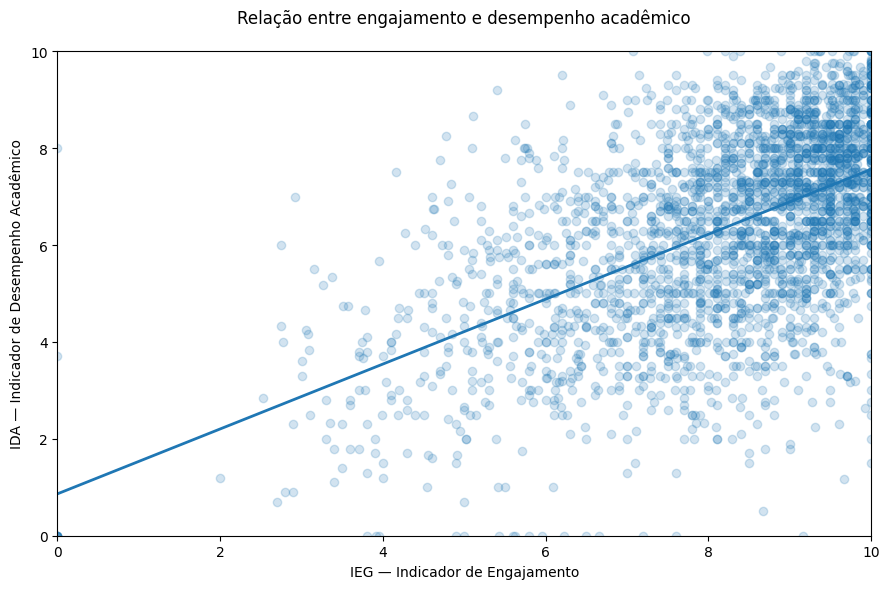

In [258]:
plt.figure(figsize=(9, 6))

plt.scatter(
    dados_ieg_ida["ieg"],
    dados_ieg_ida["ida"],
    alpha=0.20
)

coeficientes = np.polyfit(
    dados_ieg_ida["ieg"],
    dados_ieg_ida["ida"],
    1
)

valores_x = np.linspace(
    dados_ieg_ida["ieg"].min(),
    dados_ieg_ida["ieg"].max(),
    100
)

valores_y = (
    coeficientes[0] * valores_x
    + coeficientes[1]
)

plt.plot(
    valores_x,
    valores_y,
    linewidth=2
)

plt.title(
    "Relação entre engajamento e desempenho acadêmico",
    pad=20
)

plt.xlabel("IEG — Indicador de Engajamento")
plt.ylabel("IDA — Indicador de Desempenho Acadêmico")

plt.xlim(0, 10)
plt.ylim(0, 10)

plt.tight_layout()
plt.show()

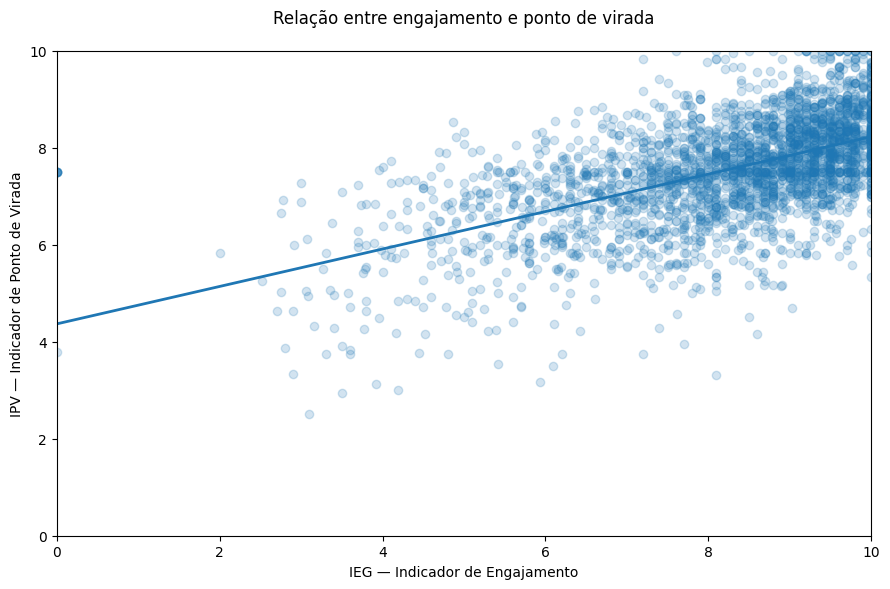

In [259]:
plt.figure(figsize=(9, 6))

plt.scatter(
    dados_ieg_ipv["ieg"],
    dados_ieg_ipv["ipv"],
    alpha=0.20
)

coeficientes = np.polyfit(
    dados_ieg_ipv["ieg"],
    dados_ieg_ipv["ipv"],
    1
)

valores_x = np.linspace(
    dados_ieg_ipv["ieg"].min(),
    dados_ieg_ipv["ieg"].max(),
    100
)

valores_y = (
    coeficientes[0] * valores_x
    + coeficientes[1]
)

plt.plot(
    valores_x,
    valores_y,
    linewidth=2
)

plt.title(
    "Relação entre engajamento e ponto de virada",
    pad=20
)

plt.xlabel("IEG — Indicador de Engajamento")
plt.ylabel("IPV — Indicador de Ponto de Virada")

plt.xlim(0, 10)
plt.ylim(0, 10)

plt.tight_layout()
plt.show()

### 4.1 Desempenho por faixa de engajamento

Para tornar a relação entre os indicadores mais fácil de interpretar, os alunos foram divididos em três faixas operacionais de IEG:

- **Baixo engajamento:** IEG inferior a 5;
- **Médio engajamento:** IEG entre 5 e 7,49;
- **Alto engajamento:** IEG igual ou superior a 7,5.

Essas faixas foram criadas exclusivamente para esta análise e não representam uma classificação oficial da Associação Passos Mágicos.

Para comparar o IDA e o IPV no mesmo gráfico, foram utilizados somente os registros que possuem os três indicadores preenchidos.

In [260]:
dados_faixas_ieg = (
    df_pede[
        ["ano", "ieg", "ida", "ipv"]
    ]
    .dropna(
        subset=["ieg", "ida", "ipv"]
    )
    .copy()
)

faixas_ieg = [
    -0.01,
    5,
    7.5,
    10.01
]

nomes_faixas_ieg = [
    "Baixo",
    "Médio",
    "Alto"
]

dados_faixas_ieg["faixa_ieg"] = pd.cut(
    dados_faixas_ieg["ieg"],
    bins=faixas_ieg,
    labels=nomes_faixas_ieg,
    right=False
)

print(
    "Registros utilizados:",
    len(dados_faixas_ieg)
)

Registros utilizados: 2851


In [261]:
resumo_faixas_ieg = (
    dados_faixas_ieg
    .groupby(
        "faixa_ieg",
        observed=False
    )
    .agg(
        quantidade=("ieg", "count"),
        ieg_medio=("ieg", "mean"),
        ida_medio=("ida", "mean"),
        ipv_medio=("ipv", "mean")
    )
    .round(2)
    .reset_index()
)

resumo_faixas_ieg

,faixa_ieg,quantidade,ieg_medio,ida_medio,ipv_medio
0,Baixo,130,3.82,3.48,5.91
1,Médio,567,6.48,5.19,6.85
2,Alto,2154,8.96,6.86,7.83


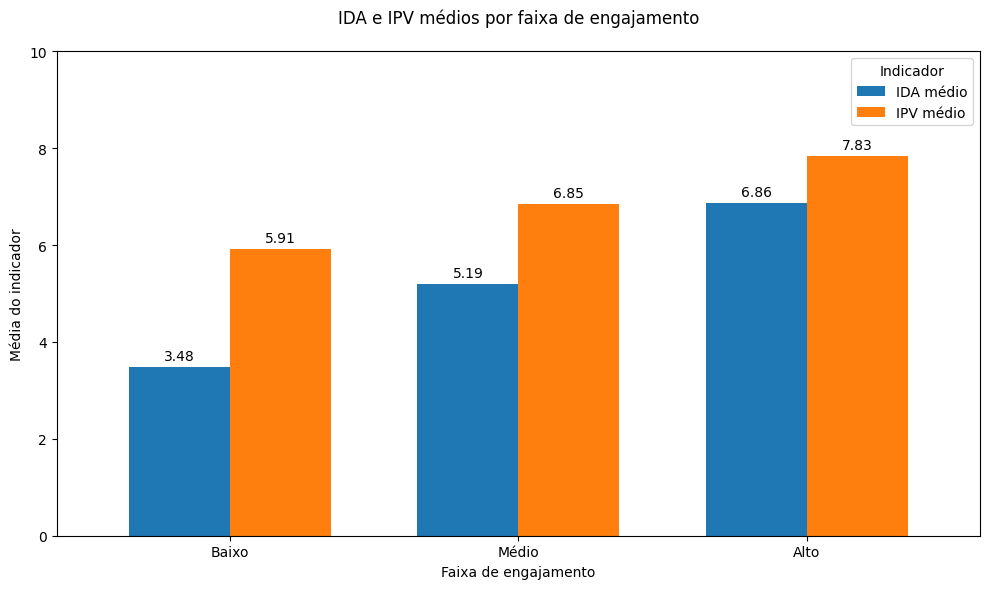

In [262]:
ax = resumo_faixas_ieg.plot(
    x="faixa_ieg",
    y=[
        "ida_medio",
        "ipv_medio"
    ],
    kind="bar",
    figsize=(10, 6),
    width=0.7
)

plt.title(
    "IDA e IPV médios por faixa de engajamento",
    pad=20
)

plt.xlabel("Faixa de engajamento")
plt.ylabel("Média do indicador")
plt.xticks(rotation=0)
plt.ylim(0, 10)

plt.legend(
    labels=[
        "IDA médio",
        "IPV médio"
    ],
    title="Indicador"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3
    )

plt.tight_layout()
plt.show()

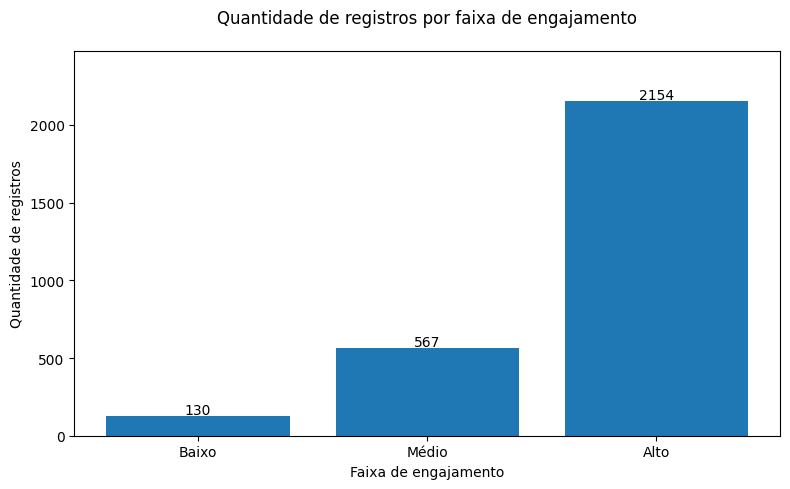

In [263]:
plt.figure(figsize=(8, 5))

barras = plt.bar(
    resumo_faixas_ieg["faixa_ieg"].astype(str),
    resumo_faixas_ieg["quantidade"]
)

plt.title(
    "Quantidade de registros por faixa de engajamento",
    pad=20
)

plt.xlabel("Faixa de engajamento")
plt.ylabel("Quantidade de registros")

for barra, quantidade in zip(
    barras,
    resumo_faixas_ieg["quantidade"]
):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        quantidade + 10,
        str(int(quantidade)),
        ha="center"
    )

plt.ylim(
    0,
    resumo_faixas_ieg["quantidade"].max() * 1.15
)

plt.tight_layout()
plt.show()

### Resposta à Pergunta 3

Os resultados indicam uma associação positiva e moderada entre o engajamento dos alunos, representado pelo IEG, e os indicadores IDA e IPV.

A correlação entre IEG e IDA foi de 0,56 em 2022, 0,46 em 2023 e 0,54 em 2024. Portanto, alunos com maior engajamento tenderam a apresentar melhor desempenho acadêmico nos três anos analisados.

A relação entre IEG e IPV apresentou comportamento semelhante. As correlações foram de 0,59 em 2022, 0,45 em 2023 e 0,54 em 2024, indicando que maiores níveis de engajamento também estiveram associados a resultados mais elevados no indicador de ponto de virada.

A análise por faixas de engajamento reforçou esse padrão. Nos registros classificados como baixo engajamento, o IDA médio foi de 3,48 e o IPV médio foi de 5,91. Na faixa de médio engajamento, esses valores aumentaram para 5,19 e 6,85, respectivamente.

Entre os registros classificados como alto engajamento, o IDA médio alcançou 6,86 e o IPV médio chegou a 7,83. Assim, entre as faixas de baixo e alto engajamento, foi observado um aumento de 3,38 pontos no IDA médio e de 1,92 ponto no IPV médio.

Os resultados mostram uma progressão consistente: quanto maior a faixa de engajamento, maiores foram, em média, o desempenho acadêmico e o indicador de ponto de virada.

Entretanto, essa análise identifica associação, e não causalidade. Não é possível afirmar somente com esses resultados que o aumento do engajamento causa diretamente a melhora do IDA ou do IPV. Outros fatores acadêmicos, pessoais e psicossociais também podem influenciar simultaneamente os indicadores.

Também existe diferença relevante no tamanho dos grupos: foram utilizados 130 registros na faixa de baixo engajamento, 567 na faixa intermediária e 2.154 na faixa de alto engajamento. Portanto, os resultados do grupo de baixo engajamento devem ser interpretados com maior cautela.

De forma gerencial, os resultados sugerem que alunos com baixo IEG constituem um grupo prioritário para acompanhamento, pois apresentam simultaneamente médias mais baixas de desempenho acadêmico e de ponto de virada.

## 5. Pergunta 4 — Consistência entre autoavaliação, desempenho e engajamento

**Pergunta de negócio:** Existe consistência entre a autoavaliação dos alunos, representada pelo IAA, e seus resultados de desempenho acadêmico e engajamento, representados pelo IDA e pelo IEG?

O IAA representa a percepção do aluno sobre seu próprio desenvolvimento. Nesta seção, será analisado se essa percepção acompanha:

- o desempenho acadêmico, medido pelo IDA;
- o engajamento nas atividades, medido pelo IEG.

A análise utilizará correlações e diferenças entre os indicadores, além de uma classificação operacional dos níveis de alinhamento.

Como os indicadores representam dimensões diferentes, uma diferença entre eles não será interpretada automaticamente como erro de percepção. O objetivo é identificar padrões de alinhamento e possíveis grupos que merecem acompanhamento.

In [264]:
colunas_pergunta_4 = [
    "iaa",
    "ida",
    "ieg"
]

for coluna in colunas_pergunta_4:
    df_pede[coluna] = pd.to_numeric(
        df_pede[coluna],
        errors="coerce"
    )

print("Indicadores preparados para análise.")

Indicadores preparados para análise.


In [265]:
dados_iaa_ida = (
    df_pede[
        ["ano", "iaa", "ida"]
    ]
    .dropna(
        subset=["iaa", "ida"]
    )
    .copy()
)

dados_iaa_ieg = (
    df_pede[
        ["ano", "iaa", "ieg"]
    ]
    .dropna(
        subset=["iaa", "ieg"]
    )
    .copy()
)

print(
    "Registros válidos para IAA × IDA:",
    len(dados_iaa_ida)
)

print(
    "Registros válidos para IAA × IEG:",
    len(dados_iaa_ieg)
)

Registros válidos para IAA × IDA: 2851
Registros válidos para IAA × IEG: 2852


In [266]:
correlacao_iaa_ida = (
    dados_iaa_ida["iaa"]
    .corr(dados_iaa_ida["ida"])
)

correlacao_iaa_ieg = (
    dados_iaa_ieg["iaa"]
    .corr(dados_iaa_ieg["ieg"])
)

correlacoes_iaa = pd.DataFrame({
    "relacao": [
        "IAA × IDA",
        "IAA × IEG"
    ],
    "quantidade_registros": [
        len(dados_iaa_ida),
        len(dados_iaa_ieg)
    ],
    "correlacao": [
        correlacao_iaa_ida,
        correlacao_iaa_ieg
    ]
})

correlacoes_iaa["correlacao"] = (
    correlacoes_iaa["correlacao"]
    .round(3)
)

correlacoes_iaa

,relacao,quantidade_registros,correlacao
0,IAA × IDA,2851,0.12
1,IAA × IEG,2852,0.13


In [267]:
correlacoes_iaa_por_ano = []

for ano in sorted(df_pede["ano"].unique()):

    dados_ano_iaa_ida = (
        dados_iaa_ida[
            dados_iaa_ida["ano"] == ano
        ]
    )

    dados_ano_iaa_ieg = (
        dados_iaa_ieg[
            dados_iaa_ieg["ano"] == ano
        ]
    )

    correlacoes_iaa_por_ano.append({
        "ano": ano,

        "correlacao_iaa_ida": (
            dados_ano_iaa_ida["iaa"]
            .corr(dados_ano_iaa_ida["ida"])
        ),

        "registros_iaa_ida": len(
            dados_ano_iaa_ida
        ),

        "correlacao_iaa_ieg": (
            dados_ano_iaa_ieg["iaa"]
            .corr(dados_ano_iaa_ieg["ieg"])
        ),

        "registros_iaa_ieg": len(
            dados_ano_iaa_ieg
        )
    })

correlacoes_iaa_por_ano = (
    pd.DataFrame(
        correlacoes_iaa_por_ano
    )
    .round(3)
)

correlacoes_iaa_por_ano

,ano,correlacao_iaa_ida,registros_iaa_ida,correlacao_iaa_ieg,registros_iaa_ieg
0,2022,0.21,860,0.32,860
1,2023,0.10,937,0.17,938
2,2024,0.22,1054,0.23,1054


### Interpretação inicial

As correlações entre o IAA e os indicadores IDA e IEG foram positivas, porém fracas.

No conjunto completo, a correlação entre IAA e IDA foi de 0,12, enquanto a correlação entre IAA e IEG foi de 0,13. Isso mostra que a autoavaliação dos alunos possui pouca associação linear com o desempenho acadêmico e com o engajamento.

Em 2022, as correlações foram um pouco maiores, principalmente entre IAA e IEG, que alcançou 0,32. Em 2023, as relações ficaram ainda mais fracas. Em 2024, houve pequena recuperação, mas as correlações permaneceram baixas.

Esses resultados não significam que a autoavaliação esteja incorreta. O IAA representa a percepção do aluno sobre seu desenvolvimento, enquanto o IDA e o IEG medem dimensões diferentes.

A próxima análise avaliará diretamente a diferença entre o IAA e os demais indicadores.

In [268]:
dados_consistencia = (
    df_pede[
        ["ano", "iaa", "ida", "ieg"]
    ]
    .dropna(
        subset=["iaa", "ida", "ieg"]
    )
    .copy()
)

dados_consistencia["diferenca_iaa_ida"] = (
    dados_consistencia["iaa"]
    - dados_consistencia["ida"]
)

dados_consistencia["diferenca_iaa_ieg"] = (
    dados_consistencia["iaa"]
    - dados_consistencia["ieg"]
)

print(
    "Registros com os três indicadores:",
    len(dados_consistencia)
)

Registros com os três indicadores: 2851


In [269]:
resumo_diferencas = pd.DataFrame({
    "comparacao": [
        "IAA − IDA",
        "IAA − IEG"
    ],
    "diferenca_media": [
        dados_consistencia[
            "diferenca_iaa_ida"
        ].mean(),
        dados_consistencia[
            "diferenca_iaa_ieg"
        ].mean()
    ],
    "diferenca_mediana": [
        dados_consistencia[
            "diferenca_iaa_ida"
        ].median(),
        dados_consistencia[
            "diferenca_iaa_ieg"
        ].median()
    ],
    "diferenca_absoluta_media": [
        dados_consistencia[
            "diferenca_iaa_ida"
        ].abs().mean(),
        dados_consistencia[
            "diferenca_iaa_ieg"
        ].abs().mean()
    ]
}).round(2)

resumo_diferencas

,comparacao,diferenca_media,diferenca_mediana,diferenca_absoluta_media
0,IAA − IDA,1.55,1.80,2.75
1,IAA − IEG,-0.30,0.00,1.84


In [270]:
def classificar_alinhamento(diferenca):
    if diferenca > 1:
        return "IAA acima"

    if diferenca < -1:
        return "IAA abaixo"

    return "Alinhado"


dados_consistencia["alinhamento_iaa_ida"] = (
    dados_consistencia[
        "diferenca_iaa_ida"
    ]
    .apply(classificar_alinhamento)
)

dados_consistencia["alinhamento_iaa_ieg"] = (
    dados_consistencia[
        "diferenca_iaa_ieg"
    ]
    .apply(classificar_alinhamento)
)

In [271]:
resumo_alinhamento = []

comparacoes = {
    "IAA × IDA": "alinhamento_iaa_ida",
    "IAA × IEG": "alinhamento_iaa_ieg"
}

for comparacao, coluna in comparacoes.items():

    contagem = (
        dados_consistencia[coluna]
        .value_counts()
    )

    for categoria, quantidade in contagem.items():

        resumo_alinhamento.append({
            "comparacao": comparacao,
            "categoria": categoria,
            "quantidade": quantidade,
            "percentual": (
                quantidade
                / len(dados_consistencia)
                * 100
            )
        })

resumo_alinhamento = pd.DataFrame(
    resumo_alinhamento
)

grafico_alinhamento = (
    resumo_alinhamento
    .pivot(
        index="comparacao",
        columns="categoria",
        values="percentual"
    )
    .reindex(
        columns=[
            "IAA abaixo",
            "Alinhado",
            "IAA acima"
        ]
    )
    .fillna(0)
)

grafico_alinhamento.round(2)

categoria,IAA abaixo,Alinhado,IAA acima
comparacao,,,
IAA × IDA,11.50,23.33,65.17
IAA × IEG,23.64,49.70,26.66


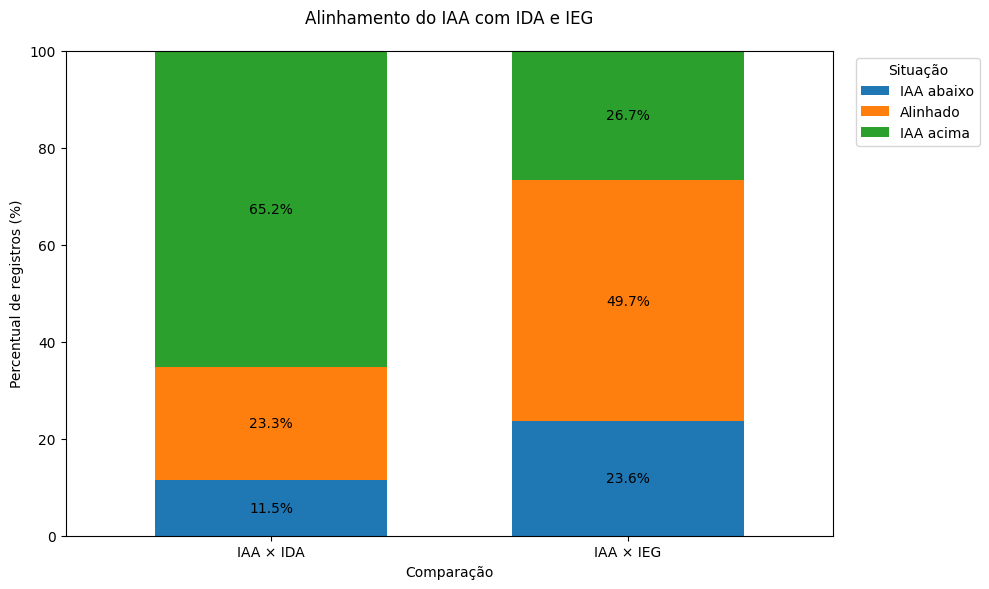

In [272]:
ax = grafico_alinhamento.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    width=0.65
)

plt.title(
    "Alinhamento do IAA com IDA e IEG",
    pad=20
)

plt.xlabel("Comparação")
plt.ylabel("Percentual de registros (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)

plt.legend(
    title="Situação",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

for linha, comparacao in enumerate(
    grafico_alinhamento.index
):
    acumulado = 0

    for categoria in grafico_alinhamento.columns:

        percentual = grafico_alinhamento.loc[
            comparacao,
            categoria
        ]

        if percentual >= 4:
            plt.text(
                linha,
                acumulado + percentual / 2,
                f"{percentual:.1f}%",
                ha="center",
                va="center"
            )

        acumulado += percentual

plt.tight_layout()
plt.show()

### Resposta à Pergunta 4

Os resultados mostram baixa consistência linear entre a autoavaliação dos alunos e os indicadores de desempenho acadêmico e engajamento.

No conjunto completo, a correlação entre IAA e IDA foi de 0,12, enquanto a correlação entre IAA e IEG foi de 0,13. Esses valores indicam associações positivas, porém muito fracas.

A relação também variou entre os anos. Entre IAA e IDA, as correlações foram de 0,21 em 2022, 0,10 em 2023 e 0,22 em 2024. Entre IAA e IEG, os valores foram de 0,32, 0,17 e 0,23, respectivamente. Em todos os anos, a relação permaneceu fraca, especialmente em 2023.

A análise das diferenças revelou um desalinhamento mais expressivo entre autoavaliação e desempenho acadêmico. Em 65,2% dos registros, o IAA ficou mais de um ponto acima do IDA. Apenas 23,3% foram considerados alinhados e 11,5% apresentaram IAA abaixo do IDA.

A diferença média entre IAA e IDA foi de 1,55 ponto, com mediana de 1,80 ponto. A diferença absoluta média foi de 2,75 pontos, indicando que a distância entre os dois indicadores é relevante, independentemente da direção.

A comparação entre IAA e IEG apresentou maior equilíbrio. Aproximadamente 49,7% dos registros ficaram alinhados dentro da margem de um ponto. Em 26,7%, o IAA ficou acima do IEG, enquanto em 23,6% ficou abaixo.

A diferença média entre IAA e IEG foi de -0,30 ponto e a mediana foi zero. A diferença absoluta média foi de 1,84 ponto, inferior à observada na relação com o IDA.

Portanto, a autoavaliação dos alunos parece estar mais próxima do nível de engajamento do que do desempenho acadêmico. Entretanto, mesmo nessa relação, a correlação permanece fraca, indicando que o IAA captura uma dimensão pessoal que não acompanha diretamente os demais indicadores.

O fato de o IAA ficar frequentemente acima do IDA não deve ser interpretado automaticamente como excesso de confiança ou avaliação incorreta. O IAA, o IDA e o IEG medem dimensões diferentes do desenvolvimento do aluno.

De forma gerencial, os casos em que o IAA está muito acima do IDA podem ser utilizados como sinal para acompanhamento pedagógico, buscando compreender possíveis diferenças entre a percepção do aluno e seus resultados acadêmicos. Já os casos em que o IAA está muito abaixo dos demais indicadores podem indicar baixa percepção das próprias capacidades.

A margem de um ponto utilizada para classificar alinhamento foi uma regra operacional criada para esta análise e não representa uma classificação oficial da Associação Passos Mágicos.

## 6. Pergunta 5 — Aspectos psicossociais e quedas posteriores

**Pergunta de negócio:** Há padrões psicossociais, representados pelo IPS, que antecedem quedas de desempenho acadêmico ou de engajamento?

O IPS representa os aspectos psicossociais dos alunos.

Para analisar antecedência temporal, será utilizado o IPS do início de cada período e observada a mudança posterior nos indicadores:

- IDA, representando o desempenho acadêmico;
- IEG, representando o engajamento.

Serão comparados somente os mesmos alunos presentes em anos consecutivos:

- 2022 para 2023;
- 2023 para 2024.

Foi considerada uma queda relevante a redução superior a 0,25 ponto no indicador analisado. Esse limite é uma regra operacional criada para esta análise e não uma classificação oficial da Associação Passos Mágicos.

In [275]:
colunas_pergunta_5 = [
    "ips",
    "ida",
    "ieg"
]

for coluna in colunas_pergunta_5:
    df_pede[coluna] = pd.to_numeric(
        df_pede[coluna],
        errors="coerce"
    )

print("Indicadores preparados para análise temporal.")

Indicadores preparados para análise temporal.


In [276]:
def criar_base_antecedencia(
    dados,
    indicador_resultado,
    ano_inicial,
    ano_final,
    limite_queda=0.25
):
    dados_iniciais = (
        dados[dados["ano"] == ano_inicial][
            ["ra", "ips", indicador_resultado]
        ]
        .rename(
            columns={
                "ips": "ips_inicial",
                indicador_resultado: "resultado_inicial"
            }
        )
    )

    dados_finais = (
        dados[dados["ano"] == ano_final][
            ["ra", indicador_resultado]
        ]
        .rename(
            columns={
                indicador_resultado: "resultado_final"
            }
        )
    )

    comparacao = dados_iniciais.merge(
        dados_finais,
        on="ra",
        how="inner"
    )

    comparacao = comparacao.dropna(
        subset=[
            "ips_inicial",
            "resultado_inicial",
            "resultado_final"
        ]
    ).copy()

    comparacao["periodo"] = (
        f"{ano_inicial} → {ano_final}"
    )

    comparacao["indicador"] = (
        indicador_resultado.upper()
    )

    comparacao["variacao"] = (
        comparacao["resultado_final"]
        - comparacao["resultado_inicial"]
    )

    comparacao["queda_relevante"] = (
        comparacao["variacao"]
        < -limite_queda
    )

    return comparacao

In [277]:
ips_ida_2022_2023 = criar_base_antecedencia(
    df_pede,
    "ida",
    2022,
    2023
)

ips_ida_2023_2024 = criar_base_antecedencia(
    df_pede,
    "ida",
    2023,
    2024
)

ips_ieg_2022_2023 = criar_base_antecedencia(
    df_pede,
    "ieg",
    2022,
    2023
)

ips_ieg_2023_2024 = criar_base_antecedencia(
    df_pede,
    "ieg",
    2023,
    2024
)

base_antecedencia_ips = pd.concat(
    [
        ips_ida_2022_2023,
        ips_ida_2023_2024,
        ips_ieg_2022_2023,
        ips_ieg_2023_2024
    ],
    ignore_index=True
)

print(
    "IDA — 2022 → 2023:",
    len(ips_ida_2022_2023)
)

print(
    "IDA — 2023 → 2024:",
    len(ips_ida_2023_2024)
)

print(
    "IEG — 2022 → 2023:",
    len(ips_ieg_2022_2023)
)

print(
    "IEG — 2023 → 2024:",
    len(ips_ieg_2023_2024)
)

IDA — 2022 → 2023: 574
IDA — 2023 → 2024: 679
IEG — 2022 → 2023: 574
IEG — 2023 → 2024: 690


In [278]:
base_antecedencia_ips["situacao"] = np.where(
    base_antecedencia_ips["queda_relevante"],
    "Apresentou queda",
    "Não apresentou queda relevante"
)

resumo_ips_queda = (
    base_antecedencia_ips
    .groupby(
        [
            "indicador",
            "periodo",
            "situacao"
        ]
    )
    .agg(
        quantidade=("ra", "count"),
        ips_inicial_medio=("ips_inicial", "mean"),
        ips_inicial_mediano=("ips_inicial", "median"),
        variacao_media=("variacao", "mean")
    )
    .round(2)
    .reset_index()
)

resumo_ips_queda

,indicador,periodo,situacao,quantidade,ips_inicial_medio,ips_inicial_mediano,variacao_media
0,IDA,2022 → 2023,Apresentou queda,249,6.82,7.50,-1.23
1,IDA,2022 → 2023,Não apresentou queda relevante,325,6.91,7.50,1.15
2,IDA,2023 → 2024,Apresentou queda,343,5.15,5.00,-1.93
3,IDA,2023 → 2024,Não apresentou queda relevante,336,5.16,5.00,0.99
4,IEG,2022 → 2023,Apresentou queda,163,6.89,7.50,-1.00
5,IEG,2022 → 2023,Não apresentou queda relevante,411,6.86,7.50,0.72
6,IEG,2023 → 2024,Apresentou queda,385,5.19,5.00,-1.99
7,IEG,2023 → 2024,Não apresentou queda relevante,305,5.16,5.02,0.36


In [279]:
taxa_queda_ips = (
    base_antecedencia_ips
    .groupby(
        ["indicador", "periodo"]
    )
    .agg(
        alunos_analisados=("ra", "count"),
        alunos_com_queda=(
            "queda_relevante",
            "sum"
        ),
        percentual_com_queda=(
            "queda_relevante",
            "mean"
        )
    )
    .reset_index()
)

taxa_queda_ips["percentual_com_queda"] = (
    taxa_queda_ips["percentual_com_queda"]
    * 100
).round(2)

taxa_queda_ips

,indicador,periodo,alunos_analisados,alunos_com_queda,percentual_com_queda
0,IDA,2022 → 2023,574,249,43.38
1,IDA,2023 → 2024,679,343,50.52
2,IEG,2022 → 2023,574,163,28.40
3,IEG,2023 → 2024,690,385,55.80


### Interpretação inicial

A comparação entre os grupos não mostrou diferenças relevantes no IPS inicial.

Entre 2022 e 2023, os alunos que posteriormente apresentaram queda no IDA possuíam IPS inicial médio de 6,82, enquanto os demais apresentavam média de 6,91. As medianas foram iguais a 7,50.

Entre 2023 e 2024, as médias foram praticamente idênticas: 5,15 entre os alunos que apresentaram queda no IDA e 5,16 entre aqueles que não apresentaram queda relevante.

O mesmo comportamento foi observado para o IEG. Em ambos os períodos, a diferença do IPS inicial entre os grupos foi inferior a 0,05 ponto.

Portanto, nesta análise inicial, um IPS mais baixo não aparece como um sinal claro de queda posterior no desempenho acadêmico ou no engajamento.

Entretanto, a proporção geral de quedas aumentou entre 2023 e 2024, especialmente no IEG, indicando uma possível mudança mais ampla no comportamento dos indicadores durante esse período.

In [283]:
correlacoes_ips_variacao = []

for indicador in ["IDA", "IEG"]:
    for periodo in ["2022 → 2023", "2023 → 2024"]:

        dados_periodo = base_antecedencia_ips[
            (base_antecedencia_ips["indicador"] == indicador) &
            (base_antecedencia_ips["periodo"] == periodo)
        ]

        correlacao = (
            dados_periodo["ips_inicial"]
            .corr(dados_periodo["variacao"])
        )

        correlacoes_ips_variacao.append({
            "indicador": indicador,
            "periodo": periodo,
            "quantidade": len(dados_periodo),
            "correlacao_ips_variacao": correlacao
        })

correlacoes_ips_variacao = (
    pd.DataFrame(correlacoes_ips_variacao)
    .round(3)
)

correlacoes_ips_variacao

,indicador,periodo,quantidade,correlacao_ips_variacao
0,IDA,2022 → 2023,574,0.06
1,IDA,2023 → 2024,679,0.05
2,IEG,2022 → 2023,574,-0.01
3,IEG,2023 → 2024,690,0.01


### 6.1 Quedas posteriores por faixa de IPS

Para verificar possíveis padrões não lineares, o IPS inicial foi dividido em três faixas operacionais:

- **Baixo:** IPS inferior a 5;
- **Médio:** IPS entre 5 e 7,49;
- **Alto:** IPS igual ou superior a 7,5.

As faixas foram criadas para esta análise e não representam uma classificação oficial da Associação Passos Mágicos.

In [284]:
base_antecedencia_ips["faixa_ips"] = pd.cut(
    base_antecedencia_ips["ips_inicial"],
    bins=[
        -0.01,
        5,
        7.5,
        10.01
    ],
    labels=[
        "Baixo",
        "Médio",
        "Alto"
    ],
    right=False
)

resumo_faixa_ips = (
    base_antecedencia_ips
    .groupby(
        [
            "indicador",
            "periodo",
            "faixa_ips"
        ],
        observed=False
    )
    .agg(
        alunos_analisados=("ra", "count"),
        alunos_com_queda=("queda_relevante", "sum"),
        percentual_com_queda=("queda_relevante", "mean"),
        variacao_media=("variacao", "mean")
    )
    .reset_index()
)

resumo_faixa_ips["percentual_com_queda"] = (
    resumo_faixa_ips["percentual_com_queda"]
    * 100
)

resumo_faixa_ips[
    [
        "percentual_com_queda",
        "variacao_media"
    ]
] = resumo_faixa_ips[
    [
        "percentual_com_queda",
        "variacao_media"
    ]
].round(2)

resumo_faixa_ips

,indicador,periodo,faixa_ips,alunos_analisados,alunos_com_queda,percentual_com_queda,variacao_media
0,IDA,2022 → 2023,Baixo,15,8,53.33,-0.70
1,IDA,2022 → 2023,Médio,194,90,46.39,0.06
2,IDA,2022 → 2023,Alto,365,151,41.37,0.18
3,IDA,2023 → 2024,Baixo,281,146,51.96,-0.62
4,IDA,2023 → 2024,Médio,170,79,46.47,-0.40
5,IDA,2023 → 2024,Alto,228,118,51.75,-0.37
6,IEG,2022 → 2023,Baixo,15,4,26.67,0.31
7,IEG,2022 → 2023,Médio,194,53,27.32,0.26
8,IEG,2022 → 2023,Alto,365,106,29.04,0.22
9,IEG,2023 → 2024,Baixo,281,153,54.45,-0.88


### Interpretação por faixa de IPS

A análise por faixas não identificou uma relação consistente entre o IPS inicial e quedas posteriores no IDA ou no IEG.

Entre 2022 e 2023, a proporção de queda no IDA foi de 53,33% na faixa de IPS baixo, 46,39% na faixa intermediária e 41,37% na faixa alta. Entretanto, o grupo de IPS baixo continha apenas 15 alunos, o que torna seu percentual pouco estável e muito sensível a casos individuais.

Entre 2023 e 2024, não houve uma progressão clara. As proporções de queda no IDA foram de 51,96%, 46,47% e 51,75% nas faixas baixa, média e alta, respectivamente.

Para o IEG, as taxas foram semelhantes entre as faixas. De 2022 para 2023, variaram entre 26,67% e 29,04%. De 2023 para 2024, variaram entre 54,45% e 57,87%.

Assim, alunos com IPS baixo não apresentaram de forma consistente uma frequência maior de queda posterior. O aumento das quedas entre 2023 e 2024 ocorreu em todas as faixas de IPS, sugerindo um fenômeno mais amplo, que provavelmente não pode ser explicado apenas pelo indicador psicossocial.

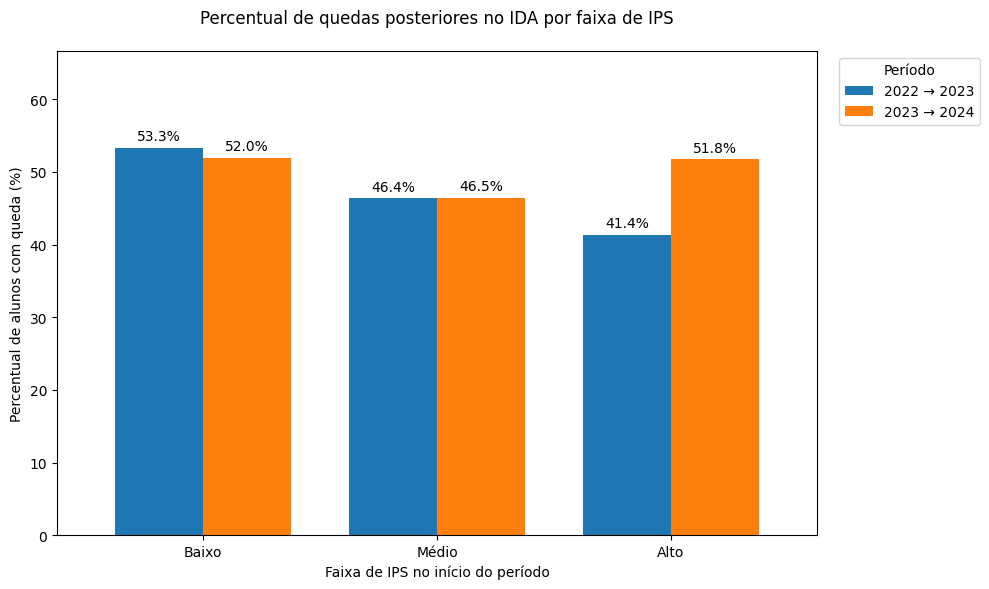

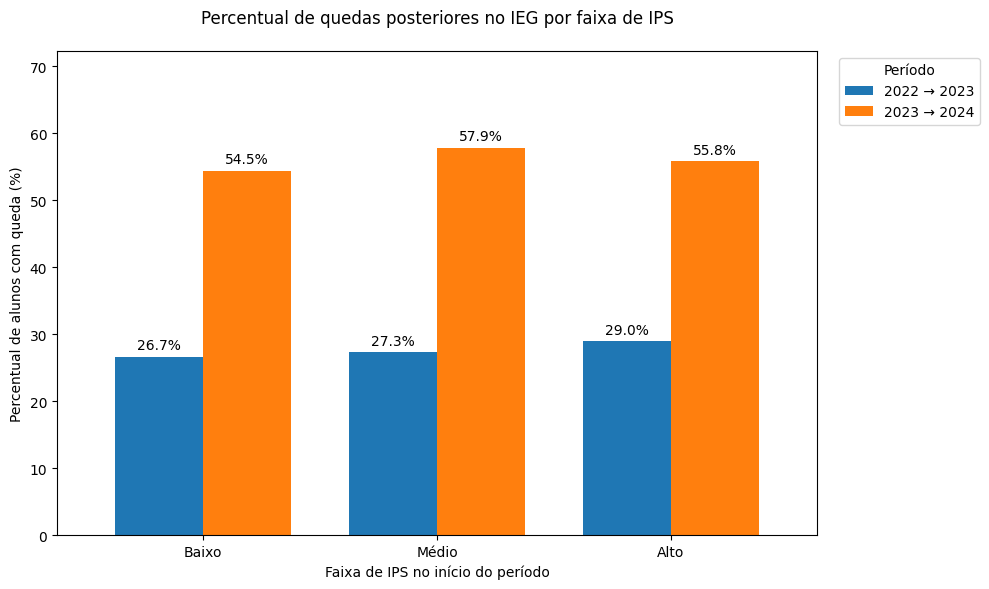

In [285]:
ordem_faixas_ips = [
    "Baixo",
    "Médio",
    "Alto"
]

for indicador in ["IDA", "IEG"]:

    dados_grafico = (
        resumo_faixa_ips[
            resumo_faixa_ips["indicador"] == indicador
        ]
        .pivot(
            index="faixa_ips",
            columns="periodo",
            values="percentual_com_queda"
        )
        .reindex(ordem_faixas_ips)
    )

    ax = dados_grafico.plot(
        kind="bar",
        figsize=(10, 6),
        width=0.75
    )

    plt.title(
        f"Percentual de quedas posteriores no {indicador} por faixa de IPS",
        pad=20
    )

    plt.xlabel("Faixa de IPS no início do período")
    plt.ylabel("Percentual de alunos com queda (%)")
    plt.xticks(rotation=0)

    plt.ylim(
        0,
        dados_grafico.max().max() * 1.25
    )

    plt.legend(
        title="Período",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.1f%%",
            padding=3
        )

    plt.tight_layout()
    plt.show()

### Resposta à Pergunta 5

Os resultados não identificaram um padrão psicossocial consistente, representado pelo IPS, que antecedesse quedas posteriores no desempenho acadêmico ou no engajamento.

Na comparação entre os alunos que apresentaram queda no IDA e aqueles que não apresentaram queda relevante, o IPS inicial foi muito semelhante. Entre 2022 e 2023, as médias foram de 6,82 e 6,91, respectivamente. Entre 2023 e 2024, as médias foram praticamente iguais: 5,15 e 5,16.

O mesmo comportamento foi observado para o IEG. Entre 2022 e 2023, o IPS inicial médio foi de 6,89 entre os alunos que posteriormente apresentaram queda e de 6,86 entre os demais. Entre 2023 e 2024, as médias foram de 5,19 e 5,16.

As correlações temporais também foram muito próximas de zero. A correlação entre o IPS inicial e a variação posterior do IDA foi de 0,06 entre 2022 e 2023 e de 0,05 entre 2023 e 2024. Para o IEG, as correlações foram de -0,01 e 0,01, respectivamente.

A análise por faixas de IPS reforçou essa conclusão. Entre 2023 e 2024, por exemplo, a proporção de queda no IDA foi de 51,96% na faixa baixa, 46,47% na faixa média e 51,75% na faixa alta. Não houve uma progressão consistente entre o nível do IPS e a frequência de quedas.

Para o IEG, as taxas também foram semelhantes entre as faixas. Entre 2023 e 2024, variaram de 54,45% a 57,87%, indicando que o aumento das quedas ocorreu de maneira ampla, e não somente entre alunos com IPS baixo.

No período de 2022 para 2023, a faixa de IPS baixo apresentou maior proporção de queda no IDA. Entretanto, essa faixa continha apenas 15 alunos, tornando o percentual muito sensível a poucos casos e insuficiente para sustentar uma conclusão geral.

Portanto, o IPS isoladamente não se mostrou um bom sinal antecipado de queda futura no IDA ou no IEG. Isso não significa que os aspectos psicossociais não sejam relevantes para o desenvolvimento dos alunos. O resultado indica apenas que, nesta base e considerando avaliações anuais, o IPS sozinho não diferenciou claramente os alunos que posteriormente apresentaram queda.

Em análises futuras e no modelo preditivo, o IPS pode ser utilizado em combinação com outros indicadores, como IEG, IDA, IAA e histórico de defasagem, pois padrões multidimensionais podem ser mais informativos do que um indicador analisado isoladamente.

Foi considerada queda relevante uma redução superior a 0,25 ponto. Esse limite é uma regra operacional adotada para esta análise e não uma classificação oficial da Associação Passos Mágicos.

## 7. Pergunta 6 — Relação entre o IPP e a adequação ao nível

**Pergunta de negócio:** Existe relação entre o indicador psicopedagógico, representado pelo IPP, e a adequação do aluno ao nível educacional, representada pelo IAN?

O IPP representa aspectos psicopedagógicos relacionados ao processo de aprendizagem, enquanto o IAN representa a adequação do aluno à fase educacional esperada.

Como o IPP não possui registros disponíveis em 2022, esta análise considera somente os anos de 2023 e 2024.

Serão avaliados:

- a disponibilidade dos dados;
- as correlações entre IPP e IAN;
- as diferenças entre os anos;
- o IAN médio por faixa de IPP;
- a relação entre IPP e situação de defasagem.

Os resultados representam associações observadas e não permitem afirmar causalidade.

In [287]:
colunas_pergunta_6 = [
    "ipp",
    "ian"
]

for coluna in colunas_pergunta_6:
    df_pede[coluna] = pd.to_numeric(
        df_pede[coluna],
        errors="coerce"
    )

print("Indicadores preparados para análise.")

Indicadores preparados para análise.


In [288]:
dados_ipp_ian = (
    df_pede[
        df_pede["ano"].isin([
            2023,
            2024
        ])
    ][
        [
            "ano",
            "ra",
            "ipp",
            "ian",
            "categoria_defasagem"
        ]
    ]
    .dropna(
        subset=[
            "ipp",
            "ian"
        ]
    )
    .copy()
)

print(
    "Total de registros válidos:",
    len(dados_ipp_ian)
)

print("\nRegistros válidos por ano:")

print(
    dados_ipp_ian["ano"]
    .value_counts()
    .sort_index()
)

Total de registros válidos: 1992

Registros válidos por ano:
ano
2023     938
2024    1054
Name: count, dtype: int64


In [289]:
resumo_ipp_ian_ano = (
    dados_ipp_ian
    .groupby("ano")
    .agg(
        registros_validos=("ra", "count"),
        ipp_medio=("ipp", "mean"),
        ipp_mediano=("ipp", "median"),
        ian_medio=("ian", "mean"),
        ian_mediano=("ian", "median")
    )
    .round(2)
    .reset_index()
)

resumo_ipp_ian_ano

,ano,registros_validos,ipp_medio,ipp_mediano,ian_medio,ian_mediano
0,2023,938,7.56,7.66,7.03,5.00
1,2024,1054,7.55,7.50,7.46,5.00


In [290]:
correlacao_geral_ipp_ian = pd.DataFrame({
    "metodo": [
        "Pearson",
        "Spearman"
    ],
    "correlacao": [
        dados_ipp_ian["ipp"].corr(
            dados_ipp_ian["ian"],
            method="pearson"
        ),
        dados_ipp_ian["ipp"].corr(
            dados_ipp_ian["ian"],
            method="spearman"
        )
    ],
    "quantidade_registros": [
        len(dados_ipp_ian),
        len(dados_ipp_ian)
    ]
})

correlacao_geral_ipp_ian["correlacao"] = (
    correlacao_geral_ipp_ian["correlacao"]
    .round(3)
)

correlacao_geral_ipp_ian

,metodo,correlacao,quantidade_registros
0,Pearson,0.12,1992
1,Spearman,0.13,1992


In [291]:
correlacoes_ipp_ian_ano = []

for ano in [
    2023,
    2024
]:

    dados_ano = dados_ipp_ian[
        dados_ipp_ian["ano"] == ano
    ]

    correlacoes_ipp_ian_ano.append({
        "ano": ano,
        "quantidade": len(dados_ano),

        "correlacao_pearson": (
            dados_ano["ipp"]
            .corr(
                dados_ano["ian"],
                method="pearson"
            )
        ),

        "correlacao_spearman": (
            dados_ano["ipp"]
            .corr(
                dados_ano["ian"],
                method="spearman"
            )
        )
    })

correlacoes_ipp_ian_ano = (
    pd.DataFrame(
        correlacoes_ipp_ian_ano
    )
    .round(3)
)

correlacoes_ipp_ian_ano

,ano,quantidade,correlacao_pearson,correlacao_spearman
0,2023,938,0.10,0.11
1,2024,1054,0.15,0.16


### Interpretação inicial

A relação entre o indicador psicopedagógico e a adequação ao nível foi positiva, porém fraca.

Considerando os 1.992 registros válidos de 2023 e 2024, a correlação de Pearson entre IPP e IAN foi de 0,12, enquanto a correlação de Spearman foi de 0,13.

Em 2023, as correlações foram de 0,10 e 0,11. Em 2024, aumentaram ligeiramente para 0,15 e 0,16, mas permaneceram fracas.

O IPP médio permaneceu praticamente estável entre os anos, passando de 7,56 em 2023 para 7,55 em 2024. No mesmo período, o IAN médio aumentou de 7,03 para 7,46.

Portanto, o aumento da adequação ao nível observado em 2024 não foi acompanhado por uma mudança semelhante no indicador psicopedagógico. Os resultados sugerem que o IPP, isoladamente, possui pouca relação com o IAN.

In [296]:
distribuicao_ian = (
    dados_ipp_ian["ian"]
    .value_counts()
    .sort_index()
    .rename_axis("ian")
    .reset_index(name="quantidade")
)

distribuicao_ian["percentual"] = (
    distribuicao_ian["quantidade"]
    / distribuicao_ian["quantidade"].sum()
    * 100
).round(2)

distribuicao_ian

,ian,quantidade,percentual
0,2.50,17,0.85
1,5.00,1067,53.56
2,10.00,908,45.58


In [297]:
resumo_ipp_por_ian = (
    dados_ipp_ian
    .groupby("ian")
    .agg(
        quantidade=("ipp", "count"),
        ipp_medio=("ipp", "mean"),
        ipp_mediano=("ipp", "median"),
        desvio_padrao_ipp=("ipp", "std")
    )
    .round(2)
    .reset_index()
)

resumo_ipp_por_ian

,ian,quantidade,ipp_medio,ipp_mediano,desvio_padrao_ipp
0,2.50,17,7.01,7.50,1.13
1,5.00,1067,7.46,7.50,0.96
2,10.00,908,7.68,7.71,0.89


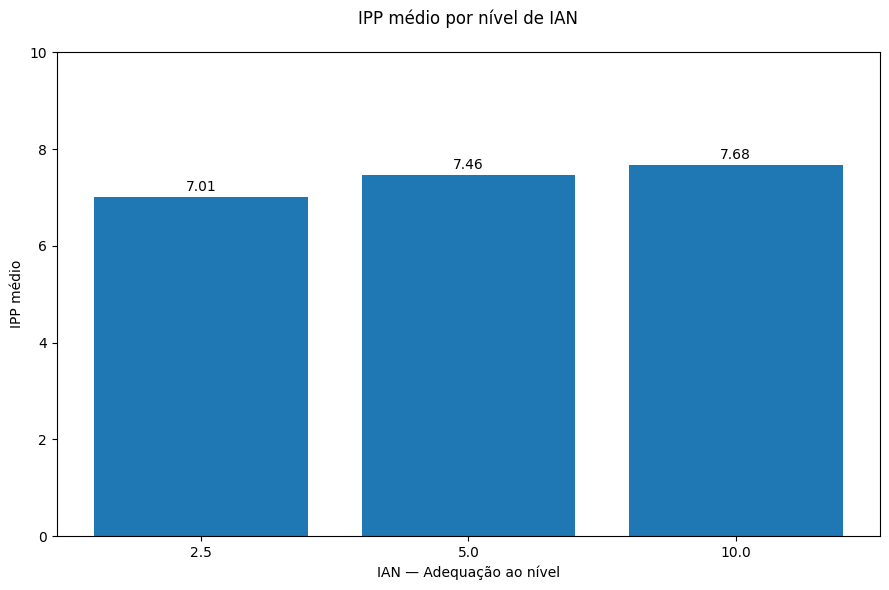

In [298]:
plt.figure(figsize=(9, 6))

barras = plt.bar(
    resumo_ipp_por_ian["ian"].astype(str),
    resumo_ipp_por_ian["ipp_medio"]
)

plt.title(
    "IPP médio por nível de IAN",
    pad=20
)

plt.xlabel("IAN — Adequação ao nível")
plt.ylabel("IPP médio")
plt.ylim(0, 10)

for barra, valor in zip(
    barras,
    resumo_ipp_por_ian["ipp_medio"]
):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 0.12,
        f"{valor:.2f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

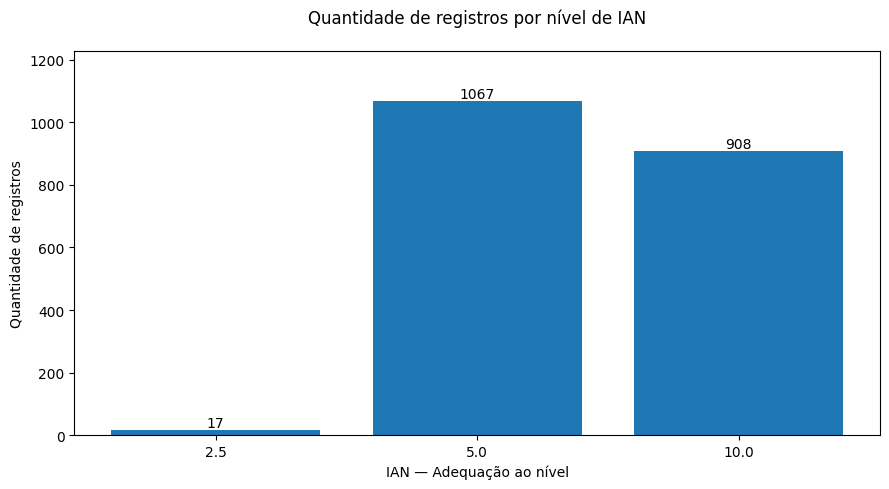

In [299]:
plt.figure(figsize=(9, 5))

barras = plt.bar(
    resumo_ipp_por_ian["ian"].astype(str),
    resumo_ipp_por_ian["quantidade"]
)

plt.title(
    "Quantidade de registros por nível de IAN",
    pad=20
)

plt.xlabel("IAN — Adequação ao nível")
plt.ylabel("Quantidade de registros")

for barra, quantidade in zip(
    barras,
    resumo_ipp_por_ian["quantidade"]
):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        quantidade + 10,
        str(int(quantidade)),
        ha="center"
    )

plt.ylim(
    0,
    resumo_ipp_por_ian["quantidade"].max() * 1.15
)

plt.tight_layout()
plt.show()

### Interpretação por nível de IAN

O IPP médio apresentou crescimento conforme aumentou o nível de IAN.

Os alunos com IAN igual a 2,5 apresentaram IPP médio de 7,01. Nos registros com IAN igual a 5,0, o IPP médio foi de 7,46, enquanto entre aqueles com IAN igual a 10,0 a média alcançou 7,68.

Apesar dessa progressão, as diferenças foram pequenas, especialmente entre os níveis 5,0 e 10,0, cuja distância foi de apenas 0,22 ponto.

Também é necessário interpretar o nível 2,5 com cautela, pois ele possui somente 17 registros, enquanto os níveis 5,0 e 10,0 possuem 1.067 e 908 registros, respectivamente.

Portanto, os resultados indicam uma leve tendência de IPP mais alto entre alunos com maior adequação ao nível, mas não uma separação forte entre os grupos.

### 7.1 IPP por categoria de defasagem

Para complementar a análise do IAN, o IPP será comparado com as categorias de defasagem criadas anteriormente.

Essa comparação permite verificar se alunos com defasagem moderada ou severa apresentam resultados psicopedagógicos diferentes daqueles que estão na fase ideal ou acima dela.

In [300]:
ordem_categorias_ipp = [
    "Acima do esperado",
    "Sem defasagem",
    "Defasagem moderada",
    "Defasagem severa"
]

resumo_ipp_defasagem = (
    dados_ipp_ian[
        dados_ipp_ian["categoria_defasagem"].isin(
            ordem_categorias_ipp
        )
    ]
    .groupby(
        "categoria_defasagem",
        observed=False
    )
    .agg(
        quantidade=("ipp", "count"),
        ipp_medio=("ipp", "mean"),
        ipp_mediano=("ipp", "median"),
        desvio_padrao=("ipp", "std")
    )
    .reindex(ordem_categorias_ipp)
    .round(2)
    .reset_index()
)

resumo_ipp_defasagem

,categoria_defasagem,quantidade,ipp_medio,ipp_mediano,desvio_padrao
0,Acima do esperado,128,7.93,7.98,0.75
1,Sem defasagem,780,7.64,7.71,0.91
2,Defasagem moderada,847,7.55,7.50,0.93
3,Defasagem severa,237,7.11,7.29,1.03


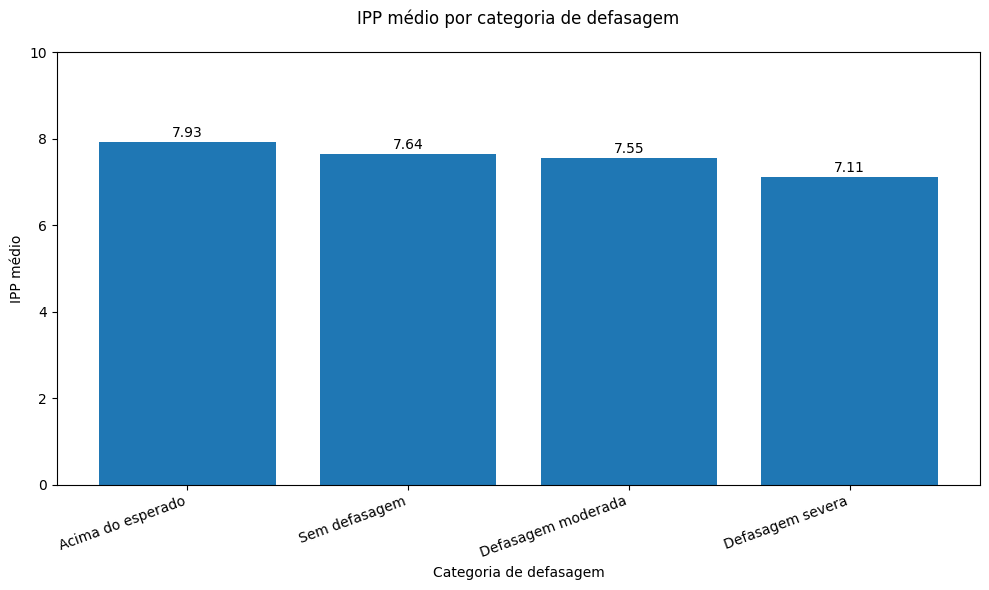

In [301]:
plt.figure(figsize=(10, 6))

barras = plt.bar(
    resumo_ipp_defasagem[
        "categoria_defasagem"
    ].astype(str),
    resumo_ipp_defasagem["ipp_medio"]
)

plt.title(
    "IPP médio por categoria de defasagem",
    pad=20
)

plt.xlabel("Categoria de defasagem")
plt.ylabel("IPP médio")
plt.ylim(0, 10)

plt.xticks(
    rotation=20,
    ha="right"
)

for barra, valor in zip(
    barras,
    resumo_ipp_defasagem["ipp_medio"]
):
    if pd.notna(valor):
        plt.text(
            barra.get_x() + barra.get_width() / 2,
            valor + 0.12,
            f"{valor:.2f}",
            ha="center"
        )

plt.tight_layout()
plt.show()

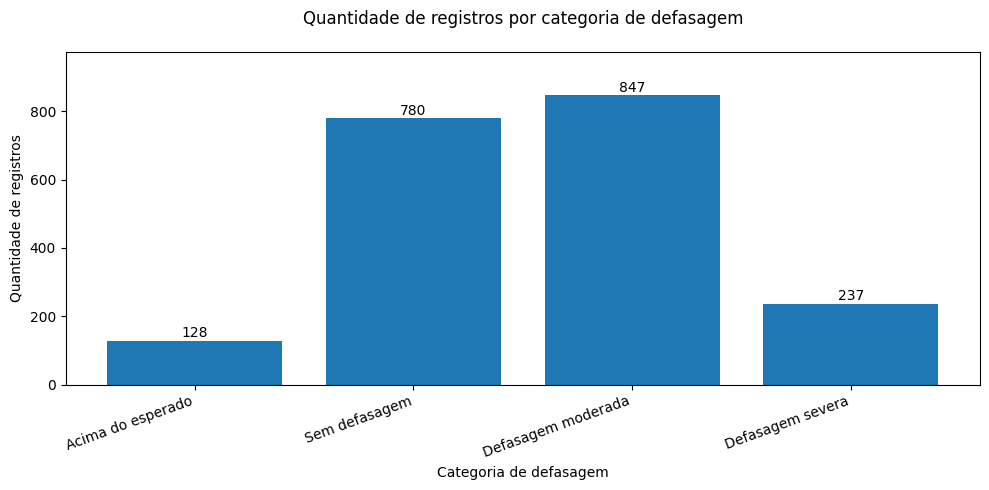

In [302]:
plt.figure(figsize=(10, 5))

barras = plt.bar(
    resumo_ipp_defasagem[
        "categoria_defasagem"
    ].astype(str),
    resumo_ipp_defasagem["quantidade"]
)

plt.title(
    "Quantidade de registros por categoria de defasagem",
    pad=20
)

plt.xlabel("Categoria de defasagem")
plt.ylabel("Quantidade de registros")

plt.xticks(
    rotation=20,
    ha="right"
)

for barra, quantidade in zip(
    barras,
    resumo_ipp_defasagem["quantidade"]
):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        quantidade + 10,
        str(int(quantidade)),
        ha="center"
    )

plt.ylim(
    0,
    resumo_ipp_defasagem["quantidade"].max() * 1.15
)

plt.tight_layout()
plt.show()

### Interpretação por categoria de defasagem

O IPP médio apresentou redução conforme aumentou a gravidade da defasagem.

Os alunos acima da fase esperada apresentaram IPP médio de 7,93. Entre os alunos sem defasagem, a média foi de 7,64, enquanto aqueles com defasagem moderada apresentaram média de 7,55.

O menor resultado foi observado entre os alunos com defasagem severa, cujo IPP médio foi de 7,11.

A diferença entre os grupos acima do esperado e com defasagem severa foi de 0,82 ponto. Entretanto, a diferença entre alunos sem defasagem e com defasagem moderada foi de somente 0,09 ponto.

O grupo com defasagem severa também apresentou maior dispersão, com desvio-padrão de 1,03. Isso indica que os resultados psicopedagógicos são mais variados dentro desse grupo.

Portanto, existe uma tendência de IPP mais baixo entre alunos com maior defasagem, mas as diferenças entre alguns grupos são pequenas e não representam uma separação forte.

### Resposta à Pergunta 6

Os resultados indicam uma relação positiva, porém fraca, entre o indicador psicopedagógico, representado pelo IPP, e a adequação ao nível, representada pelo IAN.

Como o IPP não possui dados disponíveis em 2022, a análise foi realizada somente com os registros de 2023 e 2024. Foram utilizados 1.992 registros válidos.

Na análise geral, a correlação de Pearson entre IPP e IAN foi de 0,12, enquanto a correlação de Spearman foi de 0,13. Esses valores indicam uma associação positiva, mas de baixa intensidade.

Em 2023, as correlações de Pearson e Spearman foram de 0,10 e 0,11. Em 2024, aumentaram ligeiramente para 0,15 e 0,16, mas permaneceram fracas.

O IPP médio praticamente não mudou entre os anos, passando de 7,56 em 2023 para 7,55 em 2024. No mesmo período, o IAN médio aumentou de 7,03 para 7,46. Dessa forma, a melhora observada no IAN não foi acompanhada por uma mudança equivalente no IPP.

A comparação por nível de IAN mostrou uma pequena progressão. Os registros com IAN igual a 2,5 apresentaram IPP médio de 7,01. Nos níveis de IAN iguais a 5,0 e 10,0, as médias foram de 7,46 e 7,68, respectivamente.

O grupo com IAN igual a 2,5 possuía somente 17 registros, enquanto os níveis 5,0 e 10,0 possuíam 1.067 e 908 registros. Portanto, o resultado do menor nível deve ser interpretado com cautela.

A análise por categoria de defasagem reforçou a mesma tendência. O IPP médio foi de 7,93 entre os alunos acima da fase esperada, 7,64 entre aqueles sem defasagem, 7,55 entre os alunos com defasagem moderada e 7,11 entre aqueles com defasagem severa.

Embora os alunos com defasagem severa tenham apresentado o menor IPP médio, as diferenças entre os demais grupos foram pequenas. Entre alunos sem defasagem e com defasagem moderada, por exemplo, a diferença foi de apenas 0,09 ponto.

Portanto, o IPP possui alguma associação com a adequação ao nível, especialmente quando são comparados os grupos extremos. Entretanto, essa relação é fraca, e o IPP isoladamente não explica adequadamente o IAN ou a situação de defasagem.

De forma gerencial, os alunos que combinam defasagem severa com IPP baixo podem ser considerados prioritários para acompanhamento psicopedagógico. Porém, essa priorização deve considerar também outros indicadores acadêmicos, de engajamento e psicossociais.

Os resultados representam associações observadas nos anos de 2023 e 2024 e não permitem afirmar que um IPP mais alto cause diretamente uma melhora na adequação ao nível.

## 8. Pergunta 7 — Fatores associados ao IPV ao longo do tempo

**Pergunta de negócio:** Quais fatores parecem estar mais associados ao desenvolvimento do IPV ao longo dos anos?

O IPV representa o ponto de virada observado no desenvolvimento do aluno.

Nesta seção, será analisada sua relação com os seguintes indicadores:

- IAN — adequação ao nível;
- IDA — desempenho acadêmico;
- IEG — engajamento;
- IAA — autoavaliação;
- IPS — aspectos psicossociais;
- IPP — aspectos psicopedagógicos.

O INDE não será utilizado como fator explicativo, pois ele é composto pelos próprios indicadores e sua inclusão produziria uma relação circular.

A análise será dividida em duas partes:

1. associação entre o IPV e os demais indicadores em cada ano;
2. análise longitudinal, acompanhando a evolução dos mesmos alunos entre anos consecutivos.

Os resultados representam associações observadas e não permitem afirmar causalidade.

In [303]:
indicadores_pergunta_7 = [
    "ipv",
    "ian",
    "ida",
    "ieg",
    "iaa",
    "ips",
    "ipp"
]

for indicador in indicadores_pergunta_7:
    df_pede[indicador] = pd.to_numeric(
        df_pede[indicador],
        errors="coerce"
    )

print("Indicadores preparados para análise.")

Indicadores preparados para análise.


In [304]:
fatores_ipv = [
    "ian",
    "ida",
    "ieg",
    "iaa",
    "ips",
    "ipp"
]

correlacoes_ipv_gerais = []

for fator in fatores_ipv:

    dados_validos = (
        df_pede[
            ["ipv", fator]
        ]
        .dropna()
    )

    correlacoes_ipv_gerais.append({
        "fator": fator.upper(),
        "quantidade_registros": len(dados_validos),
        "correlacao_pearson": (
            dados_validos["ipv"]
            .corr(
                dados_validos[fator],
                method="pearson"
            )
        ),
        "correlacao_spearman": (
            dados_validos["ipv"]
            .corr(
                dados_validos[fator],
                method="spearman"
            )
        )
    })

correlacoes_ipv_gerais = (
    pd.DataFrame(correlacoes_ipv_gerais)
    .round(3)
    .sort_values(
        "correlacao_pearson",
        ascending=False
    )
    .reset_index(drop=True)
)

correlacoes_ipv_gerais

,fator,quantidade_registros,correlacao_pearson,correlacao_spearman
0,IPP,1992,0.61,0.60
1,IEG,2852,0.56,0.55
2,IDA,2851,0.56,0.56
3,IAN,2852,0.15,0.16
4,IAA,2852,0.06,0.12
5,IPS,2846,-0.05,0.02


In [305]:
correlacoes_ipv_ano = []

for ano in sorted(df_pede["ano"].unique()):

    dados_ano = df_pede[
        df_pede["ano"] == ano
    ]

    for fator in fatores_ipv:

        dados_validos = (
            dados_ano[
                ["ipv", fator]
            ]
            .dropna()
        )

        if len(dados_validos) >= 2:
            correlacao = (
                dados_validos["ipv"]
                .corr(dados_validos[fator])
            )
        else:
            correlacao = np.nan

        correlacoes_ipv_ano.append({
            "ano": ano,
            "fator": fator.upper(),
            "quantidade": len(dados_validos),
            "correlacao": correlacao
        })

correlacoes_ipv_ano = (
    pd.DataFrame(correlacoes_ipv_ano)
    .round(3)
)

tabela_correlacoes_ipv_ano = (
    correlacoes_ipv_ano
    .pivot(
        index="fator",
        columns="ano",
        values="correlacao"
    )
    .reindex(
        [
            "IAN",
            "IDA",
            "IEG",
            "IAA",
            "IPS",
            "IPP"
        ]
    )
)

tabela_correlacoes_ipv_ano

ano,2022,2023,2024
fator,,,
IAN,0.11,0.15,0.18
IDA,0.62,0.54,0.51
IEG,0.59,0.45,0.54
IAA,0.26,0.14,0.15
IPS,0.21,0.08,0.10
IPP,NaN,0.52,0.75


### 8.1 Associação geral entre os indicadores e o IPV

As correlações permitem comparar quais indicadores apresentam maior associação linear com o IPV.

Valores positivos indicam que resultados mais altos no indicador tendem a acompanhar valores mais altos de IPV. Valores próximos de zero indicam pouca associação linear.

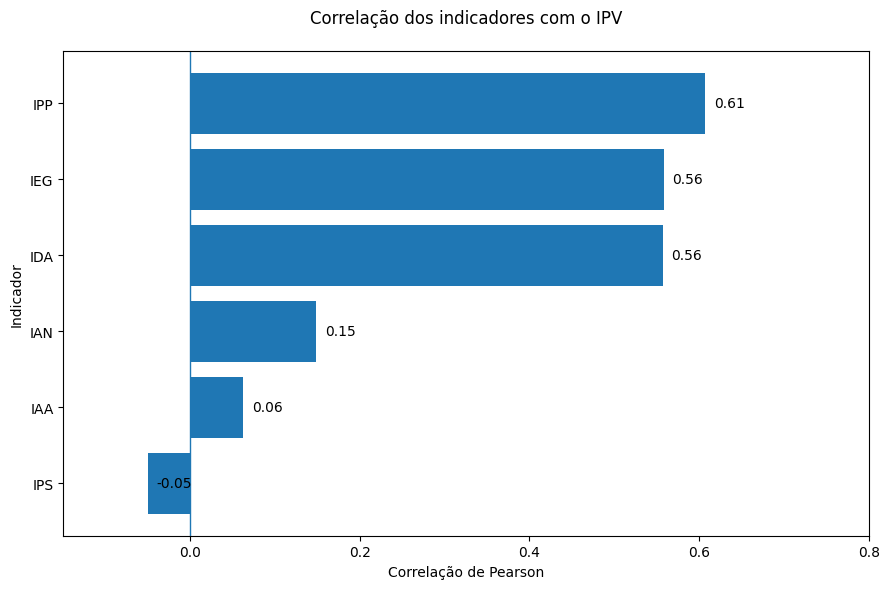

In [306]:
dados_grafico_ipv = (
    correlacoes_ipv_gerais
    .sort_values(
        "correlacao_pearson",
        ascending=True
    )
)

plt.figure(figsize=(9, 6))

barras = plt.barh(
    dados_grafico_ipv["fator"],
    dados_grafico_ipv["correlacao_pearson"]
)

plt.title(
    "Correlação dos indicadores com o IPV",
    pad=20
)

plt.xlabel("Correlação de Pearson")
plt.ylabel("Indicador")

plt.axvline(
    x=0,
    linewidth=1
)

for barra, valor in zip(
    barras,
    dados_grafico_ipv["correlacao_pearson"]
):
    plt.text(
        valor + 0.01,
        barra.get_y() + barra.get_height() / 2,
        f"{valor:.2f}",
        va="center"
    )

plt.xlim(
    min(-0.1, dados_grafico_ipv["correlacao_pearson"].min() - 0.1),
    max(0.8, dados_grafico_ipv["correlacao_pearson"].max() + 0.1)
)

plt.tight_layout()
plt.show()

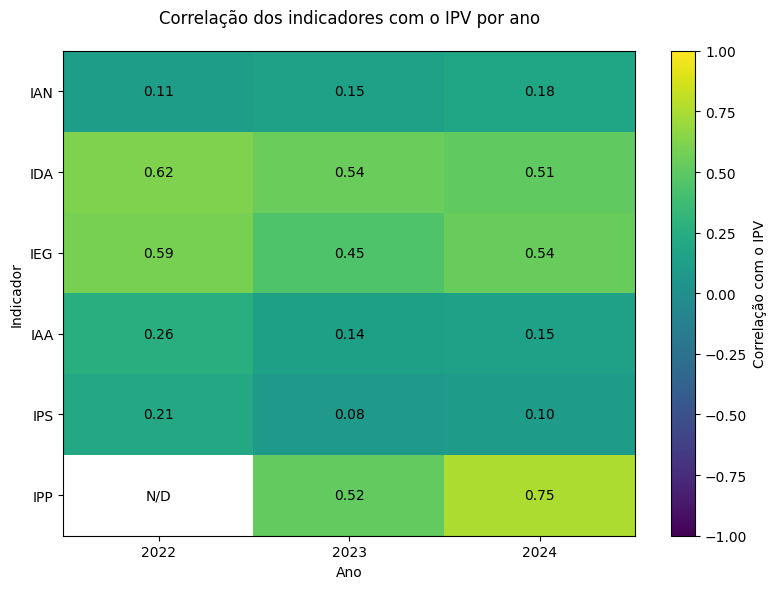

In [307]:
valores_mapa_ipv = np.ma.masked_invalid(
    tabela_correlacoes_ipv_ano.values
)

plt.figure(figsize=(8, 6))

imagem = plt.imshow(
    valores_mapa_ipv,
    aspect="auto",
    vmin=-1,
    vmax=1
)

plt.colorbar(
    imagem,
    label="Correlação com o IPV"
)

plt.xticks(
    range(len(tabela_correlacoes_ipv_ano.columns)),
    tabela_correlacoes_ipv_ano.columns
)

plt.yticks(
    range(len(tabela_correlacoes_ipv_ano.index)),
    tabela_correlacoes_ipv_ano.index
)

plt.title(
    "Correlação dos indicadores com o IPV por ano",
    pad=20
)

plt.xlabel("Ano")
plt.ylabel("Indicador")

for linha in range(tabela_correlacoes_ipv_ano.shape[0]):
    for coluna in range(tabela_correlacoes_ipv_ano.shape[1]):

        valor = tabela_correlacoes_ipv_ano.iloc[
            linha,
            coluna
        ]

        texto = (
            f"{valor:.2f}"
            if pd.notna(valor)
            else "N/D"
        )

        plt.text(
            coluna,
            linha,
            texto,
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

### Interpretação inicial

Os indicadores com maior associação geral com o IPV foram o IPP, o IEG e o IDA.

O IPP apresentou correlação de Pearson igual a 0,61 e correlação de Spearman igual a 0,60. Entretanto, esse indicador possui dados apenas em 2023 e 2024, totalizando 1.992 registros válidos.

O IEG e o IDA apresentaram correlações de Pearson iguais a 0,56. Essas relações foram positivas e moderadas, indicando que maiores níveis de engajamento e desempenho acadêmico tendem a acompanhar valores mais elevados de IPV.

O IDA apresentou comportamento relativamente consistente entre os anos, com correlações de 0,62 em 2022, 0,54 em 2023 e 0,51 em 2024.

O IEG também manteve associação moderada, com valores de 0,59, 0,45 e 0,54, respectivamente.

O IPP apresentou correlação de 0,52 em 2023 e 0,75 em 2024. Portanto, sua associação com o IPV se tornou especialmente elevada no último ano analisado.

As relações do IPV com o IAN, o IAA e o IPS foram fracas. O IPS apresentou associação praticamente nula no conjunto completo.

Esses resultados indicam que as dimensões psicopedagógica, acadêmica e de engajamento estão mais relacionadas ao IPV do que a autoavaliação, a adequação ao nível e o indicador psicossocial.

Entretanto, as correlações representam associações observadas no mesmo ano e não demonstram causalidade.

### 8.2 Evolução longitudinal dos fatores e do IPV

Para complementar a análise transversal, serão acompanhados somente os alunos presentes em anos consecutivos.

Será verificado se a variação de cada indicador acompanha a variação do IPV nos períodos:

- 2022 para 2023;
- 2023 para 2024.

Uma correlação positiva significa que aumentos no indicador tendem a acompanhar aumentos no IPV. Uma correlação próxima de zero indica pouca associação entre as mudanças.

Como o IPP não possui dados em 2022, sua análise longitudinal será possível somente entre 2023 e 2024.

In [308]:
def analisar_variacao_com_ipv(
    dados,
    fator,
    ano_inicial,
    ano_final
):
    dados_iniciais = (
        dados[dados["ano"] == ano_inicial][
            ["ra", "ipv", fator]
        ]
        .rename(
            columns={
                "ipv": "ipv_inicial",
                fator: "fator_inicial"
            }
        )
    )

    dados_finais = (
        dados[dados["ano"] == ano_final][
            ["ra", "ipv", fator]
        ]
        .rename(
            columns={
                "ipv": "ipv_final",
                fator: "fator_final"
            }
        )
    )

    comparacao = dados_iniciais.merge(
        dados_finais,
        on="ra",
        how="inner"
    )

    comparacao = comparacao.dropna(
        subset=[
            "ipv_inicial",
            "ipv_final",
            "fator_inicial",
            "fator_final"
        ]
    ).copy()

    comparacao["variacao_ipv"] = (
        comparacao["ipv_final"]
        - comparacao["ipv_inicial"]
    )

    comparacao["variacao_fator"] = (
        comparacao["fator_final"]
        - comparacao["fator_inicial"]
    )

    return {
        "fator": fator.upper(),
        "periodo": f"{ano_inicial} → {ano_final}",
        "quantidade": len(comparacao),
        "correlacao_variacoes": (
            comparacao["variacao_fator"]
            .corr(comparacao["variacao_ipv"])
        )
    }

In [309]:
resultados_variacao_ipv = []

for fator in fatores_ipv:

    resultados_variacao_ipv.append(
        analisar_variacao_com_ipv(
            df_pede,
            fator,
            2022,
            2023
        )
    )

    resultados_variacao_ipv.append(
        analisar_variacao_com_ipv(
            df_pede,
            fator,
            2023,
            2024
        )
    )

correlacoes_variacoes_ipv = (
    pd.DataFrame(
        resultados_variacao_ipv
    )
)

# Remove comparações sem registros suficientes
correlacoes_variacoes_ipv = (
    correlacoes_variacoes_ipv[
        correlacoes_variacoes_ipv["quantidade"] >= 3
    ]
    .copy()
)

correlacoes_variacoes_ipv[
    "correlacao_variacoes"
] = (
    correlacoes_variacoes_ipv[
        "correlacao_variacoes"
    ]
    .round(3)
)

correlacoes_variacoes_ipv

,fator,periodo,quantidade,correlacao_variacoes
0,IAN,2022 → 2023,574,-0.18
1,IAN,2023 → 2024,681,-0.18
2,IDA,2022 → 2023,574,0.34
3,IDA,2023 → 2024,681,0.38
4,IEG,2022 → 2023,574,0.26
5,IEG,2023 → 2024,681,0.30
6,IAA,2022 → 2023,574,0.06
7,IAA,2023 → 2024,681,-0.06
8,IPS,2022 → 2023,570,0.07
9,IPS,2023 → 2024,678,-0.06


In [310]:
tabela_variacoes_ipv = (
    correlacoes_variacoes_ipv
    .pivot(
        index="fator",
        columns="periodo",
        values="correlacao_variacoes"
    )
    .reindex([
        "IAN",
        "IDA",
        "IEG",
        "IAA",
        "IPS",
        "IPP"
    ])
)

tabela_variacoes_ipv

periodo,2022 → 2023,2023 → 2024
fator,,
IAN,-0.18,-0.18
IDA,0.34,0.38
IEG,0.26,0.30
IAA,0.06,-0.06
IPS,0.07,-0.06
IPP,NaN,0.38


### Interpretação longitudinal

A análise longitudinal mostrou que as mudanças no IDA, no IEG e no IPP foram as que mais acompanharam as mudanças no IPV.

O IDA apresentou correlação de 0,34 entre 2022 e 2023 e de 0,38 entre 2023 e 2024. Dessa forma, alunos que melhoraram seu desempenho acadêmico também apresentaram alguma tendência de melhora no IPV.

O IEG apresentou correlações de 0,26 e 0,30. Embora mais fracas que as do IDA, essas relações foram positivas nos dois períodos, indicando consistência entre a evolução do engajamento e a evolução do ponto de virada.

O IPP apresentou correlação de 0,38 entre 2023 e 2024. Como não existem dados de IPP em 2022, não foi possível analisar sua evolução no primeiro período.

As variações do IAA e do IPS apresentaram correlações próximas de zero, indicando que suas mudanças não acompanharam claramente a evolução do IPV.

O IAN apresentou correlação negativa fraca de -0,18 nos dois períodos. Esse resultado não deve ser interpretado como efeito negativo da adequação ao nível. O IAN possui poucos valores possíveis e está diretamente relacionado à defasagem, o que limita a sensibilidade de sua variação.

Portanto, o desempenho acadêmico foi o fator longitudinal mais consistente, seguido pelo engajamento e pelo indicador psicopedagógico.

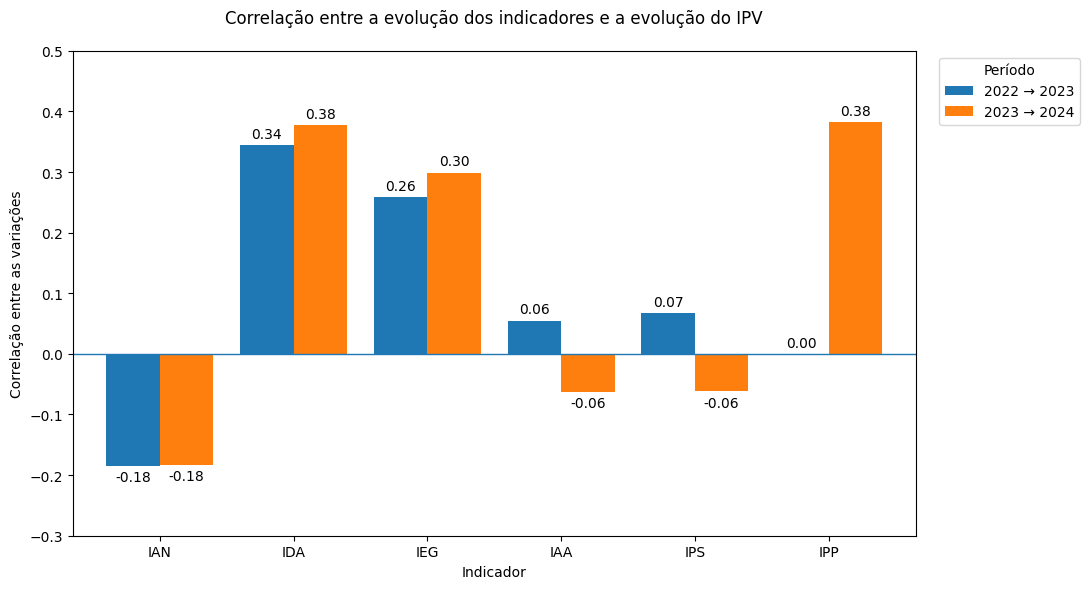

In [311]:
ax = tabela_variacoes_ipv.plot(
    kind="bar",
    figsize=(11, 6),
    width=0.8
)

plt.axhline(
    y=0,
    linewidth=1
)

plt.title(
    "Correlação entre a evolução dos indicadores e a evolução do IPV",
    pad=20
)

plt.xlabel("Indicador")
plt.ylabel("Correlação entre as variações")
plt.xticks(rotation=0)

plt.legend(
    title="Período",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3
    )

plt.ylim(-0.30, 0.50)

plt.tight_layout()
plt.show()

### Resposta à Pergunta 7

Os fatores mais associados ao IPV foram o IPP, o IDA e o IEG.

Na análise dos indicadores observados no mesmo ano, o IPP apresentou a maior correlação geral com o IPV, com coeficiente de Pearson igual a 0,61. Entretanto, o IPP possui dados somente em 2023 e 2024.

O IDA e o IEG apresentaram correlações gerais de 0,56 com o IPV. Essas relações foram positivas e moderadas, indicando que alunos com melhor desempenho acadêmico e maior engajamento tenderam a apresentar valores mais elevados de IPV.

O IDA apresentou associação relativamente consistente ao longo dos anos, com correlações de 0,62 em 2022, 0,54 em 2023 e 0,51 em 2024.

O IEG também apresentou associação moderada nos três anos, com correlações de 0,59, 0,45 e 0,54, respectivamente.

O IPP apresentou correlação de 0,52 em 2023 e de 0,75 em 2024, tornando-se o indicador mais associado ao IPV no último ano.

Na análise longitudinal, que acompanha os mesmos alunos, o IDA foi o fator mais consistente. A correlação entre a variação do IDA e a variação do IPV foi de 0,34 entre 2022 e 2023 e de 0,38 entre 2023 e 2024.

O IEG apresentou correlações longitudinais de 0,26 e 0,30. O IPP apresentou correlação de 0,38 entre 2023 e 2024, único período em que foi possível avaliar sua evolução.

As mudanças no IAA e no IPS apresentaram correlações próximas de zero com a mudança do IPV. Portanto, esses indicadores não demonstraram relação longitudinal clara com a evolução do ponto de virada.

O IAN apresentou correlação longitudinal negativa fraca de -0,18 nos dois períodos. Esse resultado não indica causalidade negativa, mas apenas que as mudanças do IAN e do IPV não caminharam juntas de maneira positiva nesta base.

Portanto, os resultados sugerem que o desenvolvimento do IPV está mais relacionado às dimensões acadêmica, de engajamento e psicopedagógica. O IDA se destacou pela consistência entre os anos, enquanto o IPP apresentou a maior associação no ano de 2024.

De forma gerencial, o acompanhamento conjunto de IDA, IEG e IPP pode ajudar a identificar alunos com maior ou menor evolução no IPV. Entretanto, esses indicadores devem ser utilizados em conjunto e não como explicações causais isoladas.

As análises mostram associações estatísticas e não permitem afirmar que melhorias nesses indicadores causem diretamente o aumento do IPV.

## 9. Pergunta 8 — Combinações multidimensionais associadas ao INDE

**Pergunta de negócio:** Quais combinações de IDA, IEG, IPS e IPP estão associadas aos maiores valores de INDE?

O INDE representa a nota global de desenvolvimento educacional do aluno e é formado pela ponderação de diferentes indicadores.

Como o IPP não está disponível em 2022, a análise conjunta dos quatro indicadores será realizada somente com dados de 2023 e 2024.

Para permitir a comparação entre indicadores e anos, cada indicador será classificado como:

- **Alto:** valor igual ou superior à mediana do próprio ano;
- **Baixo:** valor inferior à mediana do próprio ano.

Essa classificação é relativa à distribuição de cada ano e foi criada exclusivamente para esta análise.

Os resultados representam associações esperadas com uma métrica composta e não permitem afirmar causalidade.

In [312]:
indicadores_multidimensionais = [
    "ida",
    "ieg",
    "ips",
    "ipp"
]

colunas_multidimensionais = [
    "ano",
    "inde",
    "ida",
    "ieg",
    "ips",
    "ipp"
]

for coluna in colunas_multidimensionais[1:]:
    df_pede[coluna] = pd.to_numeric(
        df_pede[coluna],
        errors="coerce"
    )

dados_multidimensionais = (
    df_pede[
        df_pede["ano"].isin([
            2023,
            2024
        ])
    ][colunas_multidimensionais]
    .dropna(
        subset=colunas_multidimensionais[1:]
    )
    .copy()
)

print(
    "Registros completos utilizados:",
    len(dados_multidimensionais)
)

print("\nRegistros por ano:")

print(
    dados_multidimensionais["ano"]
    .value_counts()
    .sort_index()
)

Registros completos utilizados: 1985

Registros por ano:
ano
2023     931
2024    1054
Name: count, dtype: int64


In [313]:
medianas_indicadores_ano = (
    dados_multidimensionais
    .groupby("ano")[
        indicadores_multidimensionais
    ]
    .median()
    .round(2)
)

medianas_indicadores_ano

,ida,ieg,ips,ipp
ano,,,,
2023,6.80,9.00,5.00,7.66
2024,6.75,8.59,7.51,7.50


In [314]:
for indicador in indicadores_multidimensionais:

    mediana_do_ano = (
        dados_multidimensionais
        .groupby("ano")[indicador]
        .transform("median")
    )

    dados_multidimensionais[
        f"{indicador}_nivel"
    ] = np.where(
        dados_multidimensionais[indicador]
        >= mediana_do_ano,
        "Alto",
        "Baixo"
    )

    dados_multidimensionais[
        f"{indicador}_alto"
    ] = (
        dados_multidimensionais[indicador]
        >= mediana_do_ano
    ).astype(int)


dados_multidimensionais[
    "quantidade_indicadores_altos"
] = (
    dados_multidimensionais["ida_alto"]
    + dados_multidimensionais["ieg_alto"]
    + dados_multidimensionais["ips_alto"]
    + dados_multidimensionais["ipp_alto"]
)

print("Classificações criadas.")

Classificações criadas.


In [315]:
resumo_quantidade_altos = (
    dados_multidimensionais
    .groupby(
        "quantidade_indicadores_altos"
    )
    .agg(
        quantidade_registros=("inde", "count"),
        inde_medio=("inde", "mean"),
        inde_mediano=("inde", "median"),
        inde_minimo=("inde", "min"),
        inde_maximo=("inde", "max")
    )
    .round(2)
    .reset_index()
)

resumo_quantidade_altos

,quantidade_indicadores_altos,quantidade_registros,inde_medio,inde_mediano,inde_minimo,inde_maximo
0,0,180,6.06,6.05,3.75,7.54
1,1,426,6.59,6.67,4.41,7.96
2,2,509,7.24,7.30,4.55,8.85
3,3,570,7.98,8.00,5.95,9.53
4,4,300,8.33,8.33,6.47,9.50


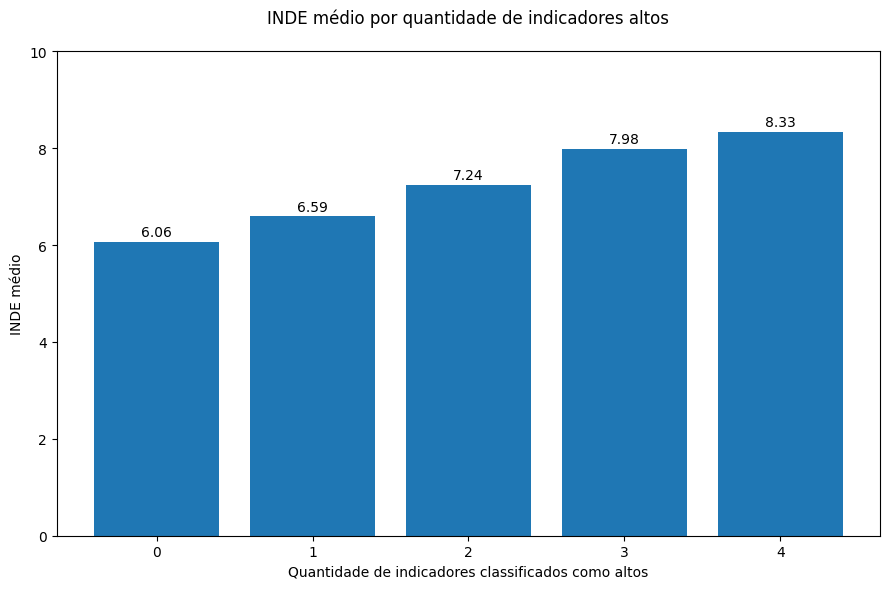

In [316]:
plt.figure(figsize=(9, 6))

barras = plt.bar(
    resumo_quantidade_altos[
        "quantidade_indicadores_altos"
    ].astype(str),
    resumo_quantidade_altos[
        "inde_medio"
    ]
)

plt.title(
    "INDE médio por quantidade de indicadores altos",
    pad=20
)

plt.xlabel(
    "Quantidade de indicadores classificados como altos"
)

plt.ylabel("INDE médio")
plt.ylim(0, 10)

for barra, valor in zip(
    barras,
    resumo_quantidade_altos["inde_medio"]
):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 0.12,
        f"{valor:.2f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

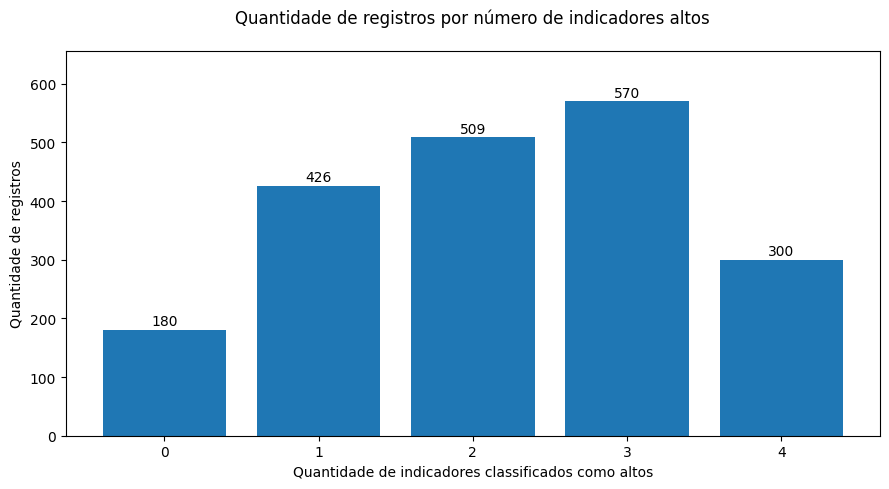

In [317]:
plt.figure(figsize=(9, 5))

barras = plt.bar(
    resumo_quantidade_altos[
        "quantidade_indicadores_altos"
    ].astype(str),
    resumo_quantidade_altos[
        "quantidade_registros"
    ]
)

plt.title(
    "Quantidade de registros por número de indicadores altos",
    pad=20
)

plt.xlabel(
    "Quantidade de indicadores classificados como altos"
)

plt.ylabel("Quantidade de registros")

for barra, quantidade in zip(
    barras,
    resumo_quantidade_altos[
        "quantidade_registros"
    ]
):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        quantidade + 8,
        str(int(quantidade)),
        ha="center"
    )

plt.ylim(
    0,
    resumo_quantidade_altos[
        "quantidade_registros"
    ].max() * 1.15
)

plt.tight_layout()
plt.show()

### Interpretação da quantidade de indicadores altos

O INDE médio aumentou de forma progressiva conforme cresceu o número de indicadores classificados como altos.

Os registros sem nenhum indicador alto apresentaram INDE médio de 6,06. Com um indicador alto, a média aumentou para 6,59; com dois, chegou a 7,24; e com três, alcançou 7,98.

O maior resultado foi observado entre os alunos com os quatro indicadores altos, cujo INDE médio foi de 8,33.

A diferença entre os grupos com zero e quatro indicadores altos foi de 2,27 pontos. Isso mostra que resultados favoráveis simultâneos nas dimensões acadêmica, de engajamento, psicossocial e psicopedagógica estão associados a um desenvolvimento global mais elevado.

Entretanto, esse resultado é esperado em alguma medida, pois o INDE é uma métrica composta por indicadores educacionais. A análise representa uma descrição das combinações observadas e não uma relação causal.

In [318]:
dados_multidimensionais["combinacao"] = (
    "IDA " + dados_multidimensionais["ida_nivel"]
    + " | IEG " + dados_multidimensionais["ieg_nivel"]
    + " | IPS " + dados_multidimensionais["ips_nivel"]
    + " | IPP " + dados_multidimensionais["ipp_nivel"]
)

resumo_combinacoes = (
    dados_multidimensionais
    .groupby("combinacao")
    .agg(
        quantidade_registros=("inde", "count"),
        inde_medio=("inde", "mean"),
        inde_mediano=("inde", "median"),
        inde_minimo=("inde", "min"),
        inde_maximo=("inde", "max")
    )
    .round(2)
    .reset_index()
    .sort_values(
        "inde_medio",
        ascending=False
    )
    .reset_index(drop=True)
)

resumo_combinacoes

,combinacao,quantidade_registros,inde_medio,inde_mediano,inde_minimo,inde_maximo
0,IDA Alto | IEG Alto | IPS Alto | IPP Alto,300,8.33,8.33,6.47,9.50
1,IDA Alto | IEG Alto | IPS Alto | IPP Baixo,105,8.16,8.19,6.49,9.29
2,IDA Alto | IEG Alto | IPS Baixo | IPP Alto,215,8.16,8.18,6.68,9.53
3,IDA Alto | IEG Baixo | IPS Alto | IPP Alto,135,7.78,7.86,5.95,9.00
4,IDA Baixo | IEG Alto | IPS Alto | IPP Alto,115,7.72,7.70,6.31,8.74
5,IDA Alto | IEG Alto | IPS Baixo | IPP Baixo,59,7.63,7.70,5.85,8.85
6,IDA Alto | IEG Baixo | IPS Baixo | IPP Alto,57,7.44,7.42,5.63,8.47
7,IDA Alto | IEG Baixo | IPS Alto | IPP Baixo,73,7.44,7.43,5.61,8.70
8,IDA Baixo | IEG Alto | IPS Baixo | IPP Alto,84,7.36,7.44,6.14,8.08
9,IDA Baixo | IEG Alto | IPS Alto | IPP Baixo,76,7.28,7.37,6.07,8.41


In [319]:
combinacoes_relevantes = (
    resumo_combinacoes[
        resumo_combinacoes["quantidade_registros"] >= 20
    ]
    .copy()
)

combinacoes_relevantes

,combinacao,quantidade_registros,inde_medio,inde_mediano,inde_minimo,inde_maximo
0,IDA Alto | IEG Alto | IPS Alto | IPP Alto,300,8.33,8.33,6.47,9.50
1,IDA Alto | IEG Alto | IPS Alto | IPP Baixo,105,8.16,8.19,6.49,9.29
2,IDA Alto | IEG Alto | IPS Baixo | IPP Alto,215,8.16,8.18,6.68,9.53
3,IDA Alto | IEG Baixo | IPS Alto | IPP Alto,135,7.78,7.86,5.95,9.00
4,IDA Baixo | IEG Alto | IPS Alto | IPP Alto,115,7.72,7.70,6.31,8.74
5,IDA Alto | IEG Alto | IPS Baixo | IPP Baixo,59,7.63,7.70,5.85,8.85
6,IDA Alto | IEG Baixo | IPS Baixo | IPP Alto,57,7.44,7.42,5.63,8.47
7,IDA Alto | IEG Baixo | IPS Alto | IPP Baixo,73,7.44,7.43,5.61,8.70
8,IDA Baixo | IEG Alto | IPS Baixo | IPP Alto,84,7.36,7.44,6.14,8.08
9,IDA Baixo | IEG Alto | IPS Alto | IPP Baixo,76,7.28,7.37,6.07,8.41


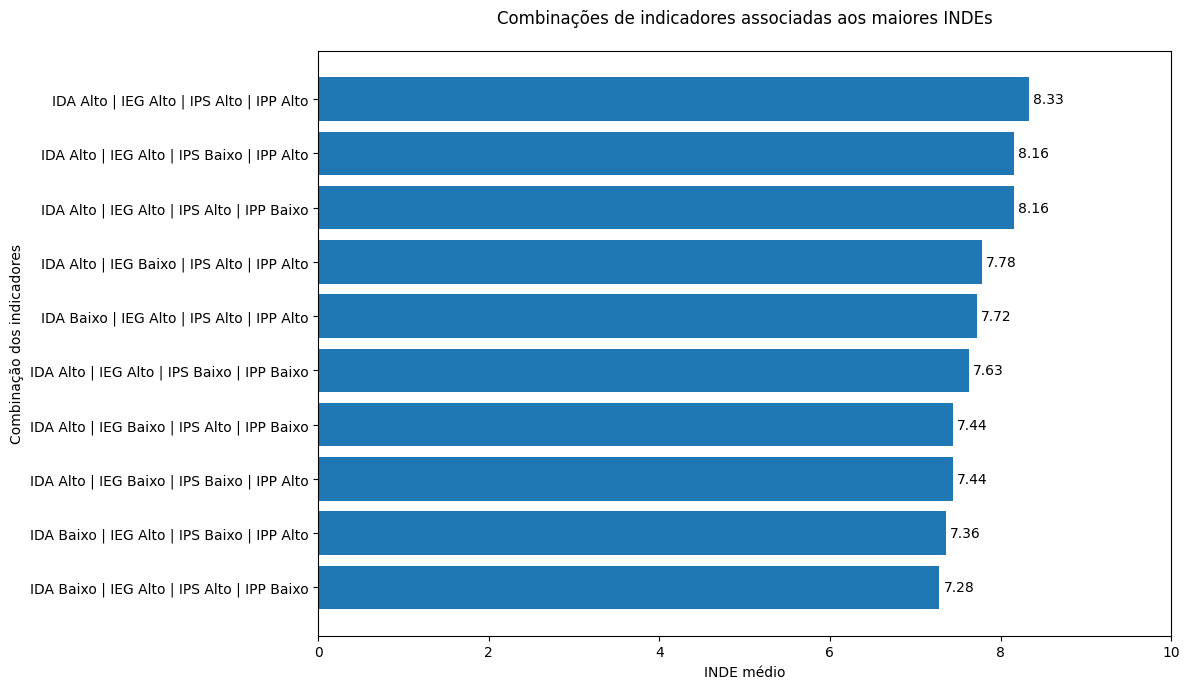

In [320]:
top_combinacoes = (
    combinacoes_relevantes
    .head(10)
    .sort_values(
        "inde_medio",
        ascending=True
    )
)

plt.figure(figsize=(12, 7))

barras = plt.barh(
    top_combinacoes["combinacao"],
    top_combinacoes["inde_medio"]
)

plt.title(
    "Combinações de indicadores associadas aos maiores INDEs",
    pad=20
)

plt.xlabel("INDE médio")
plt.ylabel("Combinação dos indicadores")
plt.xlim(0, 10)

for barra, valor in zip(
    barras,
    top_combinacoes["inde_medio"]
):
    plt.text(
        valor + 0.05,
        barra.get_y() + barra.get_height() / 2,
        f"{valor:.2f}",
        va="center"
    )

plt.tight_layout()
plt.show()

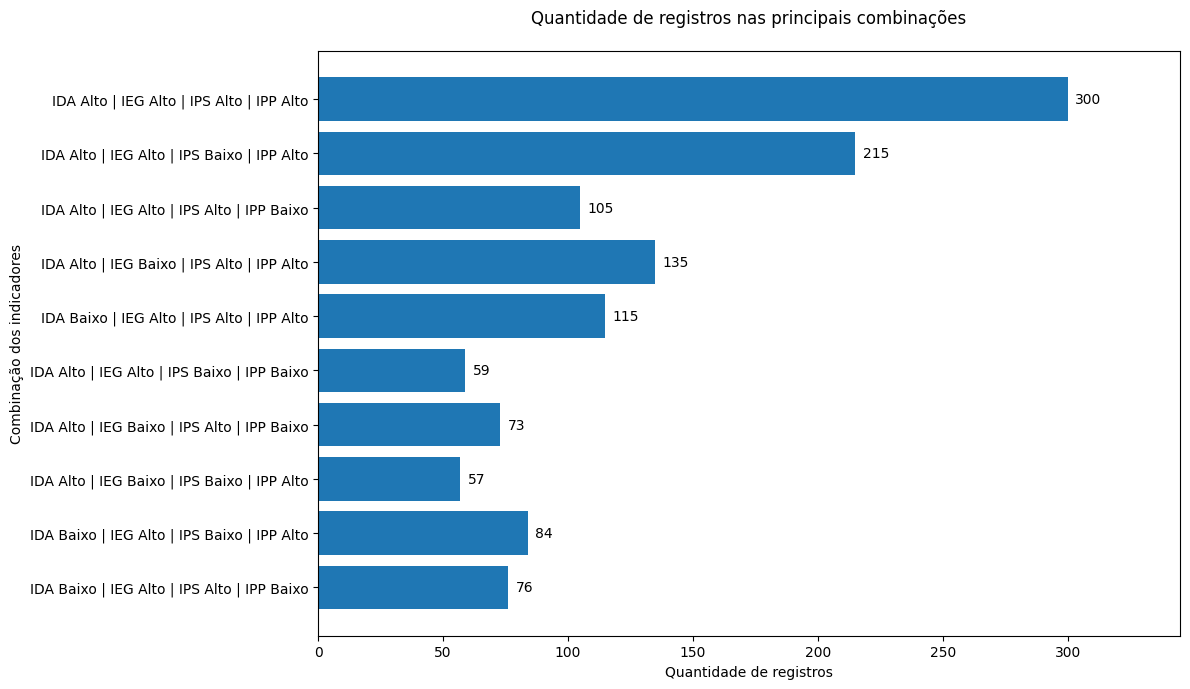

In [321]:
plt.figure(figsize=(12, 7))

barras = plt.barh(
    top_combinacoes["combinacao"],
    top_combinacoes["quantidade_registros"]
)

plt.title(
    "Quantidade de registros nas principais combinações",
    pad=20
)

plt.xlabel("Quantidade de registros")
plt.ylabel("Combinação dos indicadores")

for barra, quantidade in zip(
    barras,
    top_combinacoes["quantidade_registros"]
):
    plt.text(
        quantidade + 3,
        barra.get_y() + barra.get_height() / 2,
        str(int(quantidade)),
        va="center"
    )

plt.xlim(
    0,
    top_combinacoes["quantidade_registros"].max() * 1.15
)

plt.tight_layout()
plt.show()

### Interpretação das combinações específicas

A combinação com os quatro indicadores classificados como altos apresentou o maior INDE médio, igual a 8,33, com 300 registros analisados.

Entretanto, os resultados indicam que a combinação entre IDA alto e IEG alto possui papel especialmente relevante.

Quando IDA e IEG estavam altos, mas apenas um entre IPS e IPP estava baixo, o INDE médio permaneceu em 8,16. Portanto, resultados acadêmicos e de engajamento elevados simultaneamente estiveram associados a INDEs altos mesmo quando uma das outras dimensões apresentou resultado inferior à mediana anual.

Quando o IEG estava baixo, mesmo com IDA, IPS e IPP altos, o INDE médio caiu para 7,78. Quando o IDA estava baixo, mas os outros três indicadores estavam altos, a média foi de 7,72.

Os registros com os quatro indicadores baixos apresentaram o menor INDE médio, igual a 6,06.

Esses resultados sugerem que o melhor perfil multidimensional combina desempenho acadêmico e engajamento altos, complementados por bons resultados psicossociais e psicopedagógicos.

Entretanto, a associação é parcialmente esperada, pois o INDE é uma medida global formada a partir dos próprios indicadores educacionais. Portanto, as combinações descrevem os perfis associados aos maiores resultados, mas não representam relações causais independentes.

In [322]:
resumo_combinacoes_ano = (
    dados_multidimensionais
    .groupby(
        ["ano", "combinacao"]
    )
    .agg(
        quantidade_registros=("inde", "count"),
        inde_medio=("inde", "mean"),
        inde_mediano=("inde", "median")
    )
    .round(2)
    .reset_index()
)

resumo_combinacoes_ano

,ano,combinacao,quantidade_registros,inde_medio,inde_mediano
0,2023,IDA Alto | IEG Alto | IPS Alto | IPP Alto,107,8.21,8.23
1,2023,IDA Alto | IEG Alto | IPS Alto | IPP Baixo,79,8.25,8.29
2,2023,IDA Alto | IEG Alto | IPS Baixo | IPP Alto,87,7.92,7.94
3,2023,IDA Alto | IEG Alto | IPS Baixo | IPP Baixo,37,7.63,7.77
4,2023,IDA Alto | IEG Baixo | IPS Alto | IPP Alto,59,7.72,7.84
5,2023,IDA Alto | IEG Baixo | IPS Alto | IPP Baixo,44,7.50,7.50
6,2023,IDA Alto | IEG Baixo | IPS Baixo | IPP Alto,26,7.43,7.47
7,2023,IDA Alto | IEG Baixo | IPS Baixo | IPP Baixo,31,6.97,7.02
8,2023,IDA Baixo | IEG Alto | IPS Alto | IPP Alto,42,7.70,7.75
9,2023,IDA Baixo | IEG Alto | IPS Alto | IPP Baixo,51,7.27,7.38


In [323]:
matriz_quantidade_combinacao_ano = (
    resumo_combinacoes_ano
    .pivot(
        index="combinacao",
        columns="ano",
        values="quantidade_registros"
    )
    .fillna(0)
)

combinacoes_validas_ano = (
    matriz_quantidade_combinacao_ano[
        (
            matriz_quantidade_combinacao_ano
            >= 20
        )
        .all(axis=1)
    ]
    .index
)

comparacao_combinacoes_ano = (
    resumo_combinacoes_ano[
        resumo_combinacoes_ano[
            "combinacao"
        ].isin(combinacoes_validas_ano)
    ]
    .pivot(
        index="combinacao",
        columns="ano",
        values="inde_medio"
    )
)

In [324]:
ordem_combinacoes = (
    combinacoes_relevantes[
        combinacoes_relevantes[
            "combinacao"
        ].isin(combinacoes_validas_ano)
    ]
    .sort_values(
        "inde_medio",
        ascending=False
    )["combinacao"]
)

comparacao_combinacoes_ano = (
    comparacao_combinacoes_ano
    .reindex(ordem_combinacoes)
)

comparacao_combinacoes_ano

ano,2023,2024
combinacao,,
IDA Alto | IEG Alto | IPS Alto | IPP Alto,8.21,8.40
IDA Alto | IEG Alto | IPS Alto | IPP Baixo,8.25,7.89
IDA Alto | IEG Alto | IPS Baixo | IPP Alto,7.92,8.32
IDA Alto | IEG Baixo | IPS Alto | IPP Alto,7.72,7.82
IDA Baixo | IEG Alto | IPS Alto | IPP Alto,7.70,7.72
IDA Alto | IEG Alto | IPS Baixo | IPP Baixo,7.63,7.65
IDA Alto | IEG Baixo | IPS Baixo | IPP Alto,7.43,7.44
IDA Alto | IEG Baixo | IPS Alto | IPP Baixo,7.50,7.33
IDA Baixo | IEG Alto | IPS Baixo | IPP Alto,7.30,7.45


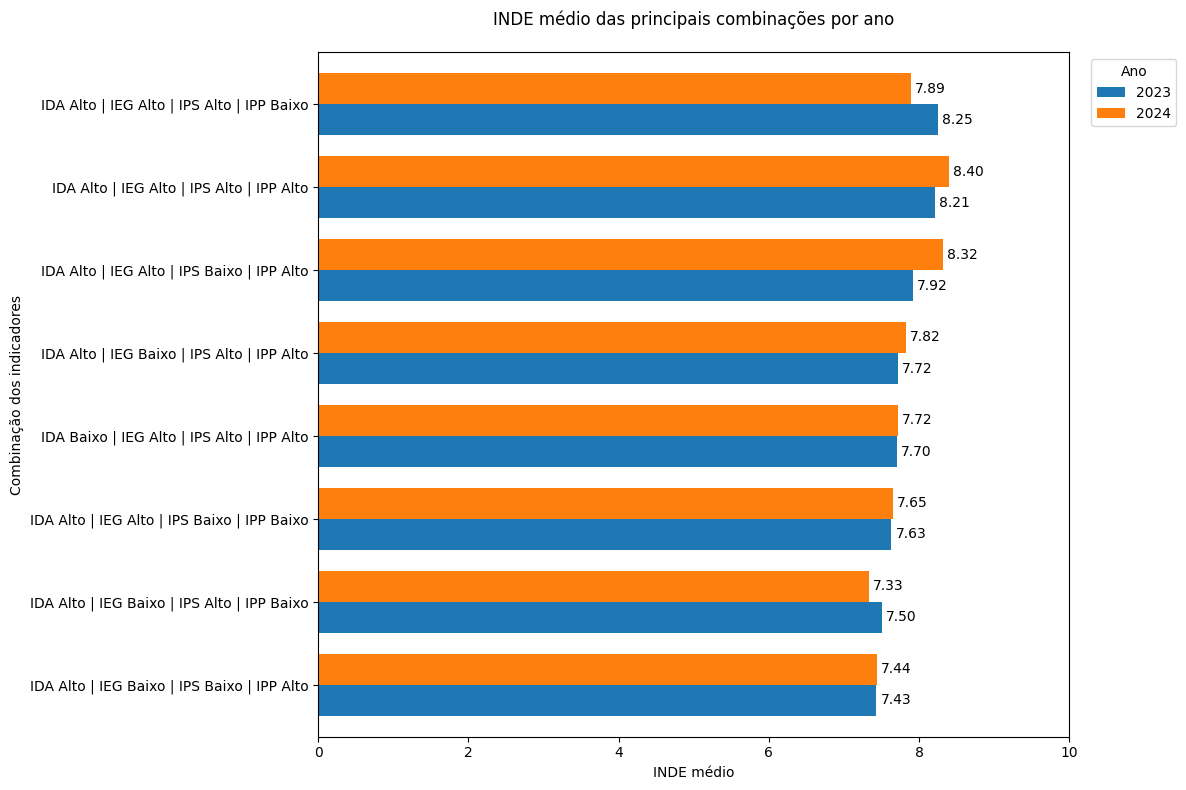

In [325]:
top_combinacoes_ano = (
    comparacao_combinacoes_ano
    .head(8)
    .sort_values(
        by=list(
            comparacao_combinacoes_ano.columns
        ),
        ascending=True
    )
)

ax = top_combinacoes_ano.plot(
    kind="barh",
    figsize=(12, 8),
    width=0.75
)

plt.title(
    "INDE médio das principais combinações por ano",
    pad=20
)

plt.xlabel("INDE médio")
plt.ylabel("Combinação dos indicadores")
plt.xlim(0, 10)

plt.legend(
    title="Ano",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3
    )

plt.tight_layout()
plt.show()

### Comparação das combinações entre 2023 e 2024

A comparação anual mostrou que as combinações associadas aos maiores valores de INDE foram relativamente consistentes entre 2023 e 2024.

Nos dois anos, as combinações de melhor desempenho possuíam simultaneamente IDA alto e IEG alto.

A combinação com os quatro indicadores altos apresentou INDE médio de 8,21 em 2023 e 8,40 em 2024. Em 2023, a combinação com IDA, IEG e IPS altos e IPP baixo apresentou resultado ligeiramente superior, igual a 8,25. Entretanto, a diferença de 0,04 ponto é pequena e não permite concluir que um IPP baixo seja favorável.

Quando IDA e IEG permaneceram altos, mas apenas um entre IPS e IPP estava baixo, o INDE continuou elevado nos dois anos. Isso reforça a importância conjunta do desempenho acadêmico e do engajamento.

As menores médias ocorreram nas combinações com IDA e IEG baixos. Quando os quatro indicadores estavam baixos, o INDE médio foi de 6,20 em 2023 e 5,95 em 2024.

Portanto, o padrão central foi estável: a combinação de desempenho acadêmico alto e engajamento alto apareceu de forma recorrente entre os perfis com maior desenvolvimento global.

### Resposta à Pergunta 8

Os resultados mostram que o INDE aumenta progressivamente conforme cresce a quantidade de indicadores classificados como altos.

Os registros sem nenhum indicador alto apresentaram INDE médio de 6,06. Com um indicador alto, a média aumentou para 6,59; com dois, para 7,24; e com três, para 7,98.

A combinação com os quatro indicadores altos apresentou INDE médio de 8,33, representando uma diferença de 2,27 pontos em relação ao grupo com os quatro indicadores baixos.

A análise das combinações específicas mostrou que o perfil com IDA, IEG, IPS e IPP altos apresentou o maior INDE médio geral, igual a 8,33.

Entretanto, mesmo quando apenas o IPS ou o IPP estava abaixo da mediana anual, a presença simultânea de IDA alto e IEG alto manteve o INDE médio em 8,16.

Quando o IEG estava baixo, apesar de IDA, IPS e IPP altos, o INDE médio caiu para 7,78. Quando o IDA estava baixo e os outros três indicadores estavam altos, a média foi de 7,72.

A comparação anual reforçou esse padrão. As combinações com IDA alto e IEG alto permaneceram entre as melhores em 2023 e 2024. A combinação com os quatro indicadores altos apresentou INDE médio de 8,21 em 2023 e 8,40 em 2024.

Em contraste, a combinação com todos os indicadores baixos apresentou INDE médio de 6,20 em 2023 e 5,95 em 2024.

Portanto, a combinação multidimensional mais favorável envolve resultados altos em todas as dimensões. Contudo, IDA e IEG altos simultaneamente formaram o padrão mais consistente entre os perfis com INDE elevado.

De forma gerencial, os resultados sugerem que desempenho acadêmico e engajamento devem ser acompanhados conjuntamente. Alunos com resultados baixos nessas duas dimensões podem constituir um grupo prioritário, especialmente quando também apresentam IPS e IPP baixos.

A classificação de alto e baixo foi definida em relação à mediana de cada indicador dentro do próprio ano. Como o IPP não possui dados em 2022, a análise utilizou somente 2023 e 2024.

Além disso, o INDE é uma medida global formada a partir de indicadores educacionais. Portanto, parte da associação observada é esperada por construção, e os resultados não representam relações causais independentes.

## 10. Pergunta 10 — Efetividade do programa por pedra

**Pergunta de negócio:** Os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases (Quartzo, Ágata, Ametista e Topázio), confirmando o impacto real do programa?

Reaproveita `df_pede` e a mesma lógica de acompanhamento pareado das Perguntas 1 e 2 (junção por `ra` entre anos), agora aplicada à pedra.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.float_format", "{:.2f}".format)

# df_pede já foi carregado na célula 2 deste notebook; a linha abaixo é só uma
# salvaguarda caso este bloco seja executado isoladamente.
if "df_pede" not in globals():
    df_pede = pd.read_csv("dados_pede.csv")

ORDEM_PEDRA = ["Quartzo", "Ágata", "Ametista", "Topázio"]
RANK_PEDRA = {p: i for i, p in enumerate(ORDEM_PEDRA)}

print(f"Base: {df_pede.shape[0]} linhas | {df_pede['ra'].nunique()} alunos únicos | anos {sorted(df_pede['ano'].unique())}")

Base: 3030 linhas | 1661 alunos únicos | anos [np.int64(2022), np.int64(2023), np.int64(2024)]


### 10.1 Distribuição de pedra por ano (transversal)
Visão geral da população em cada ano — ainda não são os mesmos alunos.

Contagem absoluta (inclui 'sem classificação' se houver):
pedra_padrao  Quartzo  Ágata  Ametista  Topázio  NaN
ano                                                 
2022              132    250       348      130    0
2023               72    246       381      232   83
2024              112    225       391      326  102

Percentual entre alunos classificados:
pedra_padrao  Quartzo  Ágata  Ametista  Topázio
ano                                            
2022            15.30  29.10     40.50    15.10
2023             7.70  26.40     40.90    24.90
2024            10.60  21.30     37.10    30.90


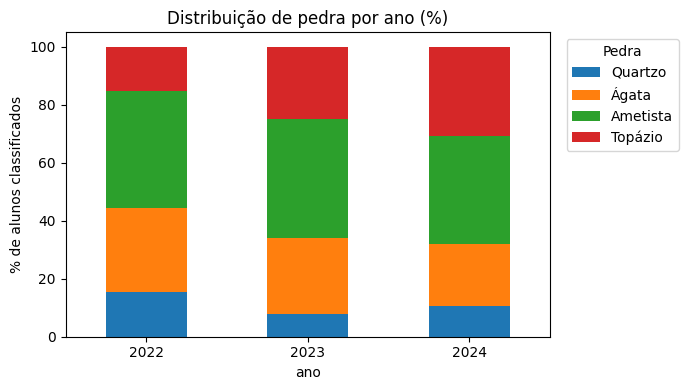

In [2]:
dist_pedra_ano = pd.crosstab(df_pede["ano"], df_pede["pedra_padrao"], dropna=False)
dist_pedra_ano = dist_pedra_ano.reindex(columns=ORDEM_PEDRA + [c for c in dist_pedra_ano.columns if c not in ORDEM_PEDRA])
dist_pedra_pct = dist_pedra_ano[ORDEM_PEDRA].div(dist_pedra_ano[ORDEM_PEDRA].sum(axis=1), axis=0) * 100

print("Contagem absoluta (inclui 'sem classificação' se houver):")
print(dist_pedra_ano)
print("\nPercentual entre alunos classificados:")
print(dist_pedra_pct.round(1))

dist_pedra_pct.plot(kind="bar", stacked=True, figsize=(7, 4))
plt.title("Distribuição de pedra por ano (%)")
plt.ylabel("% de alunos classificados")
plt.xticks(rotation=0)
plt.legend(title="Pedra", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 10.2 Evolução pareada (mesmo aluno em dois anos)
Mesma lógica de `analisar_periodo` usada nas Perguntas 1 e 2, aplicada à pedra.

In [3]:
def analisar_periodo_pedra(df, ano_inicial, ano_final):
    ini = df[df["ano"] == ano_inicial][["ra", "pedra_padrao", "ano_ingresso"]].rename(columns={"pedra_padrao": "pedra_inicial"})
    fin = df[df["ano"] == ano_final][["ra", "pedra_padrao"]].rename(columns={"pedra_padrao": "pedra_final"})
    comp = ini.merge(fin, on="ra", how="inner").dropna(subset=["pedra_inicial", "pedra_final"]).copy()
    comp["variacao"] = comp["pedra_final"].map(RANK_PEDRA) - comp["pedra_inicial"].map(RANK_PEDRA)
    comp["evolucao"] = np.select([comp["variacao"] > 0, comp["variacao"] < 0], ["Subiu", "Desceu"], default="Manteve")
    comp["ingressante_no_periodo"] = comp["ano_ingresso"] == ano_inicial
    comp["periodo"] = f"{ano_inicial}\u2192{ano_final}"
    return comp

evol_2223 = analisar_periodo_pedra(df_pede, 2022, 2023)
evol_2324 = analisar_periodo_pedra(df_pede, 2023, 2024)

resumo_evolucao_pedra = pd.concat([evol_2223, evol_2324]).groupby(["periodo", "evolucao"]).size().unstack()
resumo_evolucao_pedra_pct = resumo_evolucao_pedra.div(resumo_evolucao_pedra.sum(axis=1), axis=0) * 100

print(f"Alunos comparáveis: {len(evol_2223)} (2022\u21922023) | {len(evol_2324)} (2023\u21922024)\n")
print(resumo_evolucao_pedra_pct[["Subiu", "Manteve", "Desceu"]].round(1))

Alunos comparáveis: 570 (2022→2023) | 678 (2023→2024)

evolucao   Subiu  Manteve  Desceu
periodo                          
2022→2023  24.40    51.20   24.40
2023→2024  24.20    50.00   25.80


### 10.3 Matriz de transição — 2023 → 2024
De qual pedra para qual pedra (% por linha).

In [4]:
matriz_transicao = pd.crosstab(evol_2324["pedra_inicial"], evol_2324["pedra_final"], normalize="index") * 100
matriz_transicao = matriz_transicao.reindex(index=ORDEM_PEDRA, columns=ORDEM_PEDRA)
print(matriz_transicao.round(1))

pedra_final    Quartzo  Ágata  Ametista  Topázio
pedra_inicial                                   
Quartzo          47.60  40.50     11.90     0.00
Ágata            20.40  44.70     27.00     7.90
Ametista          7.30  19.70     43.30    29.70
Topázio           0.50   4.30     29.30    65.80


### 10.4 Robustez: excluindo ingressantes
Testa se o resultado da seção 10.2 muda ao remover quem ingressou no início do período (ruído de entrada citado no guia).

In [5]:
for nome, comp in [("2022\u21922023", evol_2223), ("2023\u21922024", evol_2324)]:
    com_ingressantes = comp["evolucao"].value_counts(normalize=True).mul(100)
    sem_ingressantes = comp.loc[~comp["ingressante_no_periodo"], "evolucao"].value_counts(normalize=True).mul(100)
    tabela = pd.DataFrame({"com_ingressantes": com_ingressantes, "sem_ingressantes": sem_ingressantes}).reindex(["Subiu", "Manteve", "Desceu"])
    print(f"--- {nome} ---")
    print(tabela.round(1), "\n")

--- 2022→2023 ---
          com_ingressantes  sem_ingressantes
evolucao                                    
Subiu                24.40             23.90
Manteve              51.20             49.70
Desceu               24.40             26.50 

--- 2023→2024 ---
          com_ingressantes  sem_ingressantes
evolucao                                    
Subiu                24.20             27.10
Manteve              50.00             49.40
Desceu               25.80             23.40 



### 10.5 Indicadores médios por pedra e ano (retrato transversal)

Cada linha é um **grupo diferente de alunos** (quem estava em cada pedra naquele ano), não o mesmo aluno ao longo do tempo — para evolução individual, ver 10.6.

In [6]:
indicadores = ["inde", "ian", "ida", "ieg", "iaa", "ips", "ipp", "ipv"]
medias_pedra_ano = df_pede.groupby(["ano", "pedra_padrao"])[indicadores].mean().reindex(ORDEM_PEDRA, level="pedra_padrao")

print("Atenção: comparação transversal (grupos diferentes por ano), não é acompanhamento dos mesmos alunos.\n")
print(medias_pedra_ano.round(2))

# Alerta de qualidade: IAA=0 pode ser "não respondeu" e não nota real
pct_iaa_zero = df_pede.assign(iaa_zero=df_pede["iaa"] == 0).groupby("ano")["iaa_zero"].mean() * 100
print("\n% de registros com IAA == 0 por ano (checar antes de interpretar IAA por pedra/ano):")
print(pct_iaa_zero.round(1))

Atenção: comparação transversal (grupos diferentes por ano), não é acompanhamento dos mesmos alunos.

                   inde  ian  ida  ieg  iaa  ips  ipp  ipv
ano  pedra_padrao                                         
2022 Quartzo       5.24 5.25 3.14 5.26 6.42 6.55  NaN 5.80
     Ágata         6.61 5.68 5.25 7.54 8.15 6.63  NaN 6.89
     Ametista      7.53 6.67 7.01 8.62 8.73 7.07  NaN 7.63
     Topázio       8.37 8.38 8.25 9.28 9.17 7.35  NaN 8.43
2023 Quartzo       5.55 5.31 4.59 7.12 2.25 4.13 6.68 6.86
     Ágata         6.57 6.07 5.59 8.10 5.38 4.69 7.25 7.47
     Ametista      7.51 7.12 6.87 8.95 7.52 4.96 7.63 8.14
     Topázio       8.44 8.49 8.13 9.43 8.96 6.20 8.06 8.81
2024 Quartzo       5.40 6.36 3.11 5.04 7.22 5.96 6.47 5.84
     Ágata         6.60 6.53 4.92 7.07 8.24 6.70 7.11 6.71
     Ametista      7.53 7.19 6.57 8.46 8.71 6.94 7.58 7.44
     Topázio       8.47 8.80 8.19 9.40 9.00 7.09 8.19 8.22

% de registros com IAA == 0 por ano (checar antes de interpretar IAA po

### 10.6 Δ dos indicadores por trajetória de pedra

Para os **mesmos alunos** de 10.2/10.3: quem subiu, manteve ou desceu de pedra teve, em média, que variação em cada indicador? Esta é a análise mais diretamente ligada à pergunta 10 — mas note que IAN..IPV compõem o INDE que define a pedra, então parte da relação é esperada por construção, não uma confirmação causal independente.

In [7]:
def calcular_delta_indicadores(df, ano_inicial, ano_final, evolucao_pedra):
    componentes = ["ian", "ida", "ieg", "iaa", "ips", "ipp", "ipv"]
    ini = df[df["ano"] == ano_inicial][["ra"] + componentes].set_index("ra")
    fin = df[df["ano"] == ano_final][["ra"] + componentes].set_index("ra")
    delta = (fin - ini).add_prefix("delta_")
    return evolucao_pedra[["ra", "evolucao"]].merge(delta, on="ra", how="inner")

delta_2223 = calcular_delta_indicadores(df_pede, 2022, 2023, evol_2223)
delta_2324 = calcular_delta_indicadores(df_pede, 2023, 2024, evol_2324)
delta_cols = [c for c in delta_2223.columns if c.startswith("delta_")]

for nome, delta in [("2022\u21922023", delta_2223), ("2023\u21922024", delta_2324)]:
    resumo = delta.groupby("evolucao")[delta_cols].mean().reindex(["Subiu", "Manteve", "Desceu"])
    resumo.insert(0, "n", delta["evolucao"].value_counts().reindex(["Subiu", "Manteve", "Desceu"]))
    print(f"--- {nome}: Δ médio de cada indicador por trajetória de pedra ---")
    print(resumo.round(2), "\n")

print("delta_ipp ausente em 2022\u21922023: IPP não existe na base de 2022 (ver guia metodológico).")
print("delta_iaa em 2022\u21922023 é inflado pela anomalia de IAA=0 em 2023 (ver alerta em 10.5).")

--- 2022→2023: Δ médio de cada indicador por trajetória de pedra ---
            n  delta_ian  delta_ida  delta_ieg  delta_iaa  delta_ips  \
evolucao                                                               
Subiu     139       0.88       1.22       0.87       0.47      -1.11   
Manteve   292       0.36      -0.00       0.17      -1.45      -1.95   
Desceu    139      -0.52      -0.74      -0.29      -4.80      -2.56   

          delta_ipp  delta_ipv  
evolucao                        
Subiu           NaN       1.07  
Manteve         NaN       0.55  
Desceu          NaN       0.06   

--- 2023→2024: Δ médio de cada indicador por trajetória de pedra ---
            n  delta_ian  delta_ida  delta_ieg  delta_iaa  delta_ips  \
evolucao                                                               
Subiu     164       1.33       0.64       0.04       3.70       2.31   
Manteve   339       0.42      -0.22      -0.65       1.45       1.57   
Desceu    175       0.16      -2.04      -1.91

### 10.7 Tempo de programa x pedra (exploratório)

Teste simples de dose-resposta, sem controlar coorte, idade ou fase — tratar como exploratório, não como evidência de efetividade (ou da falta dela).

In [8]:
df_pede["tempo_programa"] = df_pede["ano"] - df_pede["ano_ingresso"]
df_tempo_valido = df_pede[df_pede["tempo_programa"].between(0, 15) & df_pede["pedra_padrao"].notna()].copy()
df_tempo_valido["rank_pedra"] = df_tempo_valido["pedra_padrao"].map(RANK_PEDRA)

faixas_tempo = pd.cut(df_tempo_valido["tempo_programa"], bins=[-1, 0, 2, 4, 99], labels=["0 (ingresso)", "1-2 anos", "3-4 anos", "5+ anos"])
resumo_tempo = df_tempo_valido.groupby(faixas_tempo, observed=True).agg(n=("ra", "size"), inde_medio=("inde", "mean"), pedra_media=("rank_pedra", "mean"))

r = df_tempo_valido["tempo_programa"].corr(df_tempo_valido["rank_pedra"])
print(f"Correlação tempo de programa x rank de pedra: r={r:.3f} (r²={r**2:.3f})")
print("Efeito muito fraco e sem controle de confundidores (coorte, idade, fase) — não conclusivo.\n")
print(resumo_tempo.round(2))

Correlação tempo de programa x rank de pedra: r=-0.098 (r²=0.010)
Efeito muito fraco e sem controle de confundidores (coorte, idade, fase) — não conclusivo.

                   n  inde_medio  pedra_media
tempo_programa                               
0 (ingresso)    1108        7.33         1.82
1-2 anos         983        7.32         1.82
3-4 anos         597        7.17         1.66
5+ anos          157        6.91         1.45


### Nota metodológica — faixas do guia x `pedra_padrao`

Checagem de qualidade da base (a pedra dada bate com as faixas de INDE do guia?), **não é evidência sobre efetividade do programa**.

In [9]:
FAIXAS_GUIA = [("Quartzo", 2.405, 5.506), ("Ágata", 5.506, 6.868), ("Ametista", 6.868, 8.230), ("Topázio", 8.230, 9.294)]

def pedra_pelo_guia(inde):
    if pd.isna(inde):
        return np.nan
    for nome, lo, hi in FAIXAS_GUIA:
        if lo <= inde <= hi:
            return nome
    return "Fora das faixas"

df_pede["pedra_guia"] = df_pede["inde"].apply(pedra_pelo_guia)
comparavel = df_pede.dropna(subset=["pedra_padrao", "pedra_guia"])
taxa_acerto = (comparavel["pedra_padrao"] == comparavel["pedra_guia"]).mean() * 100

print(f"Correspondência pedra da planilha x pedra recalculada pelo guia: {taxa_acerto:.1f}% "
      f"(n={len(comparavel)})")
print("\nAtenção: NÃO recalcule pedra a partir do INDE usando essas faixas — use sempre 'pedra_padrao'.")

Correspondência pedra da planilha x pedra recalculada pelo guia: 81.5% (n=2845)

Atenção: NÃO recalcule pedra a partir do INDE usando essas faixas — use sempre 'pedra_padrao'.


### Resposta à Pergunta 10

**O que os dados mostram (associação):**
- A fatia de alunos em Topázio cresce e em Quartzo cai ano a ano (10.1); defasagem severa também cai (Pergunta 1).
- Entre os mesmos alunos, as proporções de quem sobe e desce de pedra são semelhantes, com leve predominância de queda em 2023→2024 (10.2, 10.3) — resultado que não muda ao excluir ingressantes (10.4).
- Quem sobe de pedra tem, em média, variação mais positiva em praticamente todos os indicadores do que quem mantém ou desce (10.6) — coerente, mas parcialmente esperado, já que esses indicadores compõem o próprio INDE que define a pedra.

**O que os dados não permitem confirmar (causalidade):**
- Não há grupo de controle nem desenho causal: a associação indicador↔pedra (10.6) é em parte tautológica, não prova de efeito do programa.
- A relação entre tempo de programa e pedra é fraca e não controla coorte, idade ou fase (10.7) — não deve ser usada a favor nem contra a efetividade.

**Leitura:** há sinais positivos na distribuição das pedras e coerência interna entre indicadores e pedra, mas a evolução individual não é consistentemente ascendente — os dados não confirmam impacto causal do programa.